# Italian Financial Challenge: Revenue Change Forecasting

**Student Name:** Deniz Mehmet Taylan, Gustavo Depieri Fioravanti, Yarkin Yavuz, Koray Aydin  
**Challenge:** Revenue Change Forecasting  
**Date:** 27/04/2026


## 1. Problem Overview

We forecast `revenue_change_next`, the next-year percentage change in `production_value`, using panel financial statements from earlier fiscal years. This target is hard for two reasons: the distribution is heavy-tailed, and percentage-error metrics become unstable when the true revenue change is close to zero.

**How we approach it:**
- fit the model on `log_production_value_next`, then convert predictions back to `revenue_change_next`
- keep every split strictly time-based: `2018-2019 -> 2020` for feature selection and `2018-2020 -> 2021` for the locked holdout
- judge models by directional accuracy, rank quality, and robust percentage error rather than raw MAPE alone
- fit preprocessing, grouped priors, winsorization bounds, and feature filters on training years only


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading And EDA

The training data covers fiscal years `2018-2021`, while the competition rows extend into `2022-2023`. Because firms repeat across years, this is a panel problem rather than an IID regression task.

The EDA in this notebook has a narrower purpose than a general descriptive report. It is designed to answer the exact questions that matter for modeling revenue change:

1. How unstable is the target distribution, especially near zero and in the extreme tails?
2. Which financial ratios and structural firm characteristics appear to separate collapses, stable firms, and breakouts?
3. Which threshold effects are strong enough to motivate event-style and fragility features later in the pipeline?

The goal is not to over-interpret every plot. The goal is to build a defensible modeling story before feature engineering begins.

In [2]:
# Load training data
train_df = pd.read_csv('../data/processed/train_data.csv')

print(f"Dataset shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Dataset shape: (11828, 30)

Columns: ['company_id', 'fiscal_year', 'province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin', 'bankruptcy_next_year', 'financial_health_class', 'revenue_change']

First few rows:


,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,financial_health_class,revenue_change
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,0,B,NaN
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,0,B,-76.77
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,0,D,1521.81
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,0,D,-92.77
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,0,B,NaN


In [3]:
# Basic information
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 

In [4]:
# Summary statistics
train_df.describe()

,fiscal_year,ateco_sector,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,revenue_change
count,11828.000000,11828.000000,11828.000000,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,11783.000000,11828.000000,11783.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,8829.000000
mean,2019.495350,45.827697,35.179405,1.029206e+09,1.438435e+09,2.467641e+09,9.163141e+08,1.551327e+09,8.534656e+08,6.978617e+08,3.969063e+09,3.680129e+09,2.889337e+08,6.418314e+06,5.464980e+07,2.342839e+08,0.254267,0.123253,2.135329,1.869953,1.121972,0.633231,0.058008,0.007102,453.434570
std,1.116482,16.677183,19.908095,6.120958e+09,6.873106e+09,1.248305e+10,5.023564e+09,7.724478e+09,4.360360e+09,3.493369e+09,1.896096e+10,1.757911e+10,1.574126e+09,3.930832e+07,2.850800e+08,1.348222e+09,0.577374,0.091036,2.159040,0.614015,0.368409,0.114868,0.039245,0.083976,4601.920625
min,2018.000000,10.000000,0.000000,1.267167e+06,1.278800e+06,2.545968e+06,-3.330561e+09,1.839791e+06,8.985461e+05,9.412449e+05,2.329670e+06,1.580518e+06,-2.688184e+09,6.241000e+01,5.926949e+04,-4.062689e+09,-39.177100,-0.475300,0.818200,0.551000,0.330600,0.450000,-0.149700,0.000000,-99.940000
25%,2018.000000,41.000000,18.000000,7.319803e+07,1.244471e+08,2.087793e+08,7.070428e+07,1.294646e+08,6.925617e+07,5.666362e+07,2.984883e+08,2.731290e+08,1.698626e+07,3.569547e+05,4.355200e+06,1.049173e+07,0.110350,0.061900,1.165650,1.430800,0.858500,0.538500,0.030500,0.000000,-68.590000
50%,2019.000000,46.000000,35.000000,1.905995e+08,3.125597e+08,5.212379e+08,1.815958e+08,3.264152e+08,1.744802e+08,1.462585e+08,8.040019e+08,7.459428e+08,5.128590e+07,1.068330e+06,1.110262e+07,3.798727e+07,0.221600,0.105000,1.680300,1.811750,1.087050,0.627500,0.060300,0.000000,3.040000
75%,2020.000000,56.000000,52.000000,5.398741e+08,8.387197e+08,1.394478e+09,5.022747e+08,8.795087e+08,4.777298e+08,3.960070e+08,2.241163e+09,2.075266e+09,1.538062e+08,3.178533e+06,3.005698e+07,1.226862e+08,0.390750,0.170900,2.484850,2.238925,1.343325,0.713800,0.090000,0.000000,238.850000
max,2021.000000,82.000000,71.000000,2.548712e+11,2.512549e+11,5.061262e+11,1.956145e+11,3.105116e+11,1.699685e+11,1.405431e+11,6.044366e+11,5.736470e+11,5.621927e+10,1.640114e+09,9.311030e+09,5.011818e+10,1.771600,0.490600,101.153800,4.539300,2.723600,1.192300,0.120000,1.000000,302126.480000


In [5]:
# Check for missing values
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

Missing Values:
                Missing Count  Percentage
revenue_change           2999   25.355090
province                  919    7.769699
roe                        45    0.380453
leverage                   45    0.380453


In [6]:
# Target variable analysis
# For Challenge 3: Revenue Forecasting
print("\nRevenue Change Statistics:")
print(train_df['revenue_change'].describe())
print(f"\nMissing revenue_change: {train_df['revenue_change'].isnull().sum()}")


Revenue Change Statistics:
count      8829.000000
mean        453.434570
std        4601.920625
min         -99.940000
25%         -68.590000
50%           3.040000
75%         238.850000
max      302126.480000
Name: revenue_change, dtype: float64

Missing revenue_change: 2999


### 2.1 EDA Roadmap

The exploratory section is organized to mirror the eventual modeling logic.

- First, we study the shape of the target and how much of the difficulty comes from denominator instability.
- Next, we inspect ratio structure, context variables, and grouped patterns that later motivate relative features.
- Finally, we examine threshold events and revenue-tier behavior so the engineered regime features have a clear empirical basis.

This makes the EDA read as part of the forecasting argument rather than as a detached set of plots.

### 2.2 Target Shape And Year Effects

These cells inspect the distribution of `revenue_change_next`, how it changes by fiscal year, and why the raw target is difficult. The key issue is that percentage growth becomes unstable when current-year `production_value` is small, so very large reported moves may reflect denominator mechanics as much as underlying economics.

This section is therefore the foundation for the metric choices made later. If the tails are structurally noisy, the notebook should emphasize robust percentage error, ranking quality, and direction rather than raw `MAPE` alone.

In [7]:
eda_df = train_df.copy()
eda_df = eda_df.sort_values(['company_id', 'fiscal_year'])

# Intermediate next-year revenue level (for target construction)
eda_df['production_value_next'] = (
    eda_df.groupby('company_id')['production_value'].shift(-1)
)

# Challenge 3 target for EDA: next-year revenue change (%)
eda_df['revenue_change_next'] = 100 * (
    eda_df['production_value_next'] - eda_df['production_value']
) / eda_df['production_value'].replace(0, np.nan)

# Keep only rows with a valid next-year target (train-only EDA; includes 2020)
eda_df = eda_df.dropna(subset=['revenue_change_next'])

eda_df['cost_intensity'] = eda_df['production_costs'] / eda_df['production_value']
eda_df['asset_turnover'] = eda_df['production_value'] / eda_df['total_assets']
eda_df['debt_burden'] = eda_df['financial_expenses'] / eda_df['production_value']
eda_df['equity_ratio'] = eda_df['shareholders_equity'] / eda_df['total_assets']


In [8]:
eda_df = eda_df.dropna(subset=['revenue_change_next'])

In [9]:
print("EDA dataset shape:", eda_df.shape)

print("\nFeature years:")
print(eda_df['fiscal_year'].value_counts())

print("\nTarget summary:")
print(eda_df['revenue_change_next'].describe())

EDA dataset shape: (8829, 36)

Feature years:
fiscal_year
2019    2956
2018    2941
2020    2932
Name: count, dtype: int64

Target summary:
count      8829.000000
mean        453.434572
std        4601.920682
min         -99.943317
25%         -68.594596
50%           3.038018
75%         238.849662
max      302126.484381
Name: revenue_change_next, dtype: float64


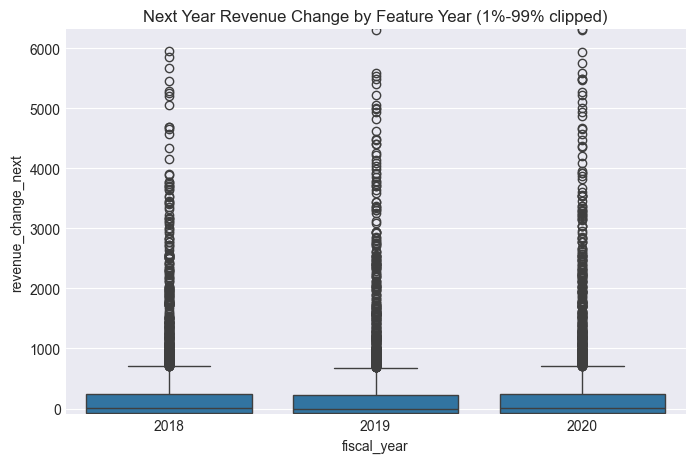

In [10]:
lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

plt.figure(figsize=(8,5))
sns.boxplot(x='fiscal_year', y='revenue_change_next', data=eda_df)

plt.ylim(lower, upper)

plt.title("Next Year Revenue Change by Feature Year (1%-99% clipped)")
plt.show()

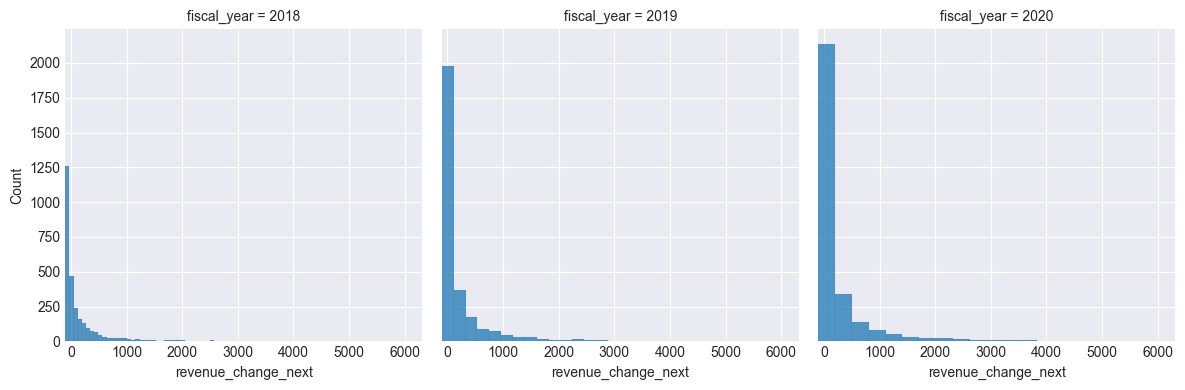

In [11]:
lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)
g.map(sns.histplot, "revenue_change_next", bins=1000)

for ax in g.axes.flat:
    ax.set_xlim(lower, upper)

plt.show()

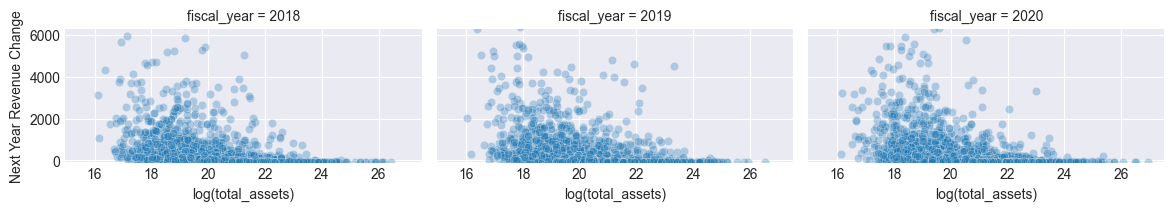

In [12]:
g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)

g.map_dataframe(
    sns.scatterplot,
    x=np.log1p(eda_df['total_assets']),
    y='revenue_change_next',
    alpha=0.3
)

lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

for ax in g.axes.flat:
    ax.set_ylim(lower, upper)

g.set_axis_labels("log(total_assets)", "Next Year Revenue Change")

plt.show()

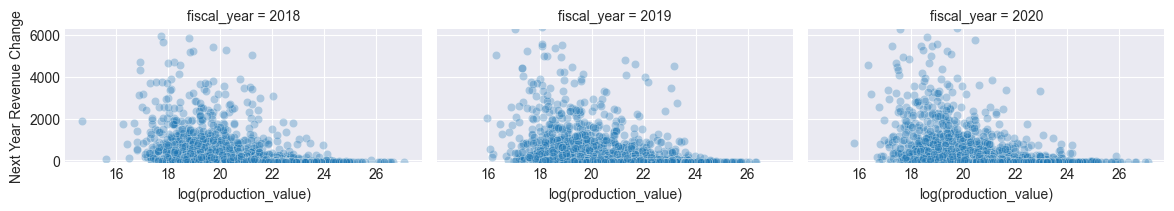

In [13]:
g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)

g.map_dataframe(
    sns.scatterplot,
    x=np.log1p(eda_df['production_value']),
    y='revenue_change_next',
    alpha=0.3
)

lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

for ax in g.axes.flat:
    ax.set_ylim(lower, upper)

g.set_axis_labels("log(production_value)", "Next Year Revenue Change")

plt.show()

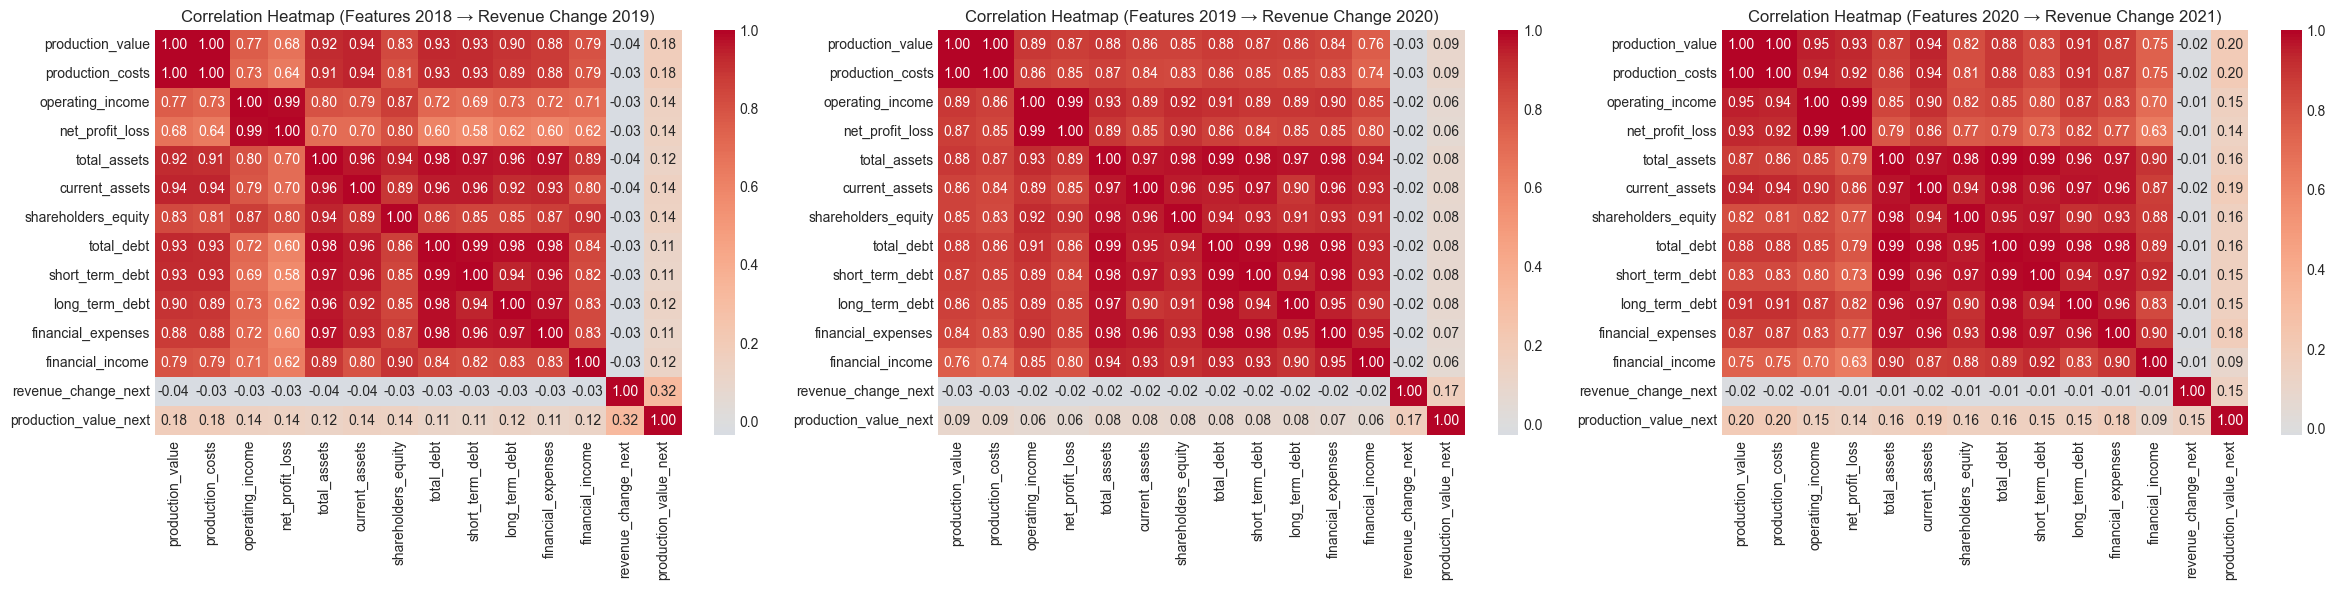

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

important_features = [
    'production_value',
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'current_assets',
    'shareholders_equity',
    'total_debt',
    'short_term_debt',
    'long_term_debt',
    'financial_expenses',
    'financial_income',
    'revenue_change_next',
    'production_value_next'
]

years = sorted(eda_df['fiscal_year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(8 * len(years), 6))
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    df_year = eda_df[eda_df['fiscal_year'] == year]
    corr = df_year[important_features].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"Correlation Heatmap (Features {year} \u2192 Revenue Change {year+1})")

plt.tight_layout()
plt.show()


### 2.3 Ratio And Context EDA

This block checks the financial ratios, sector patterns, and regional structure that later motivate the engineered relative features. It is still descriptive only, with no train-validation leakage decisions made here.

The main question is whether firms with similar raw scale can still look very different once margins, leverage, debt mix, or peer-relative position are considered. That is especially important in revenue forecasting, where raw size alone rarely explains who will collapse, stabilize, or rebound next year.

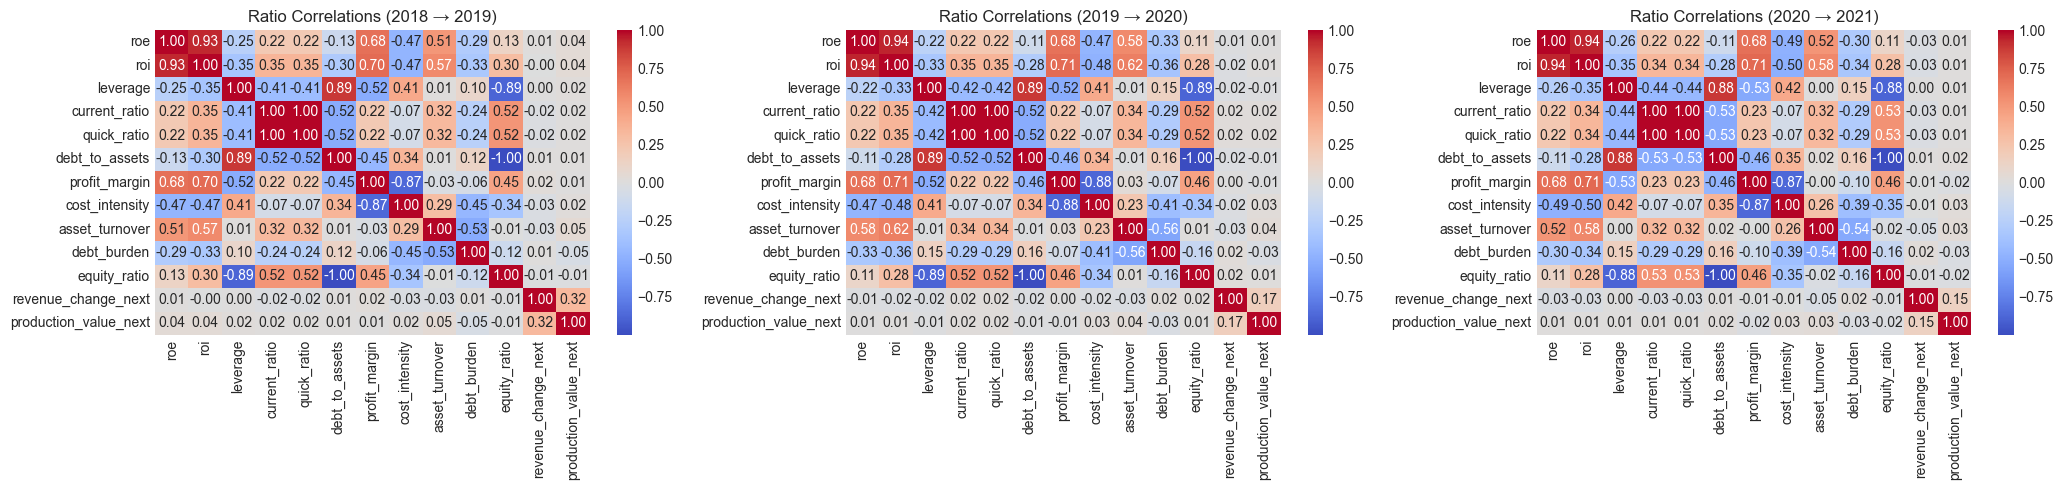

In [15]:
ratio_features = [
    'roe',
    'roi',
    'leverage',
    'current_ratio',
    'quick_ratio',
    'debt_to_assets',
    'profit_margin',
    'cost_intensity',
    'asset_turnover',
    'debt_burden',
    'equity_ratio',
    'revenue_change_next',
    'production_value_next'
]

years = sorted(eda_df['fiscal_year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(7 * len(years), 5))
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    df_year = eda_df[eda_df['fiscal_year'] == year]
    corr = df_year[ratio_features].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"Ratio Correlations ({year} \u2192 {year+1})")

plt.tight_layout()
plt.show()


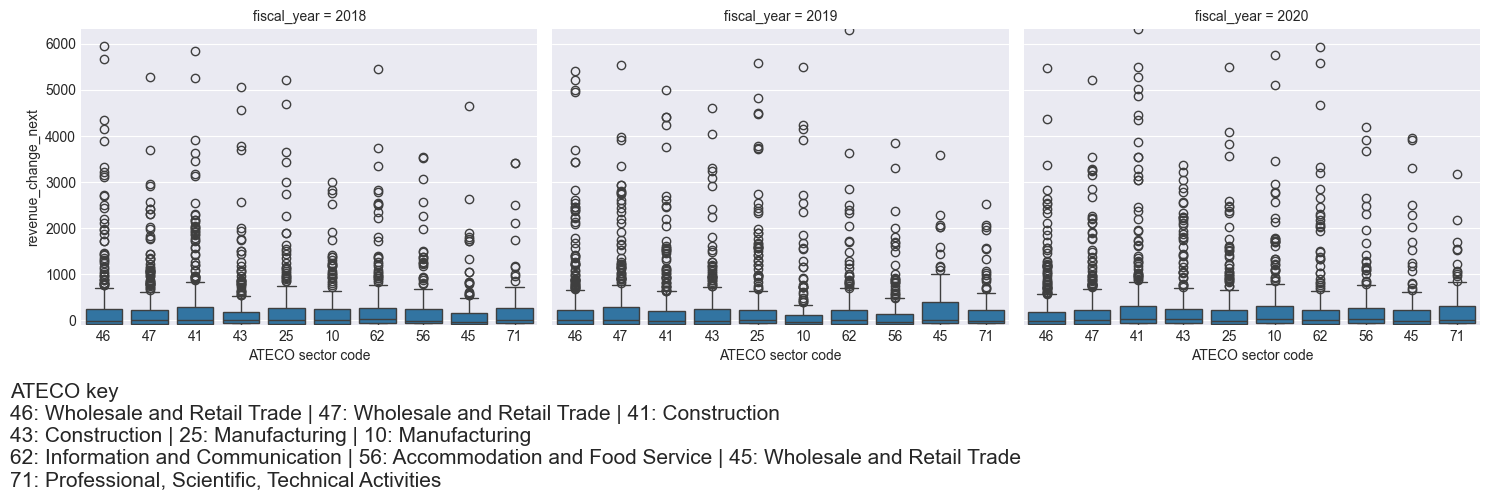

In [16]:
# Top sectors by frequency (keep sector codes separate)
top_sectors = eda_df['ateco_sector'].value_counts().nlargest(10).index

# ATECO main-category labels from docs/data_dictionary.md
ateco_ranges = [
    (1, 3, 'Agriculture, Forestry, Fishing'),
    (5, 9, 'Mining and Quarrying'),
    (10, 33, 'Manufacturing'),
    (35, 35, 'Electricity, Gas, Steam'),
    (36, 39, 'Water Supply, Sewerage, Waste'),
    (41, 43, 'Construction'),
    (45, 47, 'Wholesale and Retail Trade'),
    (49, 53, 'Transportation and Storage'),
    (55, 56, 'Accommodation and Food Service'),
    (58, 63, 'Information and Communication'),
    (64, 66, 'Financial and Insurance Activities'),
    (68, 68, 'Real Estate Activities'),
    (69, 75, 'Professional, Scientific, Technical Activities'),
    (77, 82, 'Administrative and Support Services'),
    (84, 84, 'Public Administration'),
    (85, 85, 'Education'),
    (86, 88, 'Human Health and Social Work'),
    (90, 93, 'Arts, Entertainment, Recreation'),
    (94, 96, 'Other Service Activities'),
]

def ateco_desc_from_code(code):
    numeric_code = pd.to_numeric(pd.Series([code]), errors='coerce').iloc[0]
    if pd.isna(numeric_code):
        return 'Unmapped'

    code_int = int(numeric_code)
    for lo, hi, label in ateco_ranges:
        if lo <= code_int <= hi:
            return label
    return 'Unmapped'

def ateco_code_fmt(code):
    numeric_code = pd.to_numeric(pd.Series([code]), errors='coerce').iloc[0]
    if pd.isna(numeric_code):
        return str(code)
    return f"{int(numeric_code):02d}"

def chunk_list(items, size):
    return [items[i:i + size] for i in range(0, len(items), size)]

plot_df = eda_df[eda_df['ateco_sector'].isin(top_sectors)].copy()
plot_df['ateco_sector_code'] = plot_df['ateco_sector'].apply(ateco_code_fmt)

# Keep same frequency ordering
sector_order_codes = [ateco_code_fmt(s) for s in top_sectors]

g = sns.FacetGrid(
    plot_df,
    col='fiscal_year',
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x='ateco_sector_code',
    y='revenue_change_next',
    order=sector_order_codes
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )
    ax.set_xlabel('ATECO sector code')
    ax.tick_params(axis='x', labelrotation=0)

# Add compact key below the chart (so x-axis can stay numeric)
key_items = [f"{code}: {ateco_desc_from_code(code)}" for code in sector_order_codes]
key_lines = [' | '.join(line) for line in chunk_list(key_items, 3)]
key_text = 'ATECO key' + '\n' + '\n'.join(key_lines)

g.fig.subplots_adjust(bottom=0.22 + 0.04 * max(0, len(key_lines) - 1))
g.fig.text(0.01, 0.01, key_text, ha='left', va='bottom', fontsize=15)

plt.show()


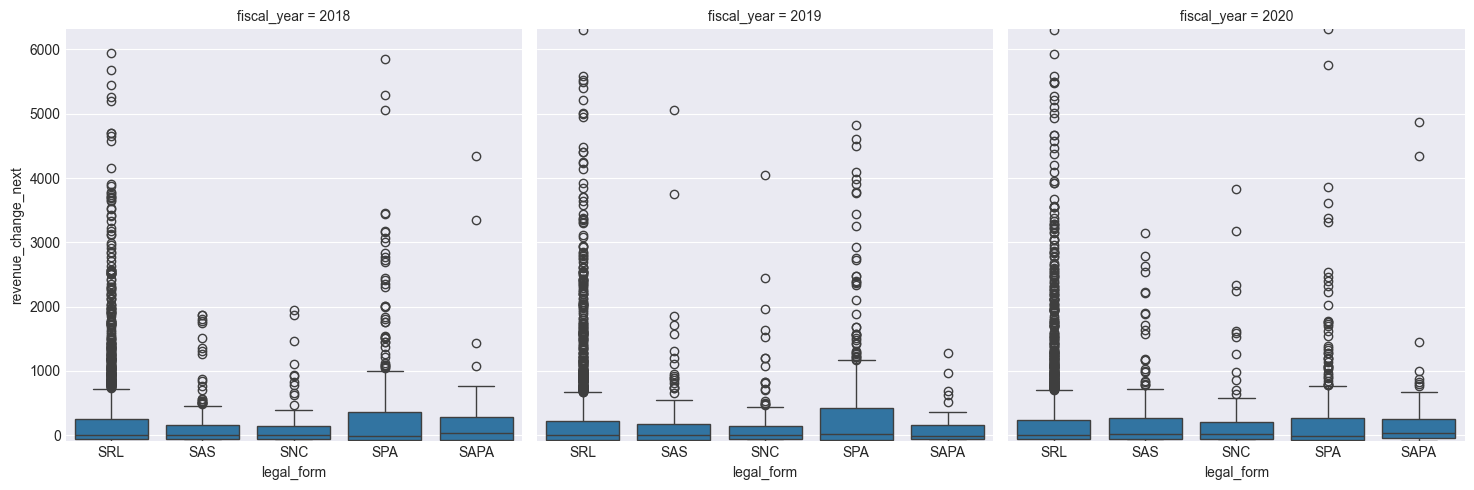

In [17]:
g = sns.FacetGrid(
    eda_df,
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="legal_form",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )

plt.show()

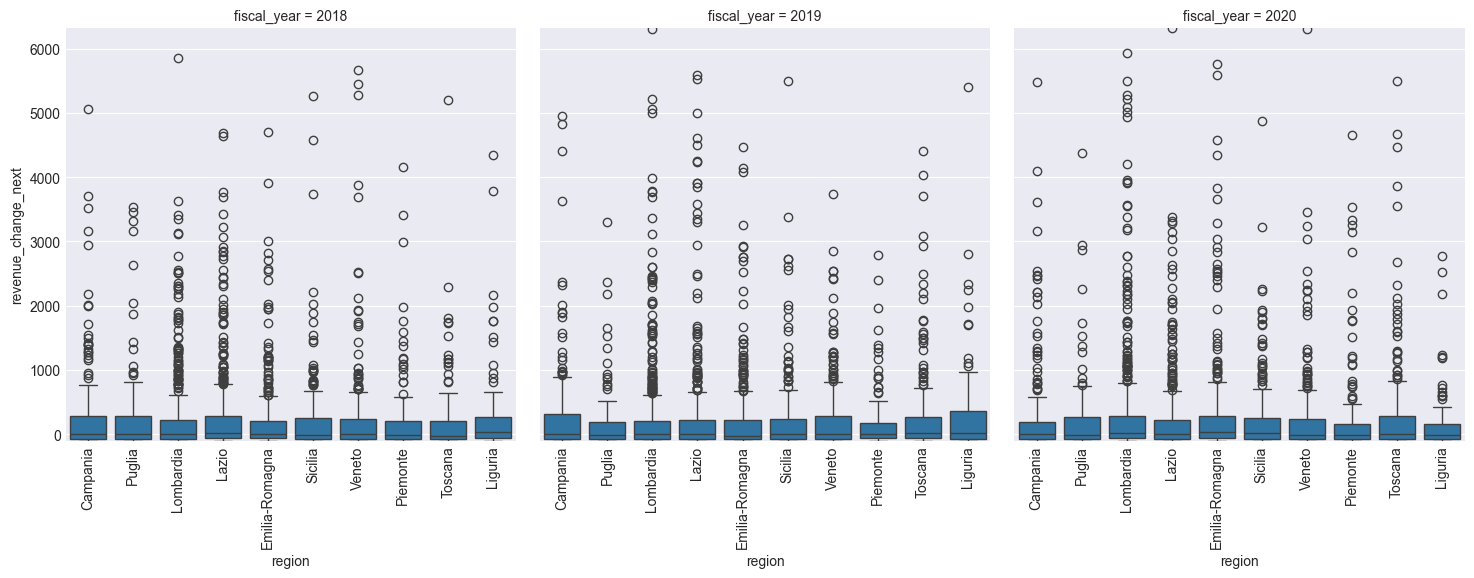

In [18]:
top_regions = eda_df['region'].value_counts().nlargest(10).index

g = sns.FacetGrid(
    eda_df[eda_df['region'].isin(top_regions)],
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="region",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )
    ax.tick_params(axis='x', rotation=90)

plt.show()

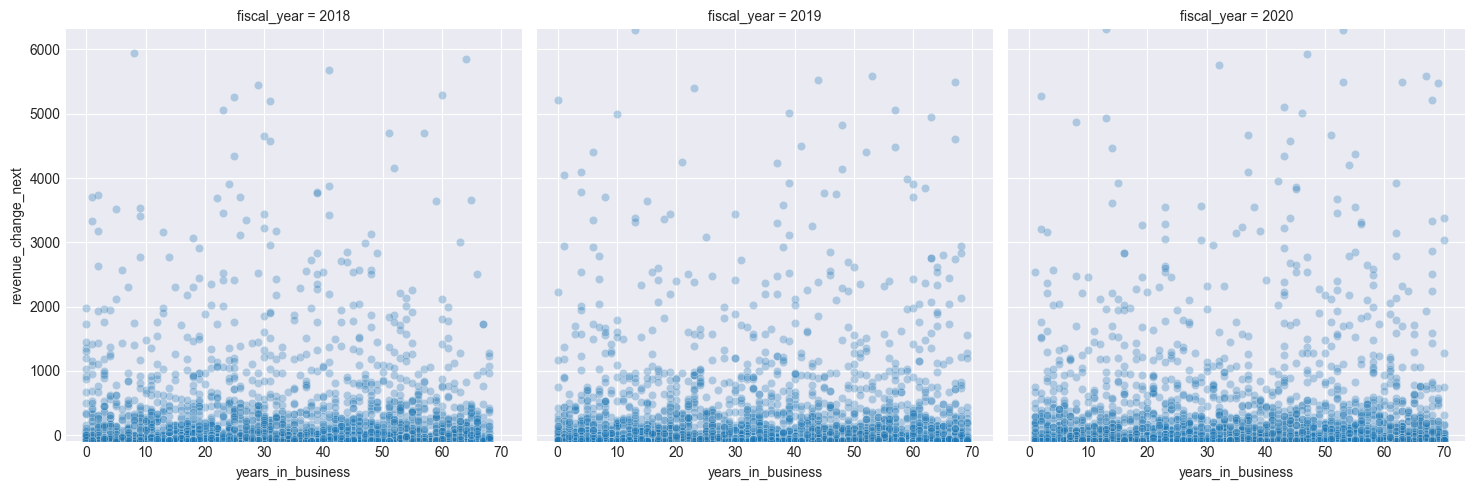

In [19]:
g = sns.FacetGrid(
    eda_df,
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.scatterplot,
    x="years_in_business",
    y="revenue_change_next",
    alpha=0.3
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )

plt.show()

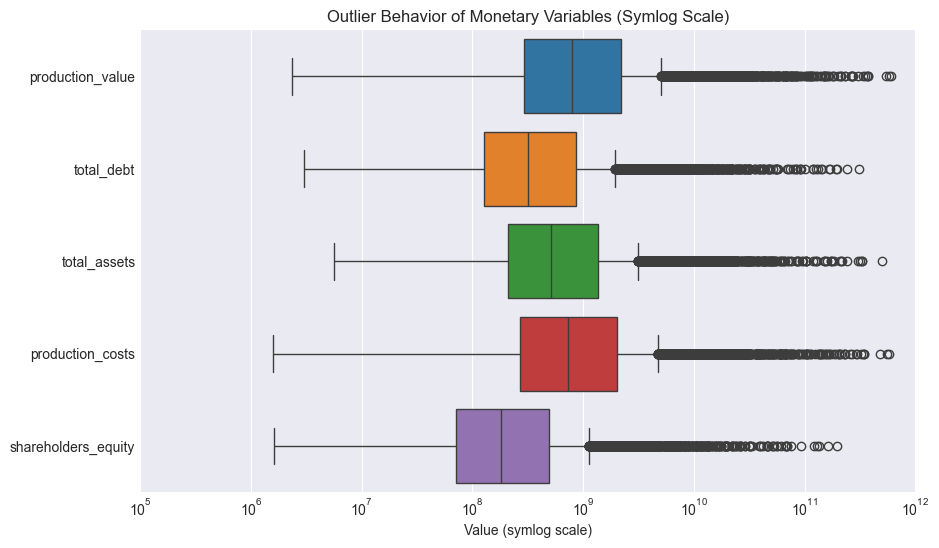

In [20]:
monetary_cols = [
    "production_value",
    "total_debt",
    "total_assets",
    "production_costs",
    "shareholders_equity"
]
plt.figure(figsize=(10,6))

sns.boxplot(
    data=eda_df[monetary_cols],
    orient="h"
)
plt.xscale("symlog")  # handles large values + near zero values

plt.xlim(1e5, 1e12)


plt.title("Outlier Behavior of Monetary Variables (Symlog Scale)")
plt.xlabel("Value (symlog scale)")

plt.show()

### 2.4 Threshold And Tier Event EDA

These views focus on the exact regimes that matter most for the project discussion: sharp declines, high-growth spikes, tier shifts, and equity-gap behavior. They motivate the event-style and fragility features used later.

The purpose here is not to claim that a single threshold solves the problem. It is to show that the dataset contains clear nonlinear regions where a firm moving from one band to another carries more information than a smooth linear effect alone.

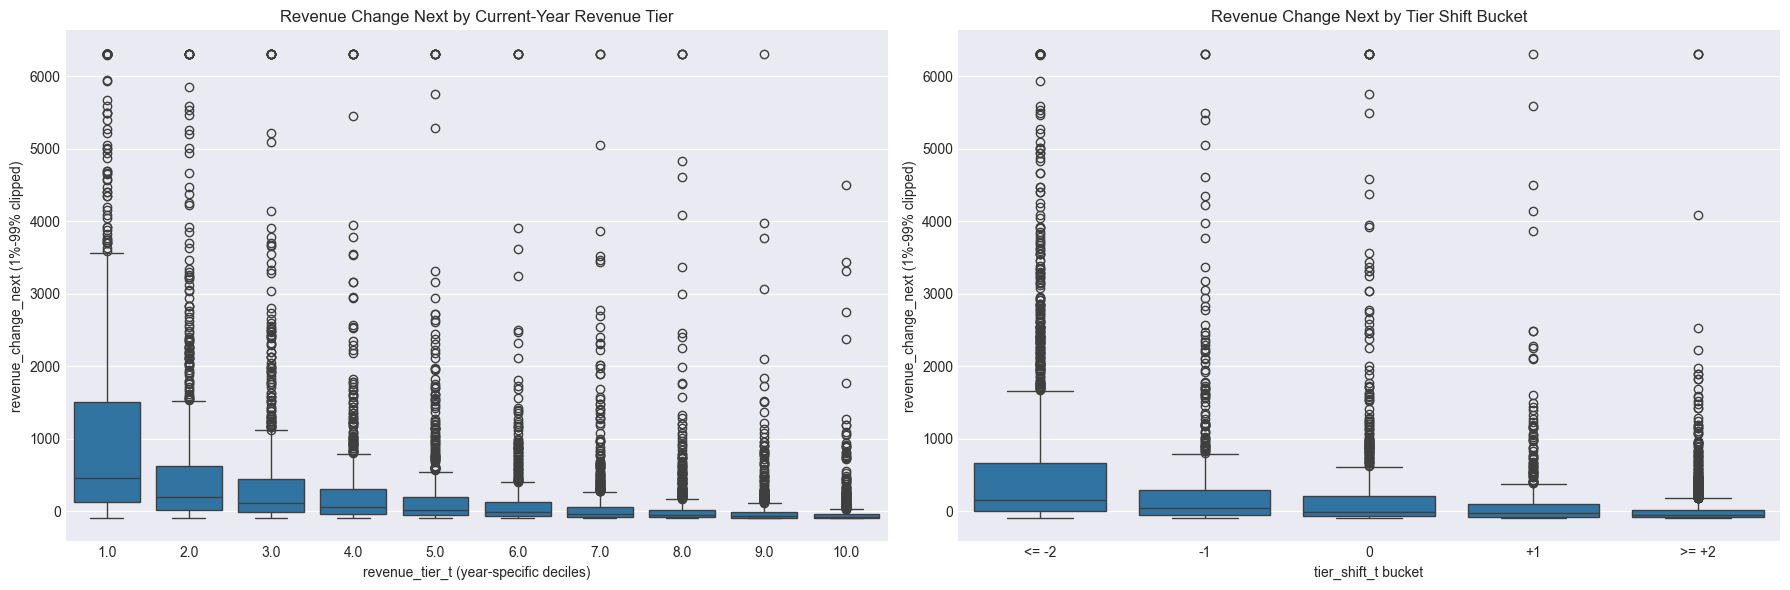

Target behavior by revenue_tier_t:


,revenue_tier_t,n_obs,median_change_next,mean_change_next
0,1.0,885,462.813011,2295.919719
1,2.0,883,190.191720,676.590440
2,3.0,882,107.273637,473.904812
3,4.0,883,53.723506,334.746229
4,5.0,882,18.553817,305.788371
5,6.0,883,-16.217050,178.291388
6,7.0,882,-39.203739,130.474815
7,8.0,883,-54.684693,102.733688
8,9.0,882,-69.043612,37.755237
9,10.0,884,-83.882556,-6.491891


In [21]:
# Revenue-tier / tier-shift EDA (year-specific deciles)

def assign_year_specific_revenue_tier(df, value_col='production_value', year_col='fiscal_year', n_tiers=10):
    tier = pd.Series(np.nan, index=df.index, dtype='float64')

    for _, year_idx in df.groupby(year_col).groups.items():
        year_values = df.loc[year_idx, value_col]
        valid_idx = year_values[year_values.notna()].index

        if len(valid_idx) == 0:
            continue

        ranks = year_values.loc[valid_idx].rank(method='first')
        q = min(n_tiers, len(valid_idx))

        if q < 2:
            tier.loc[valid_idx] = 1
            continue

        tier.loc[valid_idx] = pd.qcut(
            ranks,
            q=q,
            labels=False,
            duplicates='drop'
        ) + 1

    return tier


eda_tier_df = eda_df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

eda_tier_df['revenue_tier_t'] = assign_year_specific_revenue_tier(eda_tier_df)
eda_tier_df['revenue_tier_lag1'] = eda_tier_df.groupby('company_id')['revenue_tier_t'].shift(1)
eda_tier_df['tier_shift_t'] = eda_tier_df['revenue_tier_t'] - eda_tier_df['revenue_tier_lag1']

eda_tier_df['tier_shift_bucket'] = np.select(
    [
        eda_tier_df['tier_shift_t'] <= -2,
        eda_tier_df['tier_shift_t'] == -1,
        eda_tier_df['tier_shift_t'] == 0,
        eda_tier_df['tier_shift_t'] == 1,
        eda_tier_df['tier_shift_t'] >= 2,
    ],
    ['<= -2', '-1', '0', '+1', '>= +2'],
    default=np.nan
)

bucket_order = ['<= -2', '-1', '0', '+1', '>= +2']
eda_tier_df['tier_shift_bucket'] = pd.Categorical(
    eda_tier_df['tier_shift_bucket'],
    categories=bucket_order,
    ordered=True
)

clip_low = eda_tier_df['revenue_change_next'].quantile(0.01)
clip_high = eda_tier_df['revenue_change_next'].quantile(0.99)
eda_tier_df['revenue_change_next_clip'] = eda_tier_df['revenue_change_next'].clip(clip_low, clip_high)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=eda_tier_df[eda_tier_df['revenue_tier_t'].notna()],
    x='revenue_tier_t',
    y='revenue_change_next_clip',
    ax=axes[0]
)
axes[0].set_title('Revenue Change Next by Current-Year Revenue Tier')
axes[0].set_xlabel('revenue_tier_t (year-specific deciles)')
axes[0].set_ylabel('revenue_change_next (1%-99% clipped)')

sns.boxplot(
    data=eda_tier_df[eda_tier_df['tier_shift_bucket'].notna()],
    x='tier_shift_bucket',
    y='revenue_change_next_clip',
    order=bucket_order,
    ax=axes[1]
)
axes[1].set_title('Revenue Change Next by Tier Shift Bucket')
axes[1].set_xlabel('tier_shift_t bucket')
axes[1].set_ylabel('revenue_change_next (1%-99% clipped)')

plt.tight_layout()
plt.show()


tier_target_summary = (
    eda_tier_df.groupby('revenue_tier_t', dropna=False)
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean')
    )
    .reset_index()
    .sort_values('revenue_tier_t')
)

shift_target_summary = (
    eda_tier_df.groupby(['tier_shift_bucket', 'tier_shift_t'], observed=False)
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean')
    )
    .reset_index()
)

print('Target behavior by revenue_tier_t:')
display(tier_target_summary)



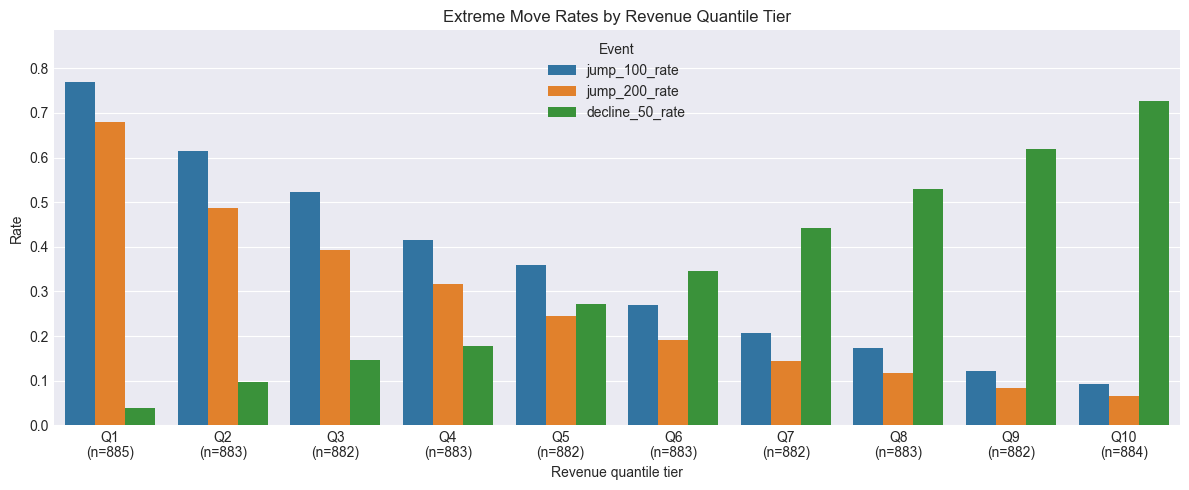

Extreme move rate summary by revenue quantile tier:


,tier_label,n,jump_100_rate,jump_200_rate,decline_50_rate
0,Q1,885,0.769492,0.680226,0.039548
1,Q2,883,0.613817,0.488109,0.096263
2,Q3,882,0.523810,0.393424,0.147392
3,Q4,883,0.414496,0.317101,0.178935
4,Q5,882,0.358277,0.244898,0.270975
5,Q6,883,0.270668,0.190260,0.345413
6,Q7,882,0.206349,0.143991,0.442177
7,Q8,883,0.174405,0.116648,0.530011
8,Q9,882,0.121315,0.082766,0.619048
9,Q10,884,0.091629,0.066742,0.726244


In [22]:
# Extreme move rates by revenue quantile tier (requested right-side chart)

rate_df = eda_tier_df.copy()

rate_df = rate_df[rate_df['revenue_tier_t'].notna() & rate_df['revenue_change_next'].notna()].copy()
rate_df['tier_int'] = pd.to_numeric(rate_df['revenue_tier_t'], errors='coerce').round().astype('Int64')
rate_df = rate_df[rate_df['tier_int'].notna()].copy()
rate_df['tier_int'] = rate_df['tier_int'].astype(int)

extreme_rate_summary = (
    rate_df.groupby('tier_int')
    .agg(
        n=('company_id', 'size'),
        jump_100_rate=('revenue_change_next', lambda s: (s > 100).mean()),
        jump_200_rate=('revenue_change_next', lambda s: (s > 200).mean()),
        decline_50_rate=('revenue_change_next', lambda s: (s < -50).mean())
    )
    .reindex(range(1, 11))
    .reset_index()
)

extreme_rate_summary['tier_label'] = extreme_rate_summary['tier_int'].apply(lambda x: f'Q{x}' if pd.notna(x) else np.nan)
extreme_rate_summary['tier_tick'] = extreme_rate_summary.apply(
    lambda r: f"{r['tier_label']}\n(n={int(r['n'])})" if pd.notna(r['n']) else f"{r['tier_label']}\n(n=0)",
    axis=1
)

plot_df = extreme_rate_summary.melt(
    id_vars=['tier_int', 'tier_label', 'tier_tick', 'n'],
    value_vars=['jump_100_rate', 'jump_200_rate', 'decline_50_rate'],
    var_name='Event',
    value_name='Rate'
)

event_order = ['jump_100_rate', 'jump_200_rate', 'decline_50_rate']

plt.figure(figsize=(12, 5))
sns.barplot(
    data=plot_df,
    x='tier_tick',
    y='Rate',
    hue='Event',
    hue_order=event_order,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c']
)

plt.title('Extreme Move Rates by Revenue Quantile Tier')
plt.xlabel('Revenue quantile tier')
plt.ylabel('Rate')
plt.ylim(0, min(1.0, max(0.05, plot_df['Rate'].max() * 1.15)))
plt.legend(title='Event')
plt.tight_layout()
plt.show()

print('Extreme move rate summary by revenue quantile tier:')
display(extreme_rate_summary[['tier_label', 'n', 'jump_100_rate', 'jump_200_rate', 'decline_50_rate']])


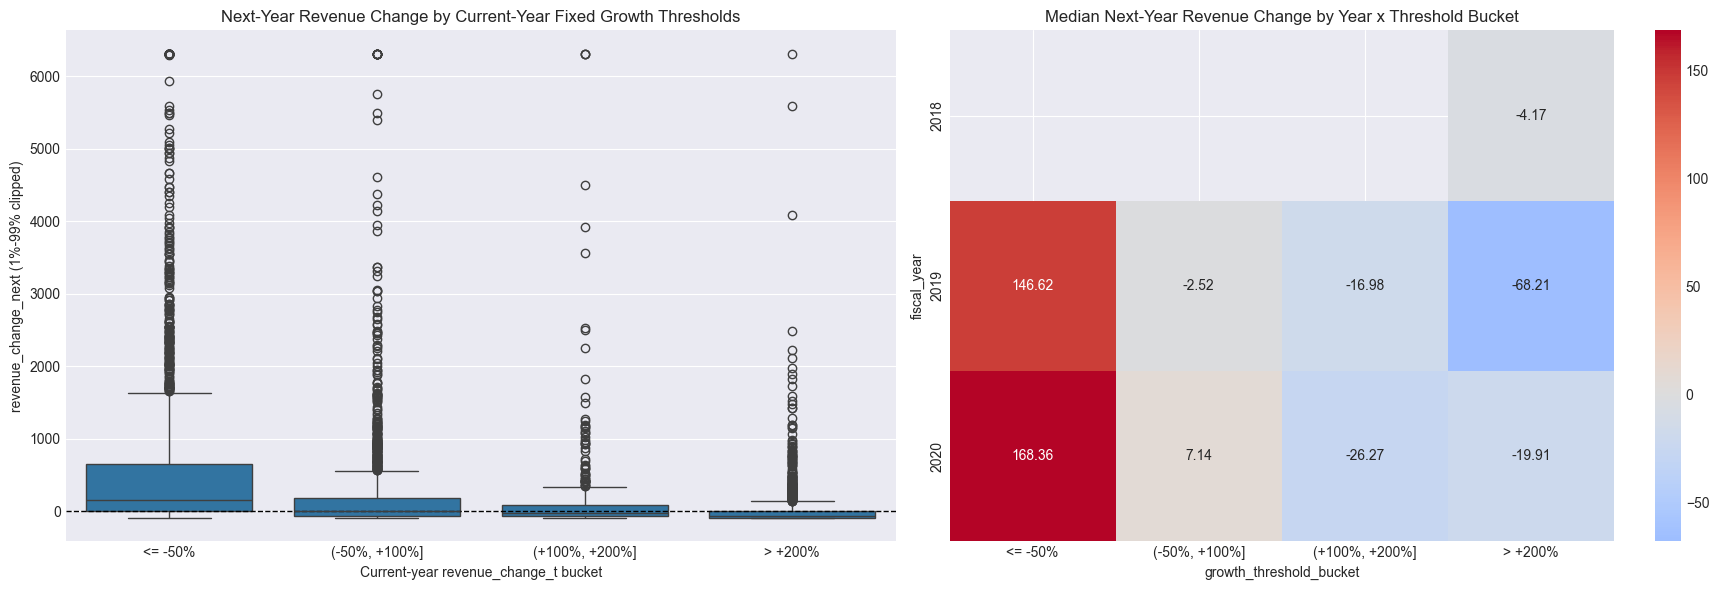

Fixed-threshold summary (-50%, +100%, +200%):


,growth_threshold_bucket,n_obs,median_change_next,mean_change_next
0,<= -50%,2008,156.536266,1116.818835
1,"(-50%, +100%]",1788,0.220348,258.600583
2,"(+100%, +200%]",463,-21.937055,190.773090
3,> +200%,1591,-67.312364,21.317507


In [23]:
# Fixed-threshold event EDA (-50%, +100%, +200%)
# Uses current-year growth signal to study next-year target behavior, clipped to 1%-99% for readability.

eda_threshold_df = eda_tier_df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

eda_threshold_df['production_value_lag1'] = (
    eda_threshold_df.groupby('company_id')['production_value'].shift(1)
)

eda_threshold_df['revenue_change_t'] = 100 * (
    eda_threshold_df['production_value'] - eda_threshold_df['production_value_lag1']
) / eda_threshold_df['production_value_lag1'].replace(0, np.nan)

eda_threshold_df['growth_threshold_bucket'] = np.select(
    [
        eda_threshold_df['revenue_change_t'] <= -50,
        (eda_threshold_df['revenue_change_t'] > -50) & (eda_threshold_df['revenue_change_t'] <= 100),
        (eda_threshold_df['revenue_change_t'] > 100) & (eda_threshold_df['revenue_change_t'] <= 200),
        eda_threshold_df['revenue_change_t'] > 200,
    ],
    ['<= -50%', '(-50%, +100%]', '(+100%, +200%]', '> +200%'],
    default=np.nan
)

threshold_order = ['<= -50%', '(-50%, +100%]', '(+100%, +200%]', '> +200%']
eda_threshold_df['growth_threshold_bucket'] = pd.Categorical(
    eda_threshold_df['growth_threshold_bucket'],
    categories=threshold_order,
    ordered=True
)

clip_low = eda_threshold_df['revenue_change_next'].quantile(0.01)
clip_high = eda_threshold_df['revenue_change_next'].quantile(0.99)
eda_threshold_df['revenue_change_next_clip'] = eda_threshold_df['revenue_change_next'].clip(clip_low, clip_high)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=eda_threshold_df[eda_threshold_df['growth_threshold_bucket'].notna()],
    x='growth_threshold_bucket',
    y='revenue_change_next_clip',
    order=threshold_order,
    ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Next-Year Revenue Change by Current-Year Fixed Growth Thresholds')
axes[0].set_xlabel('Current-year revenue_change_t bucket')
axes[0].set_ylabel('revenue_change_next (1%-99% clipped)')

threshold_year_median = (
    eda_threshold_df.groupby(['fiscal_year', 'growth_threshold_bucket'], observed=False)['revenue_change_next']
    .median()
    .unstack('growth_threshold_bucket')
    .reindex(columns=threshold_order)
)

sns.heatmap(
    threshold_year_median,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=axes[1]
)
axes[1].set_title('Median Next-Year Revenue Change by Year x Threshold Bucket')
axes[1].set_xlabel('growth_threshold_bucket')
axes[1].set_ylabel('fiscal_year')

plt.tight_layout()
plt.show()

threshold_summary = (
    eda_threshold_df.groupby('growth_threshold_bucket', observed=False)
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean')
    )
    .reindex(threshold_order)
    .reset_index()
)

print('Fixed-threshold summary (-50%, +100%, +200%):')
display(threshold_summary)


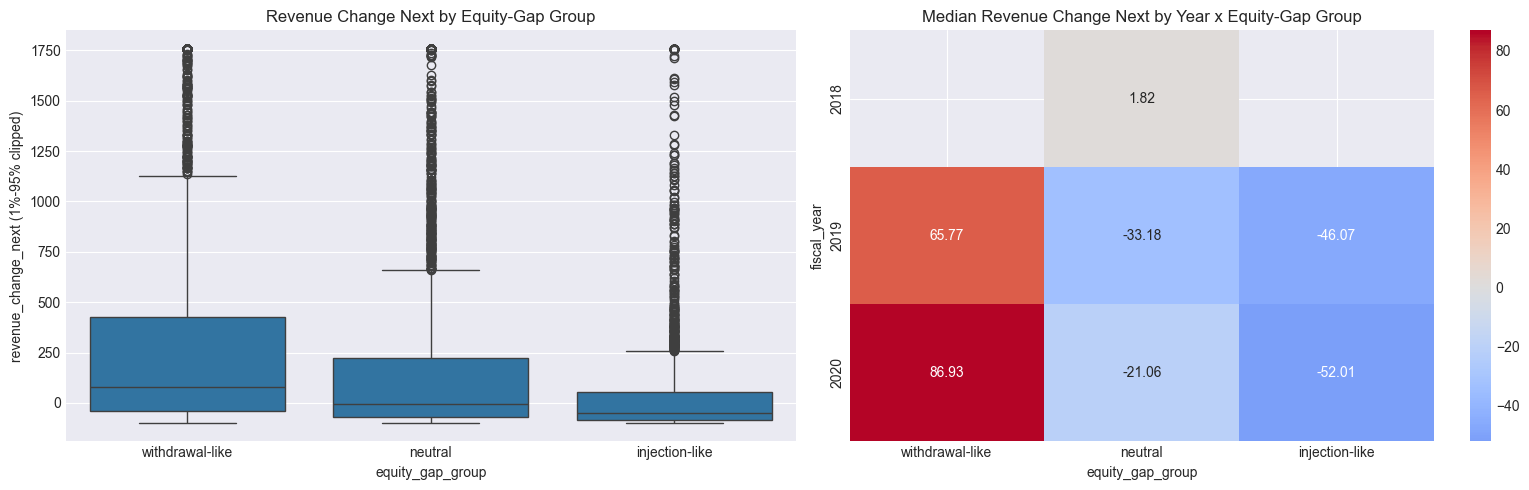

Equity-gap proxy summary (neutral interpretation):


,equity_gap_group,n_obs,median_change_next,mean_change_next,shock_rate
0,withdrawal-like,3209,77.675751,775.303470,1.0
1,neutral,3428,-3.242928,361.510613,0.0
2,injection-like,2192,-49.932114,125.988420,1.0


In [24]:
# Equity-gap proxy EDA (capital injection/withdrawal signal, neutral naming)

eda_equity_df = eda_df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

eda_equity_df['shareholders_equity_lag1'] = (
    eda_equity_df.groupby('company_id')['shareholders_equity'].shift(1)
)

eda_equity_df['equity_expected_from_profit'] = (
    eda_equity_df['shareholders_equity_lag1'] + eda_equity_df['net_profit_loss']
)

eda_equity_df['equity_gap'] = (
    eda_equity_df['shareholders_equity'] - eda_equity_df['equity_expected_from_profit']
)

eda_equity_df['equity_gap_pct_assets'] = (
    eda_equity_df['equity_gap'] / eda_equity_df['total_assets'].replace(0, np.nan)
)

EQUITY_GAP_ASSET_THRESHOLD = 0.04  # 4% of assets threshold for injection/withdrawal-like shock

eda_equity_df['equity_injection_flag'] = (
    eda_equity_df['equity_gap_pct_assets'] >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)

eda_equity_df['equity_withdrawal_flag'] = (
    eda_equity_df['equity_gap_pct_assets'] <= -EQUITY_GAP_ASSET_THRESHOLD
).astype(int)

eda_equity_df['equity_shock_flag'] = (
    eda_equity_df['equity_gap_pct_assets'].abs() >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)

eda_equity_df['equity_gap_group'] = np.select(
    [
        eda_equity_df['equity_injection_flag'] == 1,
        eda_equity_df['equity_withdrawal_flag'] == 1,
    ],
    ['injection-like', 'withdrawal-like'],
    default='neutral'
)

group_order = ['withdrawal-like', 'neutral', 'injection-like']
clip_low = eda_equity_df['revenue_change_next'].quantile(0.01)
clip_high = eda_equity_df['revenue_change_next'].quantile(0.95)
eda_equity_df['revenue_change_next_clip'] = eda_equity_df['revenue_change_next'].clip(clip_low, clip_high)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=eda_equity_df,
    x='equity_gap_group',
    y='revenue_change_next_clip',
    order=group_order,
    ax=axes[0]
)
axes[0].set_title('Revenue Change Next by Equity-Gap Group')
axes[0].set_xlabel('equity_gap_group')
axes[0].set_ylabel('revenue_change_next (1%-95% clipped)')

year_group_pivot = (
    eda_equity_df.groupby(['fiscal_year', 'equity_gap_group'])['revenue_change_next']
    .median()
    .unstack('equity_gap_group')
    .reindex(columns=group_order)
)

sns.heatmap(
    year_group_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=axes[1]
)
axes[1].set_title('Median Revenue Change Next by Year x Equity-Gap Group')
axes[1].set_xlabel('equity_gap_group')
axes[1].set_ylabel('fiscal_year')

plt.tight_layout()
plt.show()


equity_group_summary = (
    eda_equity_df.groupby('equity_gap_group')
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean'),
        shock_rate=('equity_shock_flag', 'mean')
    )
    .reindex(group_order)
    .reset_index()
)

print('Equity-gap proxy summary (neutral interpretation):')
display(equity_group_summary)


### 2.5 EDA Summary

- Revenue change is highly skewed, with a small set of collapse and breakout cases driving much of the raw RMSE.
- A meaningful share of firms sit close to zero growth, so small absolute misses can create very large percentage errors.
- Debt structure, thin margins, peer-relative growth, and equity-gap behavior all look more promising than raw size variables alone.
- Tier shifts and threshold-style events appear strong enough to justify explicit regime and fragility features.

Taken together, the EDA suggests that the forecasting task is partly a standard regression problem and partly a regime-identification problem. That is why the rest of the notebook combines continuous forecasting, event-style features, and a supplementary regime-classification view.

## 3. Data Preprocessing

The preprocessing policy stays intentionally conservative. Province cleaning, missing-value handling, winsorization bounds, grouped priors, and categorical levels are all learned from training years only.

Near-zero targets need special care. The notebook still reports raw `MAPE` for completeness, but it emphasizes trimmed percentage error, `WAPE`, `SMAPE`, direction, and ranking quality because those remain interpretable when actual growth is close to zero.

### 3.1 Modeling Dataset Construction

The notebook now switches from EDA to the modeling table. This step creates the fitting target, the business evaluation target, and the row set that has a valid next-year label.

The distinction matters: the model is fit on `log_production_value_next` for numerical stability, but all business reporting is translated back into `revenue_change_next`.

In [25]:
# Load datasets
train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_features.csv')

target_cols_to_drop = ['bankruptcy_next_year', 'financial_health_class']
train_df = train_df.drop(columns=target_cols_to_drop).copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain years:", sorted(train_df['fiscal_year'].unique()))
print("Test years:", sorted(test_df['fiscal_year'].unique()))

print("\nTrain columns:", len(train_df.columns))
print("Test columns:", len(test_df.columns))


Train shape: (11828, 28)
Test shape: (5811, 27)

Train years: [2018, 2019, 2020, 2021]
Test years: [2022, 2023]

Train columns: 28
Test columns: 27


In [26]:
# Build log-next-revenue target and derived next-year revenue change for evaluation
full_df = pd.concat([train_df, test_df], axis=0, sort=False)
full_df = full_df.sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

# Domain correction: source-system missing/NA province values correspond to Napoli.
if 'province' in full_df.columns:
    province_missing_mask = full_df['province'].isna()
    province_na_mask = (
        full_df['province']
        .astype('string')
        .str.strip()
        .str.upper()
        .eq('NA')
        .fillna(False)
    )
    province_napoli_mask = province_missing_mask | province_na_mask
    province_napoli_count = int(province_napoli_mask.sum())
    full_df.loc[province_napoli_mask, 'province'] = 'Napoli'
    print(f"Province cleaning: reassigned {province_napoli_count} missing/'NA' province values to 'Napoli'.")

full_df['production_value_next'] = (
    full_df.groupby('company_id')['production_value'].shift(-1)
)
full_df['log_production_value_next'] = np.log1p(full_df['production_value_next'].clip(lower=0))
full_df['revenue_change_next'] = 100 * (
    full_df['production_value_next'] - full_df['production_value']
) / full_df['production_value'].replace(0, np.nan)
full_df.loc[~np.isfinite(full_df['revenue_change_next']), 'revenue_change_next'] = np.nan

print('Target columns created: log_production_value_next for fitting, revenue_change_next for evaluation.')
print('Non-finite revenue_change_next rows set to NaN:', int(full_df['revenue_change_next'].isna().sum()))
print(full_df[[
    'company_id', 'fiscal_year', 'production_value', 'production_value_next',
    'log_production_value_next', 'revenue_change_next'
]].head(10))


Province cleaning: reassigned 1370 missing/'NA' province values to 'Napoli'.
Target columns created: log_production_value_next for fitting, revenue_change_next for evaluation.
Non-finite revenue_change_next rows set to NaN: 2999
   company_id  fiscal_year  production_value  production_value_next  \
0  COMP_00000         2018      1.846636e+09           4.289159e+08   
1  COMP_00000         2019      4.289159e+08           6.956197e+09   
2  COMP_00000         2020      6.956197e+09           5.031839e+08   
3  COMP_00000         2021      5.031839e+08           3.898393e+08   
4  COMP_00000         2022      3.898393e+08           7.742371e+09   
5  COMP_00000         2023      7.742371e+09                    NaN   
6  COMP_00001         2018      4.113380e+08           1.595547e+09   
7  COMP_00001         2019      1.595547e+09           1.827539e+08   
8  COMP_00001         2020      1.827539e+08           2.613448e+09   
9  COMP_00001         2021      2.613448e+09           1.4392

In [27]:
# Keep only rows where next year's production value target exists
model_df = full_df.dropna(subset=['production_value_next', 'log_production_value_next', 'revenue_change_next']).copy()

print("Model dataset shape:", model_df.shape)
print("\nYears in model dataset:", sorted(model_df['fiscal_year'].unique()))

print("\nRows by year:")
print(model_df['fiscal_year'].value_counts().sort_index())


Model dataset shape: (14640, 31)

Years in model dataset: [2018, 2019, 2020, 2021, 2022]

Rows by year:
fiscal_year
2018    2941
2019    2956
2020    2932
2021    2916
2022    2895
Name: count, dtype: int64


### 3.2 Year Coverage And Panel Structure

The bankruptcy notebook treats panel completeness as a real signal rather than a housekeeping detail, and the same logic applies here. Each row is a company-year, and not every company appears across the full labeled window.

That matters because missing years, first appearances, and short histories can correspond to restructurings, mergers, inactivity, or other structural breaks. The panel audit therefore informs both interpretation and the later continuity features.

In [28]:
# Year coverage and panel-entry audit
year_entry_summary = (
    full_df.groupby('fiscal_year')
    .agg(
        rows=('company_id', 'size'),
        companies=('company_id', 'nunique'),
        labeled_revenue_targets=('revenue_change_next', lambda s: s.notna().sum()),
        median_revenue_change_next=('revenue_change_next', 'median'),
        pct_near_zero_target=('revenue_change_next', lambda s: s.abs().le(10).mean() * 100),
    )
    .reset_index()
)

train_years_available = sorted(train_df['fiscal_year'].unique())
test_years_available = sorted(test_df['fiscal_year'].unique())
model_years_available = sorted(model_df['fiscal_year'].unique())

print('Train years:', train_years_available)
print('Test feature years:', test_years_available)
print('Model/evaluation source years:', model_years_available)
display(year_entry_summary.round(4))

full_years = sorted(full_df['fiscal_year'].dropna().unique())
company_panel = (
    full_df.groupby('company_id')['fiscal_year']
    .agg(first_year='min', last_year='max', years_observed='nunique')
    .reset_index()
)
company_panel['expected_years_between_first_last'] = (
    company_panel['last_year'] - company_panel['first_year'] + 1
)
company_panel['missing_years_between_first_last'] = (
    company_panel['expected_years_between_first_last'] - company_panel['years_observed']
)
company_panel['complete_available_panel'] = (
    company_panel['years_observed'] == len(full_years)
).astype(int)

panel_completeness_summary = (
    company_panel.assign(
        panel_status=np.where(
            company_panel['complete_available_panel'].eq(1),
            'Complete available panel',
            'Incomplete available panel'
        )
    )
    .groupby('panel_status')
    .agg(
        companies=('company_id', 'count'),
        median_years_observed=('years_observed', 'median'),
        mean_missing_years=('missing_years_between_first_last', 'mean'),
    )
    .reset_index()
)

print('Company-level panel completeness:')
display(panel_completeness_summary.round(4))

entry_exit_summary = (
    company_panel.groupby(['first_year', 'last_year'])
    .size()
    .reset_index(name='companies')
    .sort_values(['first_year', 'last_year'])
)
print('Company entry and last-observed year counts:')
display(entry_exit_summary)


Train years: [2018, 2019, 2020, 2021]
Test feature years: [2022, 2023]
Model/evaluation source years: [2018, 2019, 2020, 2021, 2022]


,fiscal_year,rows,companies,labeled_revenue_targets,median_revenue_change_next,pct_near_zero_target
0,2018,2961,2961,2941,1.8159,4.9645
1,2019,2979,2979,2956,0.3402,4.4310
2,2020,2956,2956,2932,7.4956,4.6008
3,2021,2932,2932,2916,-4.6057,4.7067
4,2022,2916,2916,2895,1.9802,4.8697
5,2023,2895,2895,0,NaN,0.0000


Company-level panel completeness:


,panel_status,companies,median_years_observed,mean_missing_years
0,Complete available panel,2858,6.0,0.0
1,Incomplete available panel,141,4.0,0.0


Company entry and last-observed year counts:


,first_year,last_year,companies
0,2018,2018,20
1,2018,2019,23
2,2018,2020,23
3,2018,2021,16
4,2018,2022,21
5,2018,2023,2858
6,2019,2020,1
7,2019,2023,37


In [29]:
# Define sliding window folds
# 2020 is validation; 2021 is treated as a test-like holdout in the project narrative.
# 2022+ remain separate held-out years from test_features.
folds = [
    {'fold_name': 'Fold 1', 'train_years': [2018, 2019],       'val_year': 2020},
    {'fold_name': 'Fold 2', 'train_years': [2018, 2019, 2020], 'val_year': 2021},
]

for fold in folds:
    print(f"{fold['fold_name']}: train = {fold['train_years']}, val = {fold['val_year']}")


Fold 1: train = [2018, 2019], val = 2020
Fold 2: train = [2018, 2019, 2020], val = 2021


In [30]:
# Define columns
id_cols = ['company_id', 'fiscal_year']
target_col = 'log_production_value_next'
eval_target_col = 'revenue_change_next'

feature_exclusion_cols = [target_col, eval_target_col, 'production_value_next']
feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + feature_exclusion_cols
]

print('Training target:', target_col)
print('Evaluation target:', eval_target_col)
print('Number of feature columns:', len(feature_cols))
print("\nFeature columns:")
print(feature_cols)


Training target: log_production_value_next
Evaluation target: revenue_change_next
Number of feature columns: 26

Feature columns:
['province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin', 'revenue_change']


In [31]:
def get_fold_data(model_df, feature_cols, target_col, train_years, val_year):
    train_data = model_df[model_df['fiscal_year'].isin(train_years)].copy()
    val_data = model_df[model_df['fiscal_year'] == val_year].copy()

    X_train = train_data[feature_cols].copy()
    y_train = train_data[target_col].copy()

    X_val = val_data[feature_cols].copy()
    y_val = val_data[target_col].copy()

    return train_data, val_data, X_train, y_train, X_val, y_val

In [32]:
fold_1 = folds[0]

train_data, val_data, X_train, y_train, X_val, y_val = get_fold_data(
    model_df=model_df,
    feature_cols=feature_cols,
    target_col=target_col,
    train_years=fold_1['train_years'],
    val_year=fold_1['val_year']
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nTrain years:", sorted(train_data['fiscal_year'].unique()))
print("Validation year:", val_data['fiscal_year'].unique())

Train shape: (5897, 26)
Validation shape: (2932, 26)

Train years: [2018, 2019]
Validation year: [2020]


In [33]:
def evaluate_revenue_change(y_true_rev_change, y_pred_rev_change):
    # Metrics on revenue change target directly
    r2 = r2_score(y_true_rev_change, y_pred_rev_change)
    rmse = np.sqrt(mean_squared_error(y_true_rev_change, y_pred_rev_change))
    mae = mean_absolute_error(y_true_rev_change, y_pred_rev_change)

    # Avoid division by zero in MAPE
    mask = y_true_rev_change != 0
    mape = np.mean(
        np.abs((y_true_rev_change[mask] - y_pred_rev_change[mask]) / y_true_rev_change[mask])
    ) * 100

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


In [34]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

import numpy as np
import pandas as pd

# Sort panel data
model_df = model_df.sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

# Group by company once
grp = model_df.groupby('company_id')

def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den

### 4.1 Core Temporal And Structural Features

Feature engineering starts with lagged growth, temporal stability, capital-structure proxies, and leakage-safe grouped context. The focus is to create signals that remain defensible in a time-ordered setting.

The important principle is that every engineered feature should answer a business question: is the firm deteriorating, stabilizing, structurally fragile, or unusual relative to its peers and its own recent history?

In [35]:
# Core momentum / lag features


# Previous revenue levels
model_df['production_value_lag1'] = grp['production_value'].shift(1)
model_df['production_value_lag2'] = grp['production_value'].shift(2)


# Current revenue growth computed from production_value only
model_df['revenue_change'] = safe_div(
    model_df['production_value'] - model_df['production_value_lag1'],
    model_df['production_value_lag1']
) * 100


# Revenue growth history
model_df['rev_growth_lag1'] = grp['revenue_change'].shift(1)
model_df['rev_growth_lag2'] = grp['revenue_change'].shift(2)
model_df['rev_growth_accel'] = model_df['rev_growth_lag1'] - model_df['rev_growth_lag2']
model_df['rev_growth_avg2'] = model_df[['rev_growth_lag1', 'rev_growth_lag2']].mean(axis=1)
model_df['current_growth_abs'] = model_df['revenue_change'].abs()
model_df['current_near_zero_growth_flag'] = model_df['current_growth_abs'].le(10).astype(int)
model_df['current_moderate_growth_flag'] = model_df['current_growth_abs'].le(50).astype(int)
model_df['current_growth_stability_score'] = 1 / (1 + model_df['current_growth_abs'].fillna(0))
model_df['rev_growth_abs_lag1'] = model_df['rev_growth_lag1'].abs()
model_df['rev_growth_abs_accel'] = model_df['rev_growth_accel'].abs()
model_df['rev_growth_volatility_2yr'] = model_df[['rev_growth_lag1', 'rev_growth_lag2']].std(axis=1)
model_df['near_zero_growth_lag1_flag'] = model_df['rev_growth_abs_lag1'].le(10).astype(int)
model_df['persistent_near_zero_growth_flag'] = (
    model_df['rev_growth_lag1'].abs().le(10) &
    model_df['rev_growth_lag2'].abs().le(10)
).astype(int)
model_df['growth_sign_flip_lag_flag'] = (
    np.sign(model_df['rev_growth_lag1']) != np.sign(model_df['rev_growth_lag2'])
).astype(int)
model_df.loc[model_df[['rev_growth_lag1', 'rev_growth_lag2']].isna().any(axis=1), 'growth_sign_flip_lag_flag'] = 0
model_df['growth_stability_score'] = 1 / (
    1 + model_df['current_growth_abs'].fillna(0) + model_df['rev_growth_abs_accel'].fillna(0)
)

# Panel continuity features use only the current and previously observed company years.
model_df['panel_obs_number'] = grp.cumcount() + 1
model_df['first_observed_year_so_far'] = grp['fiscal_year'].transform('first')
model_df['years_since_first_observed'] = (
    model_df['fiscal_year'] - model_df['first_observed_year_so_far']
)
model_df['expected_observations_so_far'] = model_df['years_since_first_observed'] + 1
model_df['missing_years_so_far'] = (
    model_df['expected_observations_so_far'] - model_df['panel_obs_number']
).clip(lower=0)
model_df['panel_continuity_ratio'] = safe_div(
    model_df['panel_obs_number'],
    model_df['expected_observations_so_far']
)
model_df['previous_observed_year'] = grp['fiscal_year'].shift(1)
model_df['years_since_previous_observation'] = (
    model_df['fiscal_year'] - model_df['previous_observed_year']
)
model_df['panel_gap_flag'] = model_df['years_since_previous_observation'].gt(1).fillna(False).astype(int)
model_df['first_panel_year_flag'] = model_df['panel_obs_number'].eq(1).astype(int)


# Legacy fixed-threshold diagnostics (kept for reference, not used in ma_confidence_score)
model_df['high_growth_flag'] = (model_df['revenue_change'] > 100).astype(int)
model_df['negative_growth_flag'] = (model_df['revenue_change'] < 0).astype(int)
model_df['extreme_growth_flag'] = (model_df['revenue_change'] > 200).astype(int)
model_df['extreme_decline_flag'] = (model_df['revenue_change'] < -50).astype(int)


# Explicit extreme-event dummies requested for -50% / 200% thresholds
model_df['rev_decline_below_m50_dummy'] = (model_df['revenue_change'] < -50).astype(int)
model_df['rev_growth_above_200_dummy'] = (model_df['revenue_change'] > 200).astype(int)
model_df['rev_extreme_event_dummy'] = (
    (model_df['revenue_change'] < -50) | (model_df['revenue_change'] > 200)
).astype(int)


# Revenue size regime features (year-specific deciles within each fiscal year)
def assign_year_specific_revenue_tier(df, value_col='production_value', year_col='fiscal_year', n_tiers=10):
    tier = pd.Series(np.nan, index=df.index, dtype='float64')

    for _, year_idx in df.groupby(year_col).groups.items():
        year_values = df.loc[year_idx, value_col]
        valid_idx = year_values[year_values.notna()].index

        if len(valid_idx) == 0:
            continue

        ranks = year_values.loc[valid_idx].rank(method='first')
        q = min(n_tiers, len(valid_idx))

        if q < 2:
            tier.loc[valid_idx] = 1
            continue

        tier.loc[valid_idx] = pd.qcut(
            ranks,
            q=q,
            labels=False,
            duplicates='drop'
        ) + 1

    return tier


model_df['revenue_tier_t'] = assign_year_specific_revenue_tier(model_df)
model_df['revenue_tier_lag1'] = model_df.groupby('company_id')['revenue_tier_t'].shift(1)
model_df['tier_shift_t'] = model_df['revenue_tier_t'] - model_df['revenue_tier_lag1']
model_df['large_tier_jump_flag'] = model_df['tier_shift_t'].abs().ge(2).astype(int)


# Size-specific growth thresholds by revenue tier.
# Thresholds are estimated from prior years only, so validation rows do not borrow future distributions.
def add_temporal_tier_growth_thresholds(df):
    out = df.copy()
    threshold_cols = [
        'tier_p1_growth',
        'tier_p5_growth',
        'tier_median_growth',
        'tier_p95_growth',
        'tier_p99_growth',
        'tier_std_growth',
        'tier_growth_count',
    ]
    for col in threshold_cols:
        out[col] = np.nan

    for year in sorted(out['fiscal_year'].dropna().unique()):
        row_mask = out['fiscal_year'].eq(year)
        fit_mask = (
            out['fiscal_year'].lt(year) &
            out['revenue_tier_t'].notna() &
            out['revenue_change'].notna()
        )
        if not fit_mask.any():
            continue

        stats = (
            out.loc[fit_mask]
            .groupby('revenue_tier_t')['revenue_change']
            .agg(
                tier_p1_growth=lambda s: s.quantile(0.01),
                tier_p5_growth=lambda s: s.quantile(0.05),
                tier_median_growth='median',
                tier_p95_growth=lambda s: s.quantile(0.95),
                tier_p99_growth=lambda s: s.quantile(0.99),
                tier_std_growth='std',
                tier_growth_count='count',
            )
        )

        mapped = out.loc[row_mask, ['revenue_tier_t']].join(stats, on='revenue_tier_t')
        out.loc[row_mask, threshold_cols] = mapped[threshold_cols].to_numpy()

    out['tier_std_growth'] = out['tier_std_growth'].replace(0, np.nan)
    return out

model_df = add_temporal_tier_growth_thresholds(model_df)
grp = model_df.groupby('company_id')

tier_threshold_table = (
    model_df.loc[model_df['fiscal_year'].isin([2020, 2021]), [
        'fiscal_year',
        'revenue_tier_t',
        'tier_p1_growth',
        'tier_p5_growth',
        'tier_median_growth',
        'tier_p95_growth',
        'tier_p99_growth',
        'tier_growth_count'
    ]]
    .dropna(subset=['revenue_tier_t'])
    .drop_duplicates(['fiscal_year', 'revenue_tier_t'])
    .sort_values(['fiscal_year', 'revenue_tier_t'])
    .rename(columns={
        'fiscal_year': 'Year',
        'revenue_tier_t': 'Tier',
        'tier_p1_growth': 'P1',
        'tier_p5_growth': 'P5',
        'tier_median_growth': 'Median',
        'tier_p95_growth': 'P95',
        'tier_p99_growth': 'P99',
        'tier_growth_count': 'Count'
    })
)

print('Tier-specific growth thresholds are estimated from prior-year observed growth only:')
display(tier_threshold_table.round(3).head(20))

# Tier-specific anomaly flags based on prior-year growth (rev_growth_lag1)
model_df['tier_extreme_growth_flag'] = (
    model_df['rev_growth_lag1'] > model_df['tier_p99_growth']
).astype(int)

model_df['tier_extreme_decline_flag'] = (
    model_df['rev_growth_lag1'] < model_df['tier_p1_growth']
).astype(int)

model_df['tier_unusual_growth_flag'] = (
    model_df['rev_growth_lag1'] > model_df['tier_p95_growth']
).astype(int)

model_df['tier_unusual_decline_flag'] = (
    model_df['rev_growth_lag1'] < model_df['tier_p5_growth']
).astype(int)

# Tier-relative growth z-score: same interpretation across company sizes
model_df['tier_relative_growth'] = safe_div(
    model_df['rev_growth_lag1'] - model_df['tier_median_growth'],
    model_df['tier_std_growth']
)

# Lag features for important financial variables
lag_cols = [
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'shareholders_equity',
    'total_debt',
    'current_assets',
    'total_fixed_assets',
    'short_term_debt',
    'long_term_debt',
    'financial_income',
    'financial_expenses'
]

for col in lag_cols:
    model_df[f'{col}_lag1'] = grp[col].shift(1)
    model_df[f'{col}_lag2'] = grp[col].shift(2)


# Equity-gap proxy features (capital intervention/withdrawal proxy; neutral naming)
model_df['shareholders_equity_lag1'] = grp['shareholders_equity'].shift(1)
model_df['equity_expected_from_profit'] = (
    model_df['shareholders_equity_lag1'] + model_df['net_profit_loss']
)
model_df['equity_gap'] = (
    model_df['shareholders_equity'] - model_df['equity_expected_from_profit']
)
model_df['equity_gap_pct_assets'] = safe_div(model_df['equity_gap'], model_df['total_assets'])

EQUITY_GAP_ASSET_THRESHOLD = 0.04  # 4% of total assets -> intervention-like equity shock threshold
model_df['equity_injection_flag'] = (
    model_df['equity_gap_pct_assets'] >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)
model_df['equity_withdrawal_flag'] = (
    model_df['equity_gap_pct_assets'] <= -EQUITY_GAP_ASSET_THRESHOLD
).astype(int)
model_df['equity_shock_flag'] = (
    model_df['equity_gap_pct_assets'].abs() >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)


# Equity-shock interactions (to be re-tuned per fold with selected threshold)
model_df['equity_shock_x_leverage'] = model_df['equity_shock_flag'] * model_df['leverage']
model_df['equity_shock_x_debt_to_assets'] = model_df['equity_shock_flag'] * model_df['debt_to_assets']

# Capital-event proxies from current-year balance-sheet movement
model_df['equity_gap_direction'] = np.sign(model_df['equity_gap_pct_assets']).fillna(0)
model_df['equity_gap_abs_pct_assets'] = model_df['equity_gap_pct_assets'].abs()
model_df['negative_equity_lag1_flag'] = (model_df['shareholders_equity_lag1'] < 0).astype(int)
model_df['negative_equity_repair_flag'] = (
    (model_df['shareholders_equity_lag1'] < 0) &
    (model_df['shareholders_equity'] >= 0)
).astype(int)

model_df['assets_growth_now'] = safe_div(
    model_df['total_assets'] - model_df['total_assets_lag1'],
    model_df['total_assets_lag1'].abs()
) * 100
model_df['equity_growth_now'] = safe_div(
    model_df['shareholders_equity'] - model_df['shareholders_equity_lag1'],
    model_df['shareholders_equity_lag1'].abs()
) * 100
model_df['debt_growth_now'] = safe_div(
    model_df['total_debt'] - model_df['total_debt_lag1'],
    model_df['total_debt_lag1'].abs()
) * 100
model_df['fixed_asset_growth_now'] = safe_div(
    model_df['total_fixed_assets'] - model_df['total_fixed_assets_lag1'],
    model_df['total_fixed_assets_lag1'].abs()
) * 100
model_df['current_asset_growth_now'] = safe_div(
    model_df['current_assets'] - model_df['current_assets_lag1'],
    model_df['current_assets_lag1'].abs()
) * 100
model_df['short_debt_growth_now'] = safe_div(
    model_df['short_term_debt'] - model_df['short_term_debt_lag1'],
    model_df['short_term_debt_lag1'].abs()
) * 100
model_df['long_debt_growth_now'] = safe_div(
    model_df['long_term_debt'] - model_df['long_term_debt_lag1'],
    model_df['long_term_debt_lag1'].abs()
) * 100

model_df['asset_expansion_flag'] = (
    (model_df['assets_growth_now'] > 25) |
    (model_df['fixed_asset_growth_now'] > 25)
).astype(int)
model_df['debt_funded_expansion_flag'] = (
    model_df['asset_expansion_flag'].eq(1) &
    (model_df['debt_growth_now'] > 15) &
    (model_df['debt_growth_now'] > model_df['equity_growth_now'].fillna(-np.inf))
).astype(int)
model_df['equity_funded_expansion_flag'] = (
    model_df['asset_expansion_flag'].eq(1) &
    model_df['equity_injection_flag'].eq(1)
).astype(int)
model_df['recapitalization_flag'] = (
    model_df['equity_injection_flag'].eq(1) &
    (
        model_df['negative_equity_lag1_flag'].eq(1) |
        model_df['negative_equity_repair_flag'].eq(1) |
        model_df['debt_to_assets'].gt(0.70)
    )
).astype(int)
model_df['deleveraging_after_injection_flag'] = (
    model_df['equity_injection_flag'].eq(1) &
    (model_df['debt_growth_now'] < -10)
).astype(int)
model_df['debt_refinancing_flag'] = (
    (model_df['short_debt_growth_now'] < -15) &
    (model_df['long_debt_growth_now'] > 15) &
    (model_df['debt_growth_now'].abs() <= 20)
).astype(int)
model_df['working_capital_squeeze_flag'] = (
    (model_df['current_asset_growth_now'] < -10) &
    (model_df['short_debt_growth_now'] > 10)
).astype(int)
model_df['profitless_growth_flag'] = (
    (model_df['revenue_change'] > 10) &
    (model_df['operating_income'] < 0)
).astype(int)
model_df['operating_turnaround_flag'] = (
    (model_df['operating_income'] > 0) &
    (model_df['operating_income_lag1'] < 0)
).astype(int)


# M&A/extreme-event confidence proxy
# Tier-extreme flags carry weight 2 (strong signal) and replace fixed-threshold flags for this score.
model_df['ma_confidence_score'] = (
    2 * model_df['tier_extreme_growth_flag'] +
    2 * model_df['tier_extreme_decline_flag'] +
    1 * model_df['tier_unusual_growth_flag'] +
    1 * model_df['tier_unusual_decline_flag'] +
    1 * model_df['large_tier_jump_flag'] +
    1 * model_df['equity_shock_flag'] +
    1 * model_df['asset_expansion_flag'] +
    1 * model_df['recapitalization_flag']
)

# Optional binary proxy for easier downstream analysis
model_df['ma_event_proxy_flag'] = (model_df['ma_confidence_score'] >= 4).astype(int)


# Year-over-year change features using lagged values only
change_cols = [
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'shareholders_equity',
    'total_debt',
    'current_assets'
]

for col in change_cols:
    model_df[f'{col}_change'] = safe_div(
        model_df[f'{col}_lag1'] - model_df[f'{col}_lag2'],
        model_df[f'{col}_lag2'].abs()
    ) * 100


# Profitability / efficiency ratios
model_df['operating_margin'] = safe_div(
    model_df['operating_income'],
    model_df['production_value']
)

model_df['profit_margin_calc'] = safe_div(
    model_df['net_profit_loss'],
    model_df['production_value']
)

model_df['cost_intensity'] = safe_div(
    model_df['production_costs'],
    model_df['production_value']
)

model_df['financial_burden'] = safe_div(
    model_df['financial_expenses'],
    model_df['production_value']
)

model_df['asset_turnover'] = safe_div(
    model_df['production_value'],
    model_df['total_assets']
)

model_df['fixed_asset_turnover'] = safe_div(
    model_df['production_value'],
    model_df['total_fixed_assets']
)

model_df['capital_intensity'] = safe_div(
    model_df['total_fixed_assets'],
    model_df['production_value']
)


# Thin-margin fragility features inspired by the bankruptcy project

THIN_MARGIN_THRESHOLD = 0.03
THIN_OPERATING_MARGIN_THRESHOLD = 0.05
HIGH_DEBT_THRESHOLD = 0.70

model_df['thin_margin_flag'] = (
    model_df['profit_margin_calc'].abs() < THIN_MARGIN_THRESHOLD
).astype(int)

model_df['thin_operating_margin_flag'] = (
    model_df['operating_margin'].abs() < THIN_OPERATING_MARGIN_THRESHOLD
).astype(int)

model_df['thin_margin_high_debt_flag'] = (
    model_df['thin_margin_flag'].eq(1) &
    model_df['debt_to_assets'].gt(HIGH_DEBT_THRESHOLD)
).astype(int)

model_df['thin_margin_negative_growth_flag'] = (
    model_df['thin_margin_flag'].eq(1) &
    model_df['rev_growth_lag1'].lt(0)
).astype(int)

model_df['thin_margin_tier_stress_flag'] = (
    model_df['thin_margin_flag'].eq(1) &
    model_df['tier_relative_growth'].lt(-1)
).astype(int)

model_df['margin_buffer_pct'] = model_df['profit_margin_calc'].abs()
model_df['operating_buffer_pct'] = model_df['operating_margin'].abs()



# Requested regime interactions
model_df['tier_shift_x_profit_margin'] = model_df['tier_shift_t'] * model_df['profit_margin_calc']
model_df['tier_shift_x_operating_margin'] = model_df['tier_shift_t'] * model_df['operating_margin']


# Balance sheet structure / stress features
model_df['equity_ratio'] = safe_div(
    model_df['shareholders_equity'],
    model_df['total_assets']
)

model_df['debt_to_equity'] = safe_div(
    model_df['total_debt'],
    model_df['shareholders_equity']
)

model_df['debt_mix_short'] = safe_div(
    model_df['short_term_debt'],
    model_df['total_debt']
)

model_df['debt_mix_long'] = safe_div(
    model_df['long_term_debt'],
    model_df['total_debt']
)

model_df['working_capital'] = model_df['current_assets'] - model_df['short_term_debt']

model_df['working_capital_to_assets'] = safe_div(
    model_df['working_capital'],
    model_df['total_assets']
)

model_df['interest_coverage_proxy'] = safe_div(
    model_df['operating_income'],
    model_df['financial_expenses'].abs()
)

model_df['profit_to_debt'] = safe_div(
    model_df['net_profit_loss'],
    model_df['total_debt']
)

model_df['equity_to_assets'] = model_df['equity_ratio']
model_df['equity_to_total_debt'] = safe_div(
    model_df['shareholders_equity'],
    model_df['total_debt']
)
model_df['debt_maturity_ratio'] = model_df['debt_mix_long']
model_df['short_term_burden'] = model_df['debt_mix_short']
model_df['operating_income_to_assets'] = safe_div(
    model_df['operating_income'],
    model_df['total_assets']
)
model_df['net_financial_cost'] = (
    model_df['financial_expenses'] - model_df['financial_income']
)
model_df['financial_drag'] = safe_div(
    model_df['net_financial_cost'],
    model_df['production_value']
)
model_df['interest_coverage'] = model_df['interest_coverage_proxy']
model_df['retained_earnings_proxy'] = model_df[
    ['net_profit_loss', 'net_profit_loss_lag1', 'net_profit_loss_lag2']
].sum(axis=1, min_count=1)
model_df['retained_earnings_to_assets'] = safe_div(
    model_df['retained_earnings_proxy'],
    model_df['total_assets']
)
model_df['altman_z_proxy'] = (
    1.2 * model_df['working_capital_to_assets'] +
    1.4 * model_df['retained_earnings_to_assets'] +
    3.3 * model_df['operating_income_to_assets'] +
    0.6 * model_df['equity_to_total_debt']
)

model_df['net_debt'] = model_df['total_debt'] - model_df['current_assets']


# Risk / state flags
model_df['loss_flag'] = (model_df['net_profit_loss'] < 0).astype(int)
model_df['negative_operating_income_flag'] = (model_df['operating_income'] < 0).astype(int)
model_df['negative_equity_flag'] = (model_df['shareholders_equity'] < 0).astype(int)
model_df['high_leverage_flag'] = (model_df['leverage'] > 2).astype(int)
model_df['high_cost_flag'] = (model_df['cost_intensity'] > 0.9).astype(int)

model_df['financial_stress_flag'] = (
    (model_df['loss_flag'] == 1) &
    (model_df['debt_to_assets'] > 0.7)
).astype(int)

model_df['healthy_growth_flag'] = (
    (model_df['revenue_change'] > 0) &
    (model_df['profit_margin_calc'] > 0) &
    (model_df['debt_to_assets'] < 0.5)
).astype(int)


# Log size features for highly skewed positive scale variables
log_cols = [
    'production_value',
    'production_value_lag1',
    'production_costs',
    'total_assets',
    'total_assets_lag1',
    'current_assets',
    'total_fixed_assets',
    'total_debt',
    'short_term_debt',
    'long_term_debt'
]

for col in log_cols:
    if col in model_df.columns:
        model_df[f'log_{col}'] = np.log1p(model_df[col].clip(lower=0))


# Leakage-safe sector and region relative features
# Each year T gets sector/region statistics from year T-1 only

# ---- Sector-year stats
sector_stats = (
    model_df.groupby(['ateco_sector', 'fiscal_year'])
    .agg(
        sector_median_revenue_change=('revenue_change', 'median'),
        sector_median_profit_margin=('profit_margin_calc', 'median'),
        sector_median_asset_turnover=('asset_turnover', 'median'),
        sector_size=('company_id', 'count')
    )
    .reset_index()
)

sector_stats['fiscal_year'] = sector_stats['fiscal_year'] + 1

model_df = model_df.merge(
    sector_stats,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)

# ---- Region-year stats
region_stats = (
    model_df.groupby(['region', 'fiscal_year'])
    .agg(
        region_median_revenue_change=('revenue_change', 'median')
    )
    .reset_index()
)

region_stats['fiscal_year'] = region_stats['fiscal_year'] + 1

model_df = model_df.merge(
    region_stats,
    on=['region', 'fiscal_year'],
    how='left'
)

# ---- Relative features
model_df['revenue_change_vs_sector'] = (
    model_df['rev_growth_lag1'] - model_df['sector_median_revenue_change']
)

model_df['profit_margin_vs_sector'] = (
    model_df['profit_margin_calc'] - model_df['sector_median_profit_margin']
)

model_df['asset_turnover_vs_sector'] = (
    model_df['asset_turnover'] - model_df['sector_median_asset_turnover']
)

model_df['revenue_change_vs_region'] = (
    model_df['rev_growth_lag1'] - model_df['region_median_revenue_change']
)


# COVID / regime features
model_df['covid_dummy'] = model_df['fiscal_year'].isin([2020, 2021]).astype(int)
model_df['post_covid_dummy'] = (model_df['fiscal_year'] >= 2022).astype(int)

# Leakage-safe sector shock: prior-year sector median growth
sector_covid_impact = (
    model_df.groupby(['ateco_sector', 'fiscal_year'])['revenue_change']
    .median()
    .reset_index(name='sector_covid_impact')
)
sector_covid_impact['fiscal_year'] = sector_covid_impact['fiscal_year'] + 1

model_df = model_df.merge(
    sector_covid_impact,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)
grp = model_df.groupby('company_id')


# Ratio change features (all leakage-safe: use only t-1 and t-2)
model_df['operating_margin_lag1'] = grp['operating_margin'].shift(1)
model_df['operating_margin_lag2'] = grp['operating_margin'].shift(2)
model_df['operating_margin_change'] = (
    model_df['operating_margin_lag1'] - model_df['operating_margin_lag2']
)

model_df['asset_turnover_lag1'] = grp['asset_turnover'].shift(1)
model_df['asset_turnover_lag2'] = grp['asset_turnover'].shift(2)
model_df['asset_turnover_change'] = (
    model_df['asset_turnover_lag1'] - model_df['asset_turnover_lag2']
)

model_df['debt_to_assets_lag1'] = grp['debt_to_assets'].shift(1)
model_df['debt_to_assets_lag2'] = grp['debt_to_assets'].shift(2)
model_df['debt_to_assets_change'] = (
    model_df['debt_to_assets_lag1'] - model_df['debt_to_assets_lag2']
)

model_df['leverage_lag1'] = grp['leverage'].shift(1)
model_df['leverage_lag2'] = grp['leverage'].shift(2)
model_df['leverage_change'] = (
    model_df['leverage_lag1'] - model_df['leverage_lag2']
)

model_df['current_ratio_lag1'] = grp['current_ratio'].shift(1)
model_df['current_ratio_lag2'] = grp['current_ratio'].shift(2)
model_df['current_ratio_change'] = (
    model_df['current_ratio_lag1'] - model_df['current_ratio_lag2']
)

model_df['financial_burden_lag1'] = grp['financial_burden'].shift(1)
model_df['financial_burden_lag2'] = grp['financial_burden'].shift(2)
model_df['financial_burden_change'] = (
    model_df['financial_burden_lag1'] - model_df['financial_burden_lag2']
)

model_df['profit_margin_calc_lag1'] = grp['profit_margin_calc'].shift(1)
model_df['profit_margin_calc_lag2'] = grp['profit_margin_calc'].shift(2)
model_df['capital_intensity_lag1'] = grp['capital_intensity'].shift(1)
model_df['capital_intensity_lag2'] = grp['capital_intensity'].shift(2)
model_df['revenue_acceleration'] = (
    model_df['revenue_change'] - (2 * model_df['rev_growth_lag1']) + model_df['rev_growth_lag2']
)
model_df['margin_acceleration'] = (
    model_df['profit_margin_calc'] - (2 * model_df['profit_margin_calc_lag1']) + model_df['profit_margin_calc_lag2']
)
model_df['is_covid_year'] = model_df['fiscal_year'].eq(2020).astype(int)
model_df['covid_x_sector'] = (
    model_df['is_covid_year'] * model_df['sector_covid_impact'].fillna(0)
)
model_df['covid_x_leverage'] = (
    model_df['is_covid_year'] * model_df['leverage'].fillna(0)
)

# Own-history deviation features anchor the current year against the firm's recent state.
OWN_HISTORY_FEATURE_SPECS = {
    'profit_margin_calc': ['profit_margin_calc_lag1', 'profit_margin_calc_lag2'],
    'debt_to_assets': ['debt_to_assets_lag1', 'debt_to_assets_lag2'],
    'leverage': ['leverage_lag1', 'leverage_lag2'],
    'financial_burden': ['financial_burden_lag1', 'financial_burden_lag2'],
    'capital_intensity': ['capital_intensity_lag1', 'capital_intensity_lag2'],
}
for feature_name, lag_cols in OWN_HISTORY_FEATURE_SPECS.items():
    own_history_median_col = f'{feature_name}_own_history_median'
    own_history_delta_col = f'{feature_name}_vs_own_history'
    model_df[own_history_median_col] = model_df[lag_cols].median(axis=1)
    model_df[own_history_delta_col] = (
        model_df[feature_name] - model_df[own_history_median_col]
    )

model_df['profit_margin_vs_own_history'] = model_df['profit_margin_calc_vs_own_history']
model_df['profit_margin_own_history_median'] = model_df['profit_margin_calc_own_history_median']

model_df['positive_growth_thin_margin_flag'] = (
    model_df['revenue_change'].gt(10) &
    model_df['thin_margin_flag'].eq(1)
).astype(int)
model_df['growth_with_rising_financial_burden_flag'] = (
    model_df['revenue_change'].gt(10) &
    model_df['financial_burden_vs_own_history'].gt(0)
).astype(int)
model_df['debt_buildup_margin_deterioration_flag'] = (
    model_df['debt_to_assets_vs_own_history'].gt(0) &
    model_df['profit_margin_vs_own_history'].lt(0)
).astype(int)
model_df['thin_margin_high_capital_intensity_flag'] = (
    model_df['thin_margin_flag'].eq(1) &
    model_df['capital_intensity_vs_own_history'].gt(0)
).astype(int)
model_df['working_capital_squeeze_negative_growth_flag'] = (
    model_df['working_capital_squeeze_flag'].eq(1) &
    model_df['revenue_change'].lt(0)
).astype(int)


# Replace inf values with NaN
model_df = model_df.replace([np.inf, -np.inf], np.nan)

print("Feature engineering complete.")
print("Current shape:", model_df.shape)


# Rebuild feature lists after feature engineering
id_cols = ['company_id', 'fiscal_year']
target_col = 'log_production_value_next'
eval_target_col = 'revenue_change_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col, eval_target_col, 'production_value_next']
]

categorical_cols = ['ateco_sector', 'region', 'province', 'legal_form']
categorical_cols = [col for col in categorical_cols if col in feature_cols]

numeric_cols = [col for col in feature_cols if col not in categorical_cols]

print("Total features:", len(feature_cols))
print("Categorical features:", categorical_cols)


Tier-specific growth thresholds are estimated from prior-year observed growth only:


,Year,Tier,P1,P5,Median,P95,P99,Count
57,2020,1.0,-99.652,-98.906,-84.720,74.001,332.787,293.0
7,2020,2.0,-98.745,-95.687,-66.056,219.453,551.499,295.0
30,2020,3.0,-96.424,-92.925,-37.247,352.071,748.320,290.0
76,2020,4.0,-98.088,-94.158,-36.090,500.357,1059.627,291.0
16,2020,5.0,-97.903,-92.326,2.459,821.791,2076.153,291.0
121,2020,6.0,-94.034,-87.420,9.267,935.180,3297.983,290.0
12,2020,7.0,-95.428,-85.607,59.108,1537.812,2563.614,293.0
131,2020,8.0,-93.273,-80.451,161.051,1799.655,3429.633,294.0
52,2020,9.0,-92.104,-81.723,217.651,2992.194,7025.685,290.0
2,2020,10.0,-92.173,-80.445,597.883,8772.170,25458.478,291.0


Feature engineering complete.
Current shape: (14640, 251)
Total features: 246
Categorical features: ['ateco_sector', 'region', 'province', 'legal_form']


In [36]:
# Deep company-characteristics features (train-only aggregates, T-1 joins)
# All grouped aggregates are learned from fiscal_year <= 2021 only.

TRAIN_AGG_MAX_YEAR = 2021
PEER_MIN_COUNT = 10


# --- Helpers

def _add_tminus1_join_year(df):
    out = df.copy()
    out['fiscal_year'] = out['fiscal_year'] + 1
    return out


def _safe_corr(x, y, min_obs=5):
    tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(tmp) < min_obs:
        return np.nan
    if tmp['x'].std() == 0 or tmp['y'].std() == 0:
        return np.nan
    return tmp['x'].corr(tmp['y'])


def age_bucket(years):
    if pd.isna(years):
        return np.nan
    if years <= 3:
        return 'startup'
    if years <= 10:
        return 'young'
    if years <= 25:
        return 'mature'
    return 'established'


# --- Base fields / fallbacks
if 'size_tier' not in model_df.columns:
    # Reuse the existing revenue-tier regime as size-tier proxy when explicit size_tier is absent.
    model_df['size_tier'] = model_df['revenue_tier_t']

model_df['size_tier_work'] = pd.to_numeric(model_df['size_tier'], errors='coerce').round().astype('Int64')
model_df['age_bucket'] = model_df['years_in_business'].apply(age_bucket)


# Training-only source for all aggregates
train_agg = model_df.loc[model_df['fiscal_year'] <= TRAIN_AGG_MAX_YEAR].copy()


# --- 1) Sector features (4)
sector_year_stats = (
    train_agg.groupby(['ateco_sector', 'fiscal_year'])
    .agg(
        sector_median_rev_growth=('revenue_change', 'median'),
        sector_growth_volatility=('revenue_change', 'std'),
        sector_company_count=('company_id', 'count')
    )
    .reset_index()
    .sort_values(['ateco_sector', 'fiscal_year'])
)

sector_year_stats['sector_growth_momentum'] = (
    sector_year_stats.groupby('ateco_sector')['sector_median_rev_growth'].diff()
)

sector_predictability = (
    train_agg.groupby(['ateco_sector', 'fiscal_year'])
    .apply(lambda g: _safe_corr(g['rev_growth_lag1'], g['revenue_change']))
    .reset_index(name='sector_predictability')
)

sector_year_stats = sector_year_stats.merge(
    sector_predictability,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)

model_df = model_df.merge(
    _add_tminus1_join_year(sector_year_stats),
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)


# --- 2) Legal-form features (4)
legal_year_stats = (
    train_agg.groupby(['legal_form', 'fiscal_year'])
    .agg(
        legal_form_median_growth=('revenue_change', 'median'),
        legal_form_growth_volatility=('revenue_change', 'std'),
        legal_form_median_profit_margin=('profit_margin_calc', 'median'),
        legal_form_median_debt_to_assets=('debt_to_assets', 'median'),
        legal_form_median_leverage=('leverage', 'median'),
        legal_form_median_financial_burden=('financial_burden', 'median')
    )
    .reset_index()
)

if 'ma_confirmed_flag' in train_agg.columns:
    ma_rate_col = 'ma_confirmed_flag'
elif 'ma_event_proxy_flag' in train_agg.columns:
    ma_rate_col = 'ma_event_proxy_flag'
else:
    ma_rate_col = None

if ma_rate_col is not None:
    legal_ma = (
        train_agg.groupby(['legal_form', 'fiscal_year'])[ma_rate_col]
        .mean()
        .reset_index(name='legal_form_ma_rate')
    )
    legal_year_stats = legal_year_stats.merge(
        legal_ma,
        on=['legal_form', 'fiscal_year'],
        how='left'
    )
else:
    legal_year_stats['legal_form_ma_rate'] = np.nan

model_df = model_df.merge(
    _add_tminus1_join_year(legal_year_stats),
    on=['legal_form', 'fiscal_year'],
    how='left'
)

model_df['profit_margin_vs_legal_form'] = (
    model_df['profit_margin_calc'] - model_df['legal_form_median_profit_margin']
)
model_df['debt_to_assets_vs_legal_form'] = (
    model_df['debt_to_assets'] - model_df['legal_form_median_debt_to_assets']
)
model_df['leverage_vs_legal_form'] = (
    model_df['leverage'] - model_df['legal_form_median_leverage']
)
model_df['financial_burden_vs_legal_form'] = (
    model_df['financial_burden'] - model_df['legal_form_median_financial_burden']
)

# --- 3) Age features (6)
age_year_stats = (
    train_agg.assign(age_bucket=train_agg['years_in_business'].apply(age_bucket))
    .groupby(['age_bucket', 'fiscal_year'])
    .agg(
        age_bucket_median_growth=('revenue_change', 'median'),
        age_bucket_growth_volatility=('revenue_change', 'std')
    )
    .reset_index()
)

model_df = model_df.merge(
    _add_tminus1_join_year(age_year_stats),
    on=['age_bucket', 'fiscal_year'],
    how='left'
)

model_df['age_x_size_tier'] = model_df['years_in_business'] * model_df['size_tier_work'].astype(float)
model_df['age_x_sector_growth'] = model_df['years_in_business'] * model_df['sector_median_rev_growth']
model_df['survivor_flag'] = (model_df['years_in_business'] >= 20).astype(int)


# --- 4) Geographic features (3)
region_margin_col = 'profit_margin_calc' if 'profit_margin_calc' in train_agg.columns else None
if region_margin_col is None and 'profit_margin' in train_agg.columns:
    region_margin_col = 'profit_margin'
if region_margin_col is None:
    train_agg['_profit_margin_proxy'] = safe_div(train_agg['net_profit_loss'], train_agg['production_value'])
    region_margin_col = '_profit_margin_proxy'

region_year_stats = (
    train_agg.groupby(['region', 'fiscal_year'])
    .agg(
        region_median_revenue=('production_value', 'median'),
        region_median_assets=('total_assets', 'median'),
        region_median_margin=(region_margin_col, 'median'),
        region_company_density=('company_id', 'count')
    )
    .reset_index()
)

model_df = model_df.merge(
    _add_tminus1_join_year(region_year_stats),
    on=['region', 'fiscal_year'],
    how='left'
)

# --- 5) Cross-characteristic peer-group features (3)
peer_source = train_agg.copy()
peer_source['age_bucket'] = peer_source['years_in_business'].apply(age_bucket)
peer_source['size_tier_work'] = pd.to_numeric(peer_source['size_tier'], errors='coerce').round().astype('Int64')

peer_source = peer_source.loc[
    peer_source['ateco_sector'].notna() &
    peer_source['age_bucket'].notna() &
    peer_source['size_tier_work'].notna() &
    peer_source['revenue_change'].notna(),
    ['fiscal_year', 'ateco_sector', 'age_bucket', 'size_tier_work', 'revenue_change']
].copy()

adj_rows = []
if not peer_source.empty:
    tier_values = sorted(int(t) for t in peer_source['size_tier_work'].dropna().unique())

    for (yr, sec, age), g in peer_source.groupby(['fiscal_year', 'ateco_sector', 'age_bucket']):
        for t in tier_values:
            sub = g[g['size_tier_work'].between(t - 1, t + 1)]
            if sub.empty:
                continue
            adj_rows.append({
                'fiscal_year': yr,
                'ateco_sector': sec,
                'age_bucket': age,
                'size_tier_work': t,
                'peer_median': sub['revenue_change'].median(),
                'peer_std': sub['revenue_change'].std(),
                'peer_count': int(sub['revenue_change'].count())
            })

adj_df = pd.DataFrame(adj_rows)

lvl2 = (
    peer_source.groupby(['fiscal_year', 'ateco_sector', 'size_tier_work'])['revenue_change']
    .agg(['median', 'std', 'count'])
    .reset_index()
)
lvl3 = (
    peer_source.groupby(['fiscal_year', 'ateco_sector', 'age_bucket'])['revenue_change']
    .agg(['median', 'std', 'count'])
    .reset_index()
)
lvl4 = (
    peer_source.groupby(['fiscal_year', 'ateco_sector'])['revenue_change']
    .agg(['median', 'std', 'count'])
    .reset_index()
)

adj_map = {
    (int(r.fiscal_year), r.ateco_sector, r.age_bucket, int(r.size_tier_work)): (r.peer_median, r.peer_std, int(r.peer_count))
    for r in adj_df.itertuples(index=False)
} if not adj_df.empty else {}

lvl2_map = {
    (int(r.fiscal_year), r.ateco_sector, int(r.size_tier_work)): (r.median, r.std, int(r.count))
    for r in lvl2.itertuples(index=False)
}
lvl3_map = {
    (int(r.fiscal_year), r.ateco_sector, r.age_bucket): (r.median, r.std, int(r.count))
    for r in lvl3.itertuples(index=False)
}
lvl4_map = {
    (int(r.fiscal_year), r.ateco_sector): (r.median, r.std, int(r.count))
    for r in lvl4.itertuples(index=False)
}


def _peer_lookup(row):
    sec = row['ateco_sector']
    age = row['age_bucket']
    tier = row['size_tier_work']
    fy = row['fiscal_year']

    if pd.isna(sec) or pd.isna(fy):
        return (np.nan, np.nan, np.nan)

    lag_year = int(fy - 1)

    if pd.notna(age) and pd.notna(tier):
        k1 = (lag_year, sec, age, int(tier))
        v1 = adj_map.get(k1)
        if (v1 is not None) and (v1[2] >= PEER_MIN_COUNT):
            return v1

    if pd.notna(tier):
        k2 = (lag_year, sec, int(tier))
        v2 = lvl2_map.get(k2)
        if (v2 is not None) and (v2[2] >= PEER_MIN_COUNT):
            return v2

    if pd.notna(age):
        k3 = (lag_year, sec, age)
        v3 = lvl3_map.get(k3)
        if (v3 is not None) and (v3[2] >= PEER_MIN_COUNT):
            return v3

    k4 = (lag_year, sec)
    v4 = lvl4_map.get(k4)
    if v4 is not None:
        return v4

    return (np.nan, np.nan, np.nan)


peer_vals = model_df.apply(_peer_lookup, axis=1, result_type='expand')
peer_vals.columns = ['peer_group_expected_growth', 'peer_group_volatility', 'peer_group_count']

model_df[['peer_group_expected_growth', 'peer_group_volatility', 'peer_group_count']] = peer_vals
model_df['growth_vs_peers'] = model_df['rev_growth_lag1'] - model_df['peer_group_expected_growth']


# --- 6) Sector-tier features (3)
sector_tier_stats = (
    train_agg.assign(size_tier_work=pd.to_numeric(train_agg['size_tier'], errors='coerce').round().astype('Int64'))
    .groupby(['ateco_sector', 'size_tier_work', 'fiscal_year'])
    .agg(
        sector_tier_median_growth=('revenue_change', 'median'),
        sector_tier_count=('company_id', 'count')
    )
    .reset_index()
)

sector_tier_stats = _add_tminus1_join_year(sector_tier_stats)

model_df = model_df.merge(
    sector_tier_stats,
    on=['ateco_sector', 'size_tier_work', 'fiscal_year'],
    how='left'
)

model_df['growth_vs_sector_tier'] = model_df['rev_growth_lag1'] - model_df['sector_tier_median_growth']

# Drop helper technical column
model_df = model_df.drop(columns=['size_tier_work'], errors='ignore')


# Final cleanup requested
model_df = model_df.replace([np.inf, -np.inf], np.nan)


# Rebuild feature lists after adding characteristics features
id_cols = ['company_id', 'fiscal_year']
target_col = 'log_production_value_next'
eval_target_col = 'revenue_change_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col, eval_target_col, 'production_value_next']
]

categorical_cols = ['ateco_sector', 'region', 'province', 'legal_form', 'age_bucket']
categorical_cols = [col for col in categorical_cols if col in feature_cols]
numeric_cols = [col for col in feature_cols if col not in categorical_cols]


new_characteristics_features = [
    'sector_growth_volatility',
    'sector_growth_momentum',
    'sector_company_count',
    'sector_predictability',
    'legal_form_median_growth',
    'legal_form_growth_volatility',
    'legal_form_ma_rate',
    'age_bucket_median_growth',
    'age_bucket_growth_volatility',
    'age_x_size_tier',
    'age_x_sector_growth',
    'survivor_flag',
    'region_median_revenue',
    'region_median_assets',
    'region_median_margin',
    'region_company_density',
    'peer_group_expected_growth',
    'growth_vs_peers',
    'peer_group_volatility',
    'sector_tier_median_growth',
    'growth_vs_sector_tier',
    'sector_tier_count'
]

nan_rates = model_df[new_characteristics_features].isna().mean().sort_values(ascending=False)

print('Company characteristics features created:')
print('  Sector features: volatility, momentum, count, predictability')
print('  Legal-form features: median growth, volatility, M&A rate')
print('  Age features: bucket aggregates, size interaction, sector interaction, survival flag')
print('  Geographic features: regional medians and density')
print('  Peer-group features: expected growth, relative growth, volatility')
print('  Sector-tier features: median growth, relative growth, count')
print('  Added helper count field also included in dataframe: peer_group_count')

print('\nNaN rates for new features (>10%):')
high_nan = nan_rates[nan_rates > 0.10]
if high_nan.empty:
    print('  None')
else:
    for feat, rate in high_nan.items():
        print(f'  {feat}: {rate:.2%}')


Company characteristics features created:
  Sector features: volatility, momentum, count, predictability
  Legal-form features: median growth, volatility, M&A rate
  Age features: bucket aggregates, size interaction, sector interaction, survival flag
  Geographic features: regional medians and density
  Peer-group features: expected growth, relative growth, volatility
  Sector-tier features: median growth, relative growth, count
  Added helper count field also included in dataframe: peer_group_count

NaN rates for new features (>10%):
  sector_predictability: 60.31%
  sector_growth_momentum: 60.31%
  growth_vs_sector_tier: 40.55%
  growth_vs_peers: 40.53%
  sector_tier_median_growth: 40.29%
  sector_growth_volatility: 40.28%
  peer_group_expected_growth: 40.28%
  legal_form_median_growth: 40.28%
  legal_form_growth_volatility: 40.28%
  age_bucket_median_growth: 40.28%
  age_bucket_growth_volatility: 40.28%
  peer_group_volatility: 40.28%
  age_x_sector_growth: 40.28%
  sector_tier_coun

In [37]:
# Leakage-safe feature selection helpers
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_pinball_loss


RATIO_FEATURE_PRIORITY = {

    'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin',

    'operating_margin', 'profit_margin_calc', 'cost_intensity', 'financial_burden',

    'asset_turnover', 'fixed_asset_turnover', 'capital_intensity', 'equity_ratio',

    'debt_to_equity', 'debt_mix_short', 'debt_mix_long', 'working_capital_to_assets',

    'interest_coverage_proxy', 'profit_to_debt', 'revenue_change', 'rev_growth_lag1',

    'rev_growth_lag2', 'rev_growth_accel', 'rev_growth_avg2', 'revenue_change_vs_sector',

    'revenue_change_vs_region', 'revenue_change_vs_macro', 'profit_margin_vs_sector',

    'profit_margin_vs_legal_form', 'debt_to_assets_vs_legal_form',

    'leverage_vs_legal_form', 'financial_burden_vs_legal_form',

    'asset_turnover_vs_sector', 'sector_median_revenue_change', 'region_median_revenue_change',

    'macro_median_revenue_change', 'sector_median_profit_margin', 'sector_median_asset_turnover',

    'operating_margin_change', 'asset_turnover_change', 'debt_to_assets_change',

    'leverage_change', 'current_ratio_change', 'financial_burden_change',

    'cost_ratio_change', 'fixed_asset_ratio_change', 'margin_buffer_pct', 'operating_buffer_pct',

    'equity_gap_pct_assets', 'prior_revchg_backoff_median',

    'tier_shift_x_profit_margin', 'tier_shift_x_operating_margin',

    'panel_obs_number', 'missing_years_so_far', 'panel_continuity_ratio',

    'panel_gap_flag', 'first_panel_year_flag',

    'equity_shock_x_leverage', 'equity_shock_x_debt_to_assets', 'tier_relative_growth', 'ma_confidence_score'

}



RATIO_KEYWORDS = (
    'ratio', 'margin', 'turnover', 'intensity', 'burden', 'leverage',
    'debt_to', 'coverage', 'revenue_change', 'rev_growth', 'roi', 'roe', 'equity_gap',
    'tier_shift_x_', 'equity_shock_x_', 'tier_relative_growth', 'panel_', 'missing_years', 'change'
)


PRIOR_FEATURE_COLS = [
    'prior_revchg_tier_median',
    'prior_revchg_tier_shift_median',
    'prior_revchg_sector_tier_shift_median',
    'prior_revchg_sector_tier_shift_count',
    'prior_revchg_backoff_median'
]


def identify_ratio_features(columns):
    return [
        c for c in columns
        if (c in RATIO_FEATURE_PRIORITY) or any(k in c for k in RATIO_KEYWORDS)
    ]



def compute_quantile_stability_metrics(y_true, y_pred, lower_q=0.10, upper_q=0.90):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    q_low = np.nanquantile(y_true, lower_q)
    q_high = np.nanquantile(y_true, upper_q)

    low_mask = y_true <= q_low
    high_mask = y_true >= q_high
    mid_mask = (y_true > q_low) & (y_true < q_high)

    def _safe_mae(mask):
        if mask.any():
            return mean_absolute_error(y_true[mask], y_pred[mask])
        return np.nan

    low_mae = _safe_mae(low_mask)
    high_mae = _safe_mae(high_mask)
    mid_mae = _safe_mae(mid_mask)

    return {
        'Q10_MAE': low_mae,
        'Q90_MAE': high_mae,
        'Middle80_MAE': mid_mae,
        'Tail_MAE': np.nanmean([low_mae, high_mae]),
        'Pinball_Q10': mean_pinball_loss(y_true, y_pred, alpha=0.10),
        'Pinball_Q50': mean_pinball_loss(y_true, y_pred, alpha=0.50),
        'Pinball_Q90': mean_pinball_loss(y_true, y_pred, alpha=0.90),
    }



def compute_regression_metrics(y_true, y_pred, current_values=None, min_current_value=None, prefix=''):

    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce').to_numpy(dtype=float)

    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce').to_numpy(dtype=float)

    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)

    dropped_non_finite_rows = int((~finite_mask).sum())

    if not finite_mask.any():

        raise ValueError('No finite y_true/y_pred pairs available for metric computation.')

    y_true = y_true[finite_mask]

    y_pred = y_pred[finite_mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    rmse_winsor_lower = float(np.nanquantile(y_true, 0.02))

    rmse_winsor_upper = float(np.nanquantile(y_true, 0.98))

    rmse_winsor_mask = (y_true >= rmse_winsor_lower) & (y_true <= rmse_winsor_upper)

    rmse_winsor_p02_p98 = (

        float(np.sqrt(mean_squared_error(y_true[rmse_winsor_mask], y_pred[rmse_winsor_mask])))

        if rmse_winsor_mask.any() else np.nan

    )

    abs_error = np.abs(y_true - y_pred)

    abs_actual = np.abs(y_true)

    non_zero_mask = abs_actual > 0

    mape = (

        np.mean(abs_error[non_zero_mask] / abs_actual[non_zero_mask]) * 100

        if non_zero_mask.any() else np.nan

    )

    positive_actual = abs_actual[non_zero_mask]

    tmape_threshold = (

        float(np.nanquantile(positive_actual, 0.05))

        if positive_actual.size else np.nan

    )

    if pd.notna(tmape_threshold) and tmape_threshold > 0:

        tmape_denominator = np.maximum(abs_actual, tmape_threshold)

        tmape_95_coverage = np.mean(abs_error / tmape_denominator) * 100

        filtered_mape_mask = abs_actual > tmape_threshold

        mape_above_floor = (

            np.mean(abs_error[filtered_mape_mask] / abs_actual[filtered_mape_mask]) * 100

            if filtered_mape_mask.any() else np.nan

        )

        near_zero_share = np.mean(abs_actual <= tmape_threshold) * 100

    else:

        tmape_95_coverage = np.nan

        mape_above_floor = np.nan

        near_zero_share = np.nan

    smape_denominator = np.abs(y_true) + np.abs(y_pred)

    smape_mask = smape_denominator > 0

    smape = (

        np.mean(2 * abs_error[smape_mask] / smape_denominator[smape_mask]) * 100

        if smape_mask.any() else np.nan

    )

    total_abs_actual = abs_actual.sum()

    wape = (

        abs_error.sum() / total_abs_actual * 100

        if total_abs_actual > 0 else np.nan

    )

    abs_pred = np.abs(y_pred)

    near_zero_abs10_mask = abs_actual <= 10

    non_near_zero_abs10_mask = abs_actual > 10

    near_zero_mae_abs10 = (

        float(np.mean(abs_error[near_zero_abs10_mask]))

        if near_zero_abs10_mask.any() else np.nan

    )

    near_zero_hit_abs10 = (

        float(np.mean(abs_pred[near_zero_abs10_mask] <= 10) * 100)

        if near_zero_abs10_mask.any() else np.nan

    )

    prediction_near_zero_share_abs10 = float(np.mean(abs_pred <= 10) * 100)

    actual_near_zero_share_abs10 = float(np.mean(near_zero_abs10_mask) * 100)

    directional_acc = (np.mean(np.sign(y_true) == np.sign(y_pred)) * 100)

    directional_acc_non_near_zero_abs10 = (

        float(np.mean(np.sign(y_true[non_near_zero_abs10_mask]) == np.sign(y_pred[non_near_zero_abs10_mask])) * 100)

        if non_near_zero_abs10_mask.any() else np.nan

    )

    spearman_rho, spearman_pvalue = spearmanr(y_true, y_pred)

    if not np.isfinite(spearman_rho):

        spearman_rho = np.nan

    if not np.isfinite(spearman_pvalue):

        spearman_pvalue = np.nan

    metrics = {

        'RMSE': rmse,

        'RMSE_Winsor_P02_P98': rmse_winsor_p02_p98,

        'RMSE_Winsor_Lower': rmse_winsor_lower,

        'RMSE_Winsor_Upper': rmse_winsor_upper,

        'MAE': mae,

        'R2': r2,

        'MAPE': mape,

        'MAPE_AboveP05AbsActual': mape_above_floor,

        'TMAPE_95Coverage': tmape_95_coverage,

        'TMAPE_95Threshold': tmape_threshold,

        'WAPE': wape,

        'SMAPE': smape,

        'NearZeroShare_P05Threshold': near_zero_share,

        'ActualNearZeroShare_Abs10': actual_near_zero_share_abs10,

        'PredictionNearZeroShare_Abs10': prediction_near_zero_share_abs10,

        'NearZeroMAE_Abs10': near_zero_mae_abs10,

        'NearZeroHit_Abs10': near_zero_hit_abs10,

        'DirectionalAcc': directional_acc,

        'DirectionalAcc_NonNearZero_Abs10': directional_acc_non_near_zero_abs10,

        'SpearmanRho': float(spearman_rho) if pd.notna(spearman_rho) else np.nan,

        'SpearmanPValue': float(spearman_pvalue) if pd.notna(spearman_pvalue) else np.nan,

        'EvalRows': int(finite_mask.sum()),

        'DroppedNonFiniteRows': dropped_non_finite_rows

    }

    metrics.update(compute_quantile_stability_metrics(y_true, y_pred))

    if current_values is not None and min_current_value is not None:

        current_series = pd.to_numeric(pd.Series(current_values), errors='coerce').to_numpy(dtype=float)

        current_series = current_series[finite_mask]

        stable_mask = np.isfinite(current_series) & (current_series >= min_current_value)

        metrics[f'{prefix}CurrentValueThreshold'] = float(min_current_value)

        metrics[f'{prefix}N'] = int(stable_mask.sum())

        if stable_mask.any():

            stable_metrics = compute_regression_metrics(y_true[stable_mask], y_pred[stable_mask])

            for key in ['DirectionalAcc', 'SpearmanRho', 'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'MAE', 'RMSE_Winsor_P02_P98', 'MAPE']:

                metrics[f'{prefix}{key}'] = stable_metrics.get(key)

        else:

            for key in ['DirectionalAcc', 'SpearmanRho', 'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'MAE', 'RMSE_Winsor_P02_P98', 'MAPE']:

                metrics[f'{prefix}{key}'] = np.nan

    return metrics


def project_priority_tuple(record, feature_count=None):
    if feature_count is None:
        feature_count = record.get('n_features', np.inf)
    return (
        -record.get('DirectionalAcc', -np.inf),
        record.get('TMAPE_95Coverage', np.inf),
        record.get('RMSE_Winsor_P02_P98', np.inf),
        record.get('MAE', np.inf),
        feature_count,
    )


def sort_frame_by_project_priority(df, feature_count_col='n_features'):
    if df.empty:
        return df.copy()

    out = df.copy()
    out['_project_sort_spearman'] = -out['SpearmanRho']
    out['_project_sort_wape'] = out['WAPE']
    out['_project_sort_tmape'] = out['TMAPE_95Coverage']
    out['_project_sort_directional'] = -out['DirectionalAcc']
    out['_project_sort_rmse_winsor'] = out['RMSE_Winsor_P02_P98']
    out['_project_sort_mae'] = out['MAE']
    out['_project_sort_n_features'] = out[feature_count_col] if feature_count_col in out.columns else np.inf

    out = out.sort_values([
        '_project_sort_spearman',
        '_project_sort_wape',
        '_project_sort_tmape',
        '_project_sort_directional',
        '_project_sort_rmse_winsor',
        '_project_sort_mae',
        '_project_sort_n_features',
    ]).reset_index(drop=True)

    return out.drop(columns=[
        '_project_sort_spearman',
        '_project_sort_wape',
        '_project_sort_tmape',
        '_project_sort_directional',
        '_project_sort_rmse_winsor',
        '_project_sort_mae',
        '_project_sort_n_features',
    ])


SELECTION_REPORT_COLUMNS = [
    'experiment', 'variant', 'n_features', 'DirectionalAcc', 'SpearmanRho',
    'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98', 'MAE', 'RMSE', 'MAPE'
]

MODEL_REPORT_COLUMNS = [
    'model_name', 'model_group', 'n_features', 'DirectionalAcc', 'SpearmanRho',
    'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98', 'MAE', 'RMSE', 'MAPE'
]

RUN_REPORT_COLUMNS = [
    'run_label', 'model_name', 'n_features', 'DirectionalAcc', 'SpearmanRho',
    'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98', 'MAE', 'RMSE', 'MAPE',
    'target_clip_quantiles'
]

TARGET_COMPARISON_COLUMNS = [
    'target_strategy', 'model_name', 'n_features', 'DirectionalAcc', 'SpearmanRho',
    'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98', 'MAE', 'RMSE', 'MAPE'
]


def display_compact(df, columns):
    cols = [c for c in columns if c in df.columns]
    display(df[cols].round(4))



def apply_equity_gap_threshold_features(df, threshold):
    out = df.copy()

    out['equity_injection_flag'] = (out['equity_gap_pct_assets'] >= threshold).astype(int)
    out['equity_withdrawal_flag'] = (out['equity_gap_pct_assets'] <= -threshold).astype(int)
    out['equity_shock_flag'] = (out['equity_gap_pct_assets'].abs() >= threshold).astype(int)

    # Keep interactions aligned with fold-specific thresholding
    out['equity_shock_x_leverage'] = out['equity_shock_flag'] * out['leverage']
    out['equity_shock_x_debt_to_assets'] = out['equity_shock_flag'] * out['debt_to_assets']

    return out



def select_equity_gap_threshold(
    train_data,
    target_col,
    candidate_thresholds=(0.03, 0.04, 0.05),
    min_group_frac=0.03
):
    rows = []

    for th in candidate_thresholds:
        tmp = apply_equity_gap_threshold_features(train_data, threshold=th)

        tmp['_equity_gap_group'] = np.select(
            [
                tmp['equity_injection_flag'] == 1,
                tmp['equity_withdrawal_flag'] == 1,
            ],
            ['injection-like', 'withdrawal-like'],
            default='neutral'
        )

        shares = tmp['_equity_gap_group'].value_counts(normalize=True)
        inj_share = float(shares.get('injection-like', 0.0))
        wd_share = float(shares.get('withdrawal-like', 0.0))
        neu_share = float(shares.get('neutral', 0.0))

        med = tmp.groupby('_equity_gap_group')[target_col].median()
        med_inj = med.get('injection-like', np.nan)
        med_wd = med.get('withdrawal-like', np.nan)
        med_neu = med.get('neutral', np.nan)

        spread_main = abs(med_inj - med_wd) if pd.notna(med_inj) and pd.notna(med_wd) else 0.0
        spread_secondary = 0.0
        if pd.notna(med_inj) and pd.notna(med_neu):
            spread_secondary += abs(med_inj - med_neu)
        if pd.notna(med_wd) and pd.notna(med_neu):
            spread_secondary += abs(med_wd - med_neu)

        support_penalty = 0.0
        if (inj_share < min_group_frac) or (wd_share < min_group_frac):
            support_penalty = -5.0

        score = spread_main + 0.5 * spread_secondary + 2.0 * min(inj_share, wd_share) + support_penalty

        rows.append({
            'threshold': float(th),
            'injection_share': inj_share,
            'withdrawal_share': wd_share,
            'neutral_share': neu_share,
            'spread_main': spread_main,
            'spread_secondary': spread_secondary,
            'score': score,
        })

    threshold_eval = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)

    if threshold_eval.empty:
        return 0.04, threshold_eval

    return float(threshold_eval.loc[0, 'threshold']), threshold_eval



def add_fold_safe_revenue_tier_priors(
    train_data,
    val_data,
    target_col,
    min_sector_tier_shift_count=25,
    alpha_tier=40.0,
    alpha_tier_shift=30.0,
    alpha_sector_tier_shift=20.0
):
    """
    Build grouped priors from train_data only, with empirical-Bayes smoothing and backoff:
    sector+tier+shift -> tier+shift -> tier -> global.
    """
    train_data = train_data.copy()
    val_data = val_data.copy()

    required_cols = ['ateco_sector', 'revenue_tier_t', 'tier_shift_t', target_col]
    missing = [c for c in required_cols if c not in train_data.columns]
    if missing:
        raise ValueError(f'Missing required columns for priors: {missing}')

    global_median = train_data[target_col].median()

    # Tier-level smoothing toward global
    tier_stats = train_data.groupby('revenue_tier_t')[target_col].agg(['median', 'size'])
    tier_stats['smoothed'] = (
        tier_stats['median'] * tier_stats['size'] + alpha_tier * global_median
    ) / (tier_stats['size'] + alpha_tier)
    tier_map = tier_stats['smoothed'].to_dict()

    # Tier+shift smoothing toward smoothed tier prior
    tier_shift_stats = train_data.groupby(['revenue_tier_t', 'tier_shift_t'])[target_col].agg(['median', 'size'])
    tier_shift_parent = np.array([
        tier_map.get(tier, global_median)
        for tier in tier_shift_stats.index.get_level_values(0)
    ])
    tier_shift_stats['smoothed'] = (
        tier_shift_stats['median'] * tier_shift_stats['size'] + alpha_tier_shift * tier_shift_parent
    ) / (tier_shift_stats['size'] + alpha_tier_shift)
    tier_shift_map = dict(zip(tier_shift_stats.index.tolist(), tier_shift_stats['smoothed']))

    # Sector+tier+shift smoothing toward smoothed tier+shift prior
    sector_stats = train_data.groupby(['ateco_sector', 'revenue_tier_t', 'tier_shift_t'])[target_col].agg(['median', 'size'])

    sector_parent = []
    for sec, tier, shift in sector_stats.index.tolist():
        parent_val = tier_shift_map.get((tier, shift), tier_map.get(tier, global_median))
        sector_parent.append(parent_val)
    sector_parent = np.array(sector_parent)

    sector_stats['smoothed'] = (
        sector_stats['median'] * sector_stats['size'] + alpha_sector_tier_shift * sector_parent
    ) / (sector_stats['size'] + alpha_sector_tier_shift)

    sector_smoothed_map = dict(zip(sector_stats.index.tolist(), sector_stats['smoothed']))
    sector_count_map = dict(zip(sector_stats.index.tolist(), sector_stats['size']))

    def _apply(df):
        out = df.copy()

        tier_shift_keys = list(zip(out['revenue_tier_t'], out['tier_shift_t']))
        sector_tier_shift_keys = list(zip(
            out['ateco_sector'],
            out['revenue_tier_t'],
            out['tier_shift_t']
        ))

        out['prior_revchg_tier_median'] = out['revenue_tier_t'].map(tier_map)

        out['prior_revchg_tier_shift_median'] = (
            pd.Series(tier_shift_keys, index=out.index).map(tier_shift_map)
        )

        out['prior_revchg_sector_tier_shift_median_raw'] = (
            pd.Series(sector_tier_shift_keys, index=out.index).map(sector_smoothed_map)
        )

        out['prior_revchg_sector_tier_shift_count'] = (
            pd.Series(sector_tier_shift_keys, index=out.index).map(sector_count_map)
        )

        out['prior_revchg_sector_tier_shift_median'] = (
            out['prior_revchg_sector_tier_shift_median_raw']
            .where(out['prior_revchg_sector_tier_shift_count'] >= min_sector_tier_shift_count)
        )

        out['prior_revchg_backoff_median'] = (
            out['prior_revchg_sector_tier_shift_median']
            .fillna(out['prior_revchg_tier_shift_median'])
            .fillna(out['prior_revchg_tier_median'])
            .fillna(global_median)
        )

        out['prior_revchg_tier_median'] = out['prior_revchg_tier_median'].fillna(global_median)
        out['prior_revchg_tier_shift_median'] = (
            out['prior_revchg_tier_shift_median'].fillna(out['prior_revchg_tier_median'])
        )
        out['prior_revchg_sector_tier_shift_count'] = (
            out['prior_revchg_sector_tier_shift_count'].fillna(0)
        )

        out = out.drop(columns=['prior_revchg_sector_tier_shift_median_raw'])
        return out

    train_out = _apply(train_data)
    val_out = _apply(val_data)

    return train_out, val_out



def leakage_safe_fold_prepare(
    train_data, val_data, candidate_features, target_col, categorical_cols,
    missing_threshold=0.40, corr_threshold=0.95, variance_threshold=1e-8,
    ratio_winsor_lower_q=0.03, ratio_winsor_upper_q=0.97
):
    keep_features = [f for f in candidate_features if f in train_data.columns]

    # 1) Drop high-missing features using train years only
    missing_ratio = train_data[keep_features].isna().mean()
    keep_features = [f for f in keep_features if missing_ratio[f] <= missing_threshold]

    cat_keep = [c for c in categorical_cols if c in keep_features]
    num_keep = [f for f in keep_features if f not in cat_keep]

    X_train_num = train_data[num_keep].copy()
    X_val_num = val_data[num_keep].copy()

    # 2) Median-impute numerics on train only
    num_medians = X_train_num.median()
    X_train_num = X_train_num.fillna(num_medians)
    X_val_num = X_val_num.fillna(num_medians)

    # 3) Ratio/change-only winsorization using train quantiles (no raw size clipping)
    ratio_candidates = identify_ratio_features(num_keep)
    ratio_winsorized_cols = []

    for col in ratio_candidates:
        low = X_train_num[col].quantile(ratio_winsor_lower_q)
        high = X_train_num[col].quantile(ratio_winsor_upper_q)

        if pd.notna(low) and pd.notna(high) and low < high:
            X_train_num[col] = X_train_num[col].clip(lower=low, upper=high)
            X_val_num[col] = X_val_num[col].clip(lower=low, upper=high)
            ratio_winsorized_cols.append(col)

    # 4) Near-zero variance filter on train only
    var_series = X_train_num.var()
    nzv_drop = var_series[var_series <= variance_threshold].index.tolist()

    num_keep = [f for f in num_keep if f not in nzv_drop]
    X_train_num = X_train_num[num_keep]
    X_val_num = X_val_num[num_keep]

    # 5) High-correlation filter on train only
    corr_matrix = X_train_num.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    corr_drop = [col for col in upper.columns if (upper[col] > corr_threshold).any()]

    num_keep = [f for f in num_keep if f not in corr_drop]
    X_train_num = X_train_num[num_keep]
    X_val_num = X_val_num[num_keep]

    # 6) Train-only one-hot encoding for categoricals
    X_train_cat = pd.DataFrame(index=train_data.index)
    X_val_cat = pd.DataFrame(index=val_data.index)

    if cat_keep:
        train_cat = pd.DataFrame(index=train_data.index)
        val_cat = pd.DataFrame(index=val_data.index)

        for col in cat_keep:
            train_vals = train_data[col].astype(str).where(train_data[col].notna(), '__MISSING__')
            val_vals = val_data[col].astype(str).where(val_data[col].notna(), '__MISSING__')
            categories = pd.Index(train_vals.unique())
            train_cat[col] = pd.Categorical(train_vals, categories=categories)
            val_cat[col] = pd.Categorical(val_vals, categories=categories)

        X_train_cat = pd.get_dummies(train_cat, columns=cat_keep, dtype=float)
        X_val_cat = pd.get_dummies(val_cat, columns=cat_keep, dtype=float)
        X_val_cat = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0.0)

    X_train_prepared = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val_prepared = pd.concat([X_val_num, X_val_cat], axis=1)

    y_train = train_data[target_col].copy()
    y_val = val_data[target_col].copy()

    return {
        'X_train': X_train_prepared,
        'X_val': X_val_prepared,
        'y_train': y_train,
        'y_val': y_val,
        'filtered_features': X_train_prepared.columns.tolist(),
        'missing_drop': [f for f in candidate_features if f in train_data.columns and f not in keep_features],
        'nzv_drop': nzv_drop,
        'corr_drop': corr_drop,
        'ratio_winsorized_cols': ratio_winsorized_cols
    }



def rank_features_with_permutation(X_train, y_train, X_val, y_val):
    rank_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rank_model.fit(X_train, y_train)

    p_importance = permutation_importance(
        rank_model,
        X_val,
        y_val,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='neg_mean_absolute_error'
    )

    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': p_importance.importances_mean
    }).sort_values('importance', ascending=False)

    return importance_df


print('Leakage-safe helpers ready (smoothed priors + fold threshold tuning + quantile metrics).')


Leakage-safe helpers ready (smoothed priors + fold threshold tuning + quantile metrics).


## 4. Feature Engineering

The workflow does not change, but the feature set is tightened around economically defensible signals. Instead of throwing many loosely connected transformations into the selector, this notebook emphasizes a smaller set of coherent feature families tied to revenue dynamics, margin fragility, balance-sheet stress, and peer-relative position.

In [38]:
# Accounting gap feature
model_df['accounting_gap'] = model_df['total_assets'] - (
    model_df['shareholders_equity'] + model_df['total_debt']
)

model_df['accounting_gap_pct_assets'] = (
    model_df['accounting_gap'] / model_df['total_assets'].replace(0, np.nan)
) * 100


### 4.2 Engineered Feature Families

1. Revenue dynamics: lagged growth, acceleration, tier shifts, and smoothed tier priors.
2. Margin quality: operating margin, profit margin, margin buffers, and thin-margin stress flags.
3. Balance-sheet pressure: debt mix, working-capital pressure, capital intensity, equity-gap signals, and distress composites.
4. Relative context: sector-relative, peer-relative, and own-history deviation features.
5. Regime and event flags: near-zero growth, extreme declines, high-growth events, refinancings, and recapitalization-style proxies.

This is intentionally broader than a pure accounting-ratio list. Revenue forecasting depends not just on current financial health, but on whether that health is improving, fragile, or unusual for the firm's economic context.

## 5. Model Development

Model development has two linked goals. First, it builds a feature pool that is strong enough to forecast revenue change without becoming a black-box pile of shortcuts. Second, it checks whether the selected approach is stable across the temporal splits that matter for the project.

This section therefore combines disciplined feature selection with model benchmarking rather than treating those as separate unrelated stages.

### 5.1 Feature Selection Setup

This stage defines the candidate pools, the explainability safeguards, and the strict filters used before model comparison. The workflow keeps a small economic core but still lets the selector decide most of the final feature set.

The key design choice is to avoid two extremes: forcing too many hand-picked variables, or letting the selector drift entirely toward unstable categorical shortcuts.

In [39]:
# Prompt-driven feature selection setup
import warnings

import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import shap
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

SELECTION_TRAIN_YEARS = [2018, 2019]
PRIMARY_VAL_YEAR = 2020
HOLDOUT_TRAIN_YEARS = [2018, 2019, 2020]
HOLDOUT_VAL_YEAR = 2021
RANDOM_STATE = 42
TOPK_SWEEP_MIN_FEATURES = 10
PROFITABILITY_CLUSTER_SOURCE = ['roe', 'roi', 'operating_margin', 'profit_margin_vs_sector']
NEW_HYPOTHESIS_FEATURES = [
    'is_young_company',
    'profit_regime_flip_flag',
    'flip_direction',
    'consecutive_loss_years',
    'cost_ratio_change',
    'margin_squeeze_flag',
    'fixed_asset_ratio_change',
    'capex_intensity_flag',
    'tier_x_profitability',
    'tier_x_leverage',
    'thin_margin_flag',
    'thin_margin_high_debt_flag',
    'thin_margin_negative_growth_flag',
    'thin_margin_tier_stress_flag',
    'margin_buffer_pct',
    'operating_buffer_pct',
    'current_growth_abs',
    'current_near_zero_growth_flag',
    'current_moderate_growth_flag',
    'current_growth_stability_score',
    'rev_growth_abs_lag1',
    'rev_growth_abs_accel',
    'rev_growth_volatility_2yr',
    'near_zero_growth_lag1_flag',
    'persistent_near_zero_growth_flag',
    'growth_sign_flip_lag_flag',
    'growth_stability_score',
    'panel_obs_number',
    'missing_years_so_far',
    'panel_continuity_ratio',
    'panel_gap_flag',
    'first_panel_year_flag',
    'equity_gap_direction',
    'equity_gap_abs_pct_assets',
    'negative_equity_lag1_flag',
    'negative_equity_repair_flag',
    'assets_growth_now',
    'equity_growth_now',
    'debt_growth_now',
    'fixed_asset_growth_now',
    'current_asset_growth_now',
    'short_debt_growth_now',
    'long_debt_growth_now',
    'asset_expansion_flag',
    'debt_funded_expansion_flag',
    'equity_funded_expansion_flag',
    'recapitalization_flag',
    'deleveraging_after_injection_flag',
    'debt_refinancing_flag',
    'working_capital_squeeze_flag',
    'profitless_growth_flag',
    'operating_turnaround_flag',
    'profit_margin_vs_own_history',
    'debt_to_assets_vs_own_history',
    'leverage_vs_own_history',
    'financial_burden_vs_own_history',
    'capital_intensity_vs_own_history',
    'positive_growth_thin_margin_flag',
    'growth_with_rising_financial_burden_flag',
    'debt_buildup_margin_deterioration_flag',
    'thin_margin_high_capital_intensity_flag',
    'working_capital_squeeze_negative_growth_flag',
    'retained_earnings_to_assets',
    'operating_income_to_assets',
    'equity_to_total_debt',
    'equity_to_assets',
    'debt_maturity_ratio',
    'short_term_burden',
    'interest_coverage',
    'net_financial_cost',
    'financial_drag',
    'altman_z_proxy',
    'revenue_acceleration',
    'margin_acceleration',
    'is_covid_year',
    'covid_x_sector',
    'covid_x_leverage'
]


def add_prompt_hypothesis_features(df):
    out = df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)
    grp = out.groupby('company_id', sort=False)

    out['is_young_company'] = out['years_in_business'].between(4, 7).astype(int)

    out['lifecycle_stage'] = pd.cut(
        out['years_in_business'],
        bins=[0, 3, 7, 15, 20, np.inf],
        labels=['startup', 'young', 'mature', 'established', 'veteran'],
        include_lowest=True
    )

    train_mask = out['fiscal_year'].isin(SELECTION_TRAIN_YEARS)
    lifecycle_counts = out.loc[train_mask, 'lifecycle_stage'].value_counts(dropna=False)
    valid_counts = lifecycle_counts[lifecycle_counts.index.notna()]
    if not valid_counts.empty and (valid_counts < 150).any():
        out['lifecycle_stage'] = pd.cut(
            out['years_in_business'],
            bins=[0, 7, 20, np.inf],
            labels=['young', 'mature', 'veteran'],
            include_lowest=True
        )

    out['profit_regime'] = (out['net_profit_loss'] > 0).astype(int)
    out['profit_regime_lag1'] = grp['profit_regime'].shift(1)
    out['profit_regime_flip_flag'] = (
        (out['profit_regime'] != out['profit_regime_lag1']) &
        out['profit_regime_lag1'].notna()
    ).astype(int)

    out['flip_direction'] = 0
    out.loc[
        (out['profit_regime'] == 1) & (out['profit_regime_lag1'] == 0),
        'flip_direction'
    ] = 1
    out.loc[
        (out['profit_regime'] == 0) & (out['profit_regime_lag1'] == 1),
        'flip_direction'
    ] = -1

    out['loss_year'] = (out['net_profit_loss'] < 0).astype(int)
    out['loss_lag1'] = grp['loss_year'].shift(1)
    out['consecutive_loss_years'] = out['loss_year'] + out['loss_lag1'].fillna(0)

    out['cost_ratio'] = safe_div(out['production_costs'], out['production_value'])
    out['cost_ratio_lag1'] = grp['cost_ratio'].shift(1)
    out['cost_ratio_change'] = out['cost_ratio'] - out['cost_ratio_lag1']
    out['margin_squeeze_flag'] = (out['cost_ratio_change'] > 0.05).astype(int)

    out['fixed_asset_ratio'] = safe_div(out['total_fixed_assets'], out['total_assets'])
    out['fixed_asset_ratio_lag1'] = grp['fixed_asset_ratio'].shift(1)
    out['fixed_asset_ratio_change'] = out['fixed_asset_ratio'] - out['fixed_asset_ratio_lag1']
    out['capex_intensity_flag'] = (out['fixed_asset_ratio_change'] > 0.10).astype(int)

    out['tier_x_profitability'] = out['tier_relative_growth'] * out['profit_margin']
    out['tier_x_leverage'] = out['tier_relative_growth'] * out['high_leverage_flag']

    return out


def add_profitability_cluster(df, train_years=None):
    out = df.copy()
    train_years = train_years or SELECTION_TRAIN_YEARS
    train_mask = out['fiscal_year'].isin(train_years)

    scaler = StandardScaler()
    pca = PCA(n_components=1, random_state=RANDOM_STATE)

    X_train = scaler.fit_transform(out.loc[train_mask, PROFITABILITY_CLUSTER_SOURCE].fillna(0))
    out['profitability_cluster'] = np.nan
    out.loc[train_mask, 'profitability_cluster'] = pca.fit_transform(X_train).ravel()

    for year in sorted(out.loc[~train_mask, 'fiscal_year'].dropna().unique()):
        year_mask = out['fiscal_year'] == year
        X_year = scaler.transform(out.loc[year_mask, PROFITABILITY_CLUSTER_SOURCE].fillna(0))
        out.loc[year_mask, 'profitability_cluster'] = pca.transform(X_year).ravel()

    meta = {
        'fit_years': list(train_years),
        'source_cols': PROFITABILITY_CLUSTER_SOURCE.copy(),
        'scaler': scaler,
        'pca': pca
    }
    return out, meta


def add_covid_holdout_features(df):
    out = df.copy()
    out = out.drop(columns=['covid_shock_flag', 'covid_depth_score'], errors='ignore')

    covid_2020 = out.loc[
        out['fiscal_year'] == 2020,
        ['company_id', 'revenue_change']
    ].drop_duplicates('company_id').copy()

    covid_2020['covid_shock_flag'] = (covid_2020['revenue_change'] < -20).astype(float)
    covid_2020['covid_depth_score'] = covid_2020['revenue_change'].clip(upper=0).abs()

    out = out.merge(
        covid_2020[['company_id', 'covid_shock_flag', 'covid_depth_score']],
        on='company_id',
        how='left'
    )

    non_holdout_mask = out['fiscal_year'] != HOLDOUT_VAL_YEAR
    out.loc[non_holdout_mask, ['covid_shock_flag', 'covid_depth_score']] = np.nan
    out.loc[out['fiscal_year'] == HOLDOUT_VAL_YEAR, ['covid_shock_flag', 'covid_depth_score']] = (
        out.loc[out['fiscal_year'] == HOLDOUT_VAL_YEAR, ['covid_shock_flag', 'covid_depth_score']].fillna(0)
    )

    return out


def strict_correlation_filter(df, features, threshold=0.85, protected=None):
    protected = set(protected or [])
    if len(features) < 2:
        return []

    corr = df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set()

    for col in upper.columns:
        partners = upper.index[upper[col] > threshold].tolist()
        for partner in partners:
            if col in to_drop or partner in to_drop:
                continue
            if col in protected and partner in protected:
                continue
            if col in protected:
                to_drop.add(partner)
                continue
            if partner in protected:
                to_drop.add(col)
                continue

            col_score = corr[col].mean()
            partner_score = corr[partner].mean()
            if col_score >= partner_score:
                to_drop.add(col)
            else:
                to_drop.add(partner)

    return sorted(to_drop)


def iterative_vif_filter(df, features, vif_threshold=10.0, protected=None):
    protected = set(protected or [])
    if len(features) < 2:
        return list(features), pd.DataFrame(columns=['feature', 'VIF'])

    current_features = list(features)
    last_vif = pd.DataFrame(columns=['feature', 'VIF'])

    while len(current_features) > 1:
        X = df[current_features].replace([np.inf, -np.inf], np.nan)
        X = X.fillna(X.median())
        X = X.loc[:, X.nunique(dropna=False) > 1]
        current_features = X.columns.tolist()
        if len(current_features) < 2:
            break

        vif_values = [
            variance_inflation_factor(X.values, idx)
            for idx, _ in enumerate(current_features)
        ]

        last_vif = pd.DataFrame({
            'feature': current_features,
            'VIF': vif_values
        }).sort_values('VIF', ascending=False).reset_index(drop=True)

        if last_vif.empty or float(last_vif.loc[0, 'VIF']) < vif_threshold:
            break

        droppable = last_vif.loc[~last_vif['feature'].isin(protected)]
        if droppable.empty:
            break
        current_features.remove(droppable.iloc[0]['feature'])

    return current_features, last_vif


def apply_strict_numeric_filters(train_df, candidate_features, categorical_features):
    numeric_features = [f for f in candidate_features if f not in categorical_features]
    numeric_frame = train_df[numeric_features].replace([np.inf, -np.inf], np.nan)

    missing_ratio = numeric_frame.isna().mean()
    missing_keep = missing_ratio[missing_ratio <= 0.40].index.tolist()
    numeric_frame = numeric_frame[missing_keep]

    corr_drop = strict_correlation_filter(
        numeric_frame.fillna(numeric_frame.median()),
        missing_keep,
        threshold=0.85,
        protected={'leverage', 'debt_to_assets'}
    )
    corr_keep = [f for f in missing_keep if f not in corr_drop]

    vif_keep, vif_df = iterative_vif_filter(
        numeric_frame[corr_keep],
        corr_keep,
        vif_threshold=10.0,
        protected={'leverage', 'debt_to_assets'}
    )

    final_keep = [f for f in candidate_features if f in categorical_features or f in vif_keep]
    diagnostics = {
        'numeric_start': len(numeric_features),
        'missing_drop': sorted(set(numeric_features) - set(missing_keep)),
        'corr_drop': corr_drop,
        'vif_drop': sorted(set(corr_keep) - set(vif_keep)),
        'vif_table': vif_df
    }
    return final_keep, diagnostics


model_df = add_prompt_hypothesis_features(model_df)
model_df, profitability_cluster_meta = add_profitability_cluster(model_df, train_years=SELECTION_TRAIN_YEARS)
model_df = add_covid_holdout_features(model_df)
model_df = model_df.replace([np.inf, -np.inf], np.nan).copy()

id_cols = ['company_id', 'fiscal_year']
target_col = 'log_production_value_next'
eval_target_col = 'revenue_change_next'
feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col, eval_target_col, 'production_value_next']
]

categorical_cols = ['ateco_sector', 'region', 'province', 'legal_form', 'age_bucket', 'lifecycle_stage']
categorical_cols = [col for col in categorical_cols if col in feature_cols]

train_mask = model_df['fiscal_year'].isin(SELECTION_TRAIN_YEARS)
feature_validation_rows = []
for feat in NEW_HYPOTHESIS_FEATURES:
    subset = model_df.loc[train_mask, [feat, eval_target_col]].dropna()
    if len(subset) >= 3 and subset[feat].nunique() > 1:
        corr = subset[feat].corr(subset[eval_target_col])
    else:
        corr = np.nan
    feature_validation_rows.append({
        'feature': feat,
        'corr': corr,
        'abs_corr': np.abs(corr) if pd.notna(corr) else np.nan,
        'nulls': int(model_df.loc[train_mask, feat].isna().sum()),
        'mean': float(model_df.loc[train_mask, feat].mean())
    })

feature_validation_df = pd.DataFrame(feature_validation_rows).sort_values('abs_corr', ascending=False)
weak_new_features = feature_validation_df.loc[
    feature_validation_df['abs_corr'].fillna(0) < 0.02,
    'feature'
].tolist()

PHASE1_REVIEW_FEATURES = {
    'log_production_costs', 'log_current_assets', 'log_total_fixed_assets',
    'log_short_term_debt', 'log_long_term_debt',
    'total_debt', 'short_term_debt', 'long_term_debt',
    'short_term_debt_lag1', 'short_term_debt_lag2',
    'long_term_debt_lag1', 'long_term_debt_lag2',
    'debt_mix_short', 'debt_mix_long', 'net_debt',
    'revenue_tier_t', 'revenue_tier_lag1', 'tier_shift_t',
    'tier_median_growth', 'tier_p1_growth', 'tier_p99_growth', 'tier_std_growth',
    'tier_growth_count', 'tier_extreme_growth_flag', 'tier_extreme_decline_flag',
    'tier_unusual_growth_flag', 'tier_unusual_decline_flag',
    'rev_decline_below_m50_dummy', 'rev_growth_above_200_dummy',
    'rev_extreme_event_dummy', 'negative_growth_flag',
    'sector_median_profit_margin', 'sector_median_asset_turnover',
    'asset_turnover_vs_sector', 'region_median_revenue', 'region_median_assets',
    'region_median_margin', 'sector_tier_count',
    'age_x_size_tier', 'age_x_sector_growth', 'legal_form_median_growth',
    'legal_form_growth_volatility', 'legal_form_ma_rate',
    'region_company_density', 'equity_expected_from_profit', 'equity_gap',
    'equity_withdrawal_flag', 'equity_shock_x_leverage',
    'equity_shock_x_debt_to_assets', 'thin_margin_flag',
    'thin_operating_margin_flag', 'thin_margin_high_debt_flag',
    'thin_margin_negative_growth_flag', 'thin_margin_tier_stress_flag',
    'margin_buffer_pct', 'operating_buffer_pct',
    'equity_gap_direction', 'equity_gap_abs_pct_assets',
    'negative_equity_lag1_flag', 'negative_equity_repair_flag',
    'assets_growth_now', 'equity_growth_now', 'debt_growth_now',
    'fixed_asset_growth_now', 'current_asset_growth_now',
    'short_debt_growth_now', 'long_debt_growth_now',
    'asset_expansion_flag', 'debt_funded_expansion_flag',
    'equity_funded_expansion_flag', 'recapitalization_flag',
    'deleveraging_after_injection_flag', 'debt_refinancing_flag',
    'working_capital_squeeze_flag', 'profitless_growth_flag',
    'operating_turnaround_flag', 'profit_margin_vs_own_history',
    'debt_to_assets_vs_own_history', 'leverage_vs_own_history',
    'financial_burden_vs_own_history', 'capital_intensity_vs_own_history',
    'positive_growth_thin_margin_flag', 'growth_with_rising_financial_burden_flag',
    'debt_buildup_margin_deterioration_flag', 'thin_margin_high_capital_intensity_flag',
    'working_capital_squeeze_negative_growth_flag', 'retained_earnings_to_assets',
    'operating_income_to_assets', 'equity_to_total_debt', 'equity_to_assets',
    'debt_maturity_ratio', 'short_term_burden', 'interest_coverage',
    'net_financial_cost', 'financial_drag', 'altman_z_proxy',
    'revenue_acceleration', 'margin_acceleration', 'is_covid_year',
    'covid_x_sector', 'covid_x_leverage'
}

helper_only_features = {'equity_gap_pct_assets', 'covid_shock_flag', 'covid_depth_score'}
phase1_review_features = sorted(PHASE1_REVIEW_FEATURES.intersection(feature_cols))
base_candidate_features = [
    feature for feature in feature_cols
    if feature not in helper_only_features
]

ECONOMIC_CORE_FEATURES = [
    'rev_growth_lag1',
    'prior_revchg_backoff_median',
    'profit_margin_calc',
    'debt_to_assets',
    'thin_margin_high_debt_flag',
    'revenue_change_vs_sector',
    'profit_margin_vs_sector',
    'profit_margin_vs_legal_form',
    'debt_to_assets_vs_legal_form',
    'leverage_vs_legal_form',
    'financial_burden_vs_legal_form',
    'profit_margin_vs_own_history',
    'debt_to_assets_vs_own_history',
    'leverage_vs_own_history',
    'financial_burden_vs_own_history',
    'capital_intensity_vs_own_history',
    'debt_buildup_margin_deterioration_flag',
    'growth_with_rising_financial_burden_flag',
    'positive_growth_thin_margin_flag',
    'thin_margin_high_capital_intensity_flag',
    'altman_z_proxy',
    'equity_to_assets',
    'debt_maturity_ratio',
    'financial_drag',
    'revenue_acceleration',
    'margin_acceleration',
    'covid_x_sector',
    'covid_x_leverage',
    'growth_vs_peers',
    'growth_vs_sector_tier'
]

retained_core_features = [
    feature for feature in ECONOMIC_CORE_FEATURES
    if feature in base_candidate_features
]

strict_candidate_features, strict_filter_diagnostics = apply_strict_numeric_filters(
    model_df.loc[train_mask].copy(),
    base_candidate_features,
    categorical_cols
)

strict_candidate_features = list(dict.fromkeys(
    strict_candidate_features + retained_core_features
))

CONTEXT_AGGREGATE_DROP_FEATURES = [
    'sector_median_rev_growth',
    'sector_growth_volatility',
    'sector_company_count',
    'sector_growth_momentum',
    'sector_predictability',
    'legal_form_median_growth',
    'legal_form_growth_volatility',
    'legal_form_ma_rate',
    'age_bucket_median_growth',
    'age_bucket_growth_volatility',
    'region_median_revenue',
    'region_median_assets',
    'region_median_margin',
    'region_company_density',
    'peer_group_expected_growth',
    'peer_group_volatility',
    'peer_group_count',
    'sector_tier_median_growth',
    'sector_tier_count'
]
strict_candidate_features = [
    feature for feature in strict_candidate_features
    if feature not in CONTEXT_AGGREGATE_DROP_FEATURES or feature in retained_core_features
]

MANUAL_EXPLAINABILITY_EXCLUSIONS = {
    'sector_predictability', 'sector_growth_momentum', 'sector_growth_volatility',
    'sector_company_count', 'peer_group_expected_growth', 'peer_group_volatility',
    'peer_group_count', 'sector_tier_median_growth', 'sector_tier_count',
    'age_bucket_median_growth', 'age_bucket_growth_volatility',
    'legal_form_median_growth', 'legal_form_growth_volatility', 'legal_form_ma_rate',
    'region_median_revenue', 'region_median_assets', 'region_median_margin',
    'region_company_density'
}
manual_explainability_candidates = [
    feature for feature in strict_candidate_features
    if feature not in MANUAL_EXPLAINABILITY_EXCLUSIONS
]
manual_explainability_cluster_candidates = list(dict.fromkeys(
    [
        feature for feature in manual_explainability_candidates
        if feature not in PROFITABILITY_CLUSTER_SOURCE
    ] + ['profitability_cluster']
))

NO_RAW_CONTEXT_FEATURES = [
    feature for feature in strict_candidate_features
    if feature not in {'ateco_sector', 'legal_form'}
]

experiment_feature_sets = {
    'A_manual_original': manual_explainability_candidates,
    'A_manual_cluster': manual_explainability_cluster_candidates,
    'B_broad': strict_candidate_features,
    'C_topk_source': strict_candidate_features.copy(),
    'D_no_raw_context': NO_RAW_CONTEXT_FEATURES,
}


print(f"Base candidate features after Phase 1 soft review: {len(base_candidate_features)}")
print(f"Strict candidate features after correlation/VIF review: {len(strict_candidate_features)}")
print(f"Retained economic core features: {retained_core_features}")
print(f"Context aggregate drops applied: {[f for f in CONTEXT_AGGREGATE_DROP_FEATURES if f in feature_cols]}")
print(f"No-raw-context candidate pool: {len(NO_RAW_CONTEXT_FEATURES)}")
print(f"Manual explainability candidate pool: {len(manual_explainability_candidates)}")
print('SHAP importance enabled for feature ranking.')
if not strict_filter_diagnostics['vif_table'].empty:
    print(f"Max retained VIF: {strict_filter_diagnostics['vif_table']['VIF'].max():.2f}")
else:
    print('Max retained VIF: unavailable because no numeric candidates remained after filtering.')
print(f"Phase 1 review features retained for downstream validation: {phase1_review_features}")
print(f"Weak new features flagged for SHAP validation: {weak_new_features}")
display(feature_validation_df.round(4))


Base candidate features after Phase 1 soft review: 301
Strict candidate features after correlation/VIF review: 63
Retained economic core features: ['rev_growth_lag1', 'profit_margin_calc', 'debt_to_assets', 'thin_margin_high_debt_flag', 'revenue_change_vs_sector', 'profit_margin_vs_sector', 'profit_margin_vs_legal_form', 'debt_to_assets_vs_legal_form', 'leverage_vs_legal_form', 'financial_burden_vs_legal_form', 'profit_margin_vs_own_history', 'debt_to_assets_vs_own_history', 'leverage_vs_own_history', 'financial_burden_vs_own_history', 'capital_intensity_vs_own_history', 'debt_buildup_margin_deterioration_flag', 'growth_with_rising_financial_burden_flag', 'positive_growth_thin_margin_flag', 'thin_margin_high_capital_intensity_flag', 'altman_z_proxy', 'equity_to_assets', 'debt_maturity_ratio', 'financial_drag', 'revenue_acceleration', 'margin_acceleration', 'covid_x_sector', 'covid_x_leverage', 'growth_vs_peers', 'growth_vs_sector_tier']
Context aggregate drops applied: ['sector_median_

,feature,corr,abs_corr,nulls,mean
62,retained_earnings_to_assets,0.1939,0.1939,0,3.353000e-01
71,altman_z_proxy,0.1862,0.1862,0,1.589400e+00
33,equity_gap_abs_pct_assets,0.1230,0.1230,2979,1.627200e+00
32,equity_gap_direction,-0.0571,0.0571,0,-7.830000e-02
43,asset_expansion_flag,-0.0461,0.0461,0,2.388000e-01
45,equity_funded_expansion_flag,-0.0383,0.0383,0,1.747000e-01
56,capital_intensity_vs_own_history,0.0375,0.0375,2979,6.700000e-03
58,growth_with_rising_financial_burden_flag,-0.0322,0.0322,0,1.026000e-01
44,debt_funded_expansion_flag,-0.0305,0.0305,0,1.180000e-01
55,financial_burden_vs_own_history,0.0301,0.0301,2979,2.000000e-04


In [40]:
# Run LightGBM + SHAP feature-selection experiments and CatBoost validation

def derive_revenue_change_from_next_value(current_values, predicted_next_values):
    current_values = pd.Series(np.asarray(current_values), dtype=float)
    predicted_next_values = pd.Series(np.asarray(predicted_next_values), index=current_values.index, dtype=float)
    safe_current_values = current_values.where(current_values > 0)
    derived_growth = 100 * (predicted_next_values - safe_current_values) / safe_current_values
    return derived_growth.replace([np.inf, -np.inf], np.nan)


def prepare_experiment_bundle(model_df, train_years, val_year, candidate_features, fit_target_col=None):
    train_data = model_df[model_df['fiscal_year'].isin(train_years)].copy()
    val_data = model_df[model_df['fiscal_year'] == val_year].copy()
    fit_target_col = fit_target_col or target_col

    best_equity_threshold, threshold_eval = select_equity_gap_threshold(
        train_data=train_data,
        target_col=fit_target_col,
        candidate_thresholds=(0.03, 0.04, 0.05),
        min_group_frac=0.03
    )

    train_data = apply_equity_gap_threshold_features(train_data, threshold=best_equity_threshold)
    val_data = apply_equity_gap_threshold_features(val_data, threshold=best_equity_threshold)

    train_data, val_data = add_fold_safe_revenue_tier_priors(
        train_data=train_data,
        val_data=val_data,
        target_col=fit_target_col,
        min_sector_tier_shift_count=25,
        alpha_tier=40.0,
        alpha_tier_shift=30.0,
        alpha_sector_tier_shift=20.0
    )

    fold_candidate_features = []
    for feature in candidate_features:
        if feature in train_data.columns:
            fold_candidate_features.append(feature)
            continue

        parent_categorical = next(
            (
                cat_col for cat_col in categorical_cols
                if feature.startswith(f'{cat_col}_') and cat_col in train_data.columns
            ),
            None
        )
        if parent_categorical is not None:
            fold_candidate_features.append(parent_categorical)

    fold_candidate_features = list(dict.fromkeys(fold_candidate_features + [
        feature for feature in PRIOR_FEATURE_COLS if feature in train_data.columns
    ]))

    prep = leakage_safe_fold_prepare(
        train_data=train_data,
        val_data=val_data,
        candidate_features=fold_candidate_features,
        target_col=fit_target_col,
        categorical_cols=categorical_cols,
        missing_threshold=0.40,
        corr_threshold=0.95,
        variance_threshold=1e-8,
        ratio_winsor_lower_q=0.03,
        ratio_winsor_upper_q=0.97
    )

    return {
        'train_years': list(train_years),
        'val_year': val_year,
        'train_data': train_data,
        'val_data': val_data,
        'X_train': prep['X_train'],
        'X_val': prep['X_val'],
        'y_train_raw': prep['y_train'],
        'y_val': val_data[eval_target_col].copy(),
        'y_val_training_target': prep['y_val'],
        'fit_target_col': fit_target_col,
        'groups': train_data.loc[prep['X_train'].index, 'company_id'],
        'filtered_features': prep['filtered_features'],
        'threshold_eval': threshold_eval,
        'equity_gap_threshold': best_equity_threshold,
        'prep_diagnostics': prep
    }


def compute_shap_stability(X_train, y_train, groups, top_k=50):
    top_k = min(top_k, X_train.shape[1])
    model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )
    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    importance_values = np.abs(shap_values).mean(axis=0)
    importance_source = 'shap'

    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance_value': importance_values,
        'importance_source': importance_source,
        'mean_abs_shap': importance_values
    }).sort_values('importance_value', ascending=False).reset_index(drop=True)

    stable_counts = {}
    n_splits = min(5, groups.nunique())
    if n_splits >= 2:
        gkf = GroupKFold(n_splits=n_splits)
        for fold_idx, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups)):
            fold_model = lgb.LGBMRegressor(
                n_estimators=250,
                learning_rate=0.05,
                max_depth=5,
                num_leaves=31,
                min_child_samples=30,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE + fold_idx,
                verbose=-1
            )
            fold_model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])

            fold_importance = shap.TreeExplainer(fold_model).shap_values(X_train.iloc[va_idx])
            if isinstance(fold_importance, list):
                fold_importance = fold_importance[0]
            fold_scores = np.abs(fold_importance).mean(axis=0)

            top_features = pd.Series(fold_scores, index=X_train.columns).nlargest(top_k).index
            for feature in top_features:
                stable_counts[feature] = stable_counts.get(feature, 0) + 1

    return importance_df, stable_counts, importance_source


def choose_stable_features(importance_df, stable_counts, target_size=50):
    threshold = 4
    selected = [
        feature for feature, count in stable_counts.items()
        if count >= threshold
    ]

    if len(selected) > 55:
        threshold = 5
        selected = [feature for feature, count in stable_counts.items() if count >= threshold]
    elif len(selected) < 40:
        threshold = 3
        selected = [feature for feature, count in stable_counts.items() if count >= threshold]

    ranked_selected = importance_df[importance_df['feature'].isin(selected)]['feature'].tolist()
    if len(ranked_selected) > target_size:
        ranked_selected = ranked_selected[:target_size]
    if not ranked_selected:
        ranked_selected = importance_df['feature'].head(min(target_size, 25)).tolist()

    return ranked_selected, threshold


def drop_unvalidated_new_features(selected_features, shap_ranked_features):
    # Keep the selected set intact; weak-feature flags remain diagnostic only.
    return list(selected_features), []


def fit_catboost_and_score(bundle, selected_features, label):
    active_features = [feature for feature in selected_features if feature in bundle['X_train'].columns]
    if not active_features:
        raise ValueError(f'{label}: no active features available after preprocessing.')

    y_train_raw = bundle['y_train_raw']
    y_lower = y_train_raw.quantile(0.05)
    y_upper = y_train_raw.quantile(0.95)
    y_train = y_train_raw.clip(lower=y_lower, upper=y_upper)

    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    )
    model.fit(bundle['X_train'][active_features], y_train)
    log_predictions = model.predict(bundle['X_val'][active_features])
    log_predictions = np.clip(log_predictions, y_lower, y_upper)
    predicted_next_production_value = np.expm1(log_predictions)
    predicted_next_production_value = np.clip(predicted_next_production_value, a_min=0, a_max=None)
    derived_predictions = derive_revenue_change_from_next_value(
        bundle['val_data']['production_value'],
        predicted_next_production_value
    )

    metrics = compute_regression_metrics(bundle['y_val'], derived_predictions)
    predictions_df = bundle['val_data'][[
        'company_id', 'fiscal_year', 'ateco_sector', 'region', 'legal_form', 'production_value', 'production_value_next'
    ]].copy()
    predictions_df['actual'] = bundle['y_val'].values
    predictions_df['prediction'] = derived_predictions.values
    predictions_df['predicted_production_value_next'] = predicted_next_production_value
    predictions_df['actual_production_value_next'] = bundle['val_data']['production_value_next'].values
    predictions_df['abs_error'] = np.abs(predictions_df['actual'] - predictions_df['prediction'])
    predictions_df['ape'] = np.where(
        predictions_df['actual'] != 0,
        np.abs((predictions_df['actual'] - predictions_df['prediction']) / predictions_df['actual']) * 100,
        np.nan
    )

    return {
        'label': label,
        'model': model,
        'metrics': metrics,
        'active_features': active_features,
        'predictions_df': predictions_df,
        'y_train_clip': (y_lower, y_upper)
    }


def run_single_experiment(experiment_label, candidate_features, selection_mode):
    bundle = prepare_experiment_bundle(
        model_df=model_df,
        train_years=SELECTION_TRAIN_YEARS,
        val_year=PRIMARY_VAL_YEAR,
        candidate_features=candidate_features
    )

    importance_df, stable_counts, importance_source = compute_shap_stability(
        bundle['X_train'],
        bundle['y_train_raw'],
        bundle['groups'],
        top_k=50
    )

    if selection_mode == 'all_features':
        selected_features = bundle['filtered_features']
        stability_threshold = np.nan
    else:
        selected_features, stability_threshold = choose_stable_features(
            importance_df,
            stable_counts,
            target_size=50
        )

    selected_features, removed_weak_features = drop_unvalidated_new_features(
        selected_features,
        importance_df['feature'].tolist()
    )

    evaluation = fit_catboost_and_score(bundle, selected_features, experiment_label)

    result = {
        'experiment': experiment_label,
        'candidate_features': list(candidate_features),
        'bundle': bundle,
        'importance_df': importance_df,
        'stable_counts': stable_counts,
        'selected_features': selected_features,
        'removed_weak_features': removed_weak_features,
        'stability_threshold': stability_threshold,
        'evaluation': evaluation,
        'variant': None,
        'importance_source': importance_source,
        'feature_count_sweep_results': None,
        'top_k_choice': len(selected_features)
    }
    result.update(evaluation['metrics'])
    result['n_features'] = len(selected_features)
    return result


def run_topk_sweep_experiment(experiment_label, candidate_features):
    bundle = prepare_experiment_bundle(
        model_df=model_df,
        train_years=SELECTION_TRAIN_YEARS,
        val_year=PRIMARY_VAL_YEAR,
        candidate_features=candidate_features
    )

    importance_df, stable_counts, importance_source = compute_shap_stability(
        bundle['X_train'],
        bundle['y_train_raw'],
        bundle['groups'],
        top_k=50
    )

    max_k = len(importance_df)
    start_k = min(TOPK_SWEEP_MIN_FEATURES, max_k)
    sweep_rows = []
    best_record = None

    for top_k in range(start_k, max_k + 1):
        selected_features = importance_df['feature'].head(top_k).tolist()
        selected_features, removed_weak_features = drop_unvalidated_new_features(
            selected_features,
            importance_df['feature'].tolist()
        )
        evaluation = fit_catboost_and_score(bundle, selected_features, f'{experiment_label}_top{top_k}')

        record = {
            'experiment': experiment_label,
            'variant': f'top_{top_k}',
            'top_k': top_k,
            'selected_features': selected_features,
            'removed_weak_features': removed_weak_features,
            'importance_df': importance_df,
            'stable_counts': stable_counts,
            'bundle': bundle,
            'importance_source': importance_source,
            'evaluation': evaluation,
            'n_features': len(selected_features)
        }
        record.update(evaluation['metrics'])
        sweep_rows.append({
            'top_k': top_k,
            'n_features': len(selected_features),
            'SpearmanRho': record['SpearmanRho'],
            'MAPE': record['MAPE'],
            'TMAPE_95Coverage': record['TMAPE_95Coverage'],
            'WAPE': record['WAPE'],
            'SMAPE': record['SMAPE'],
            'RMSE_Winsor_P02_P98': record['RMSE_Winsor_P02_P98'],
            'MAE': record['MAE'],
            'RMSE': record['RMSE'],
            'DirectionalAcc': record['DirectionalAcc']
        })

        if best_record is None or project_priority_tuple(record) < project_priority_tuple(best_record):
            best_record = record

    best_record['feature_count_sweep_results'] = sort_frame_by_project_priority(pd.DataFrame(sweep_rows))
    best_record['variant'] = f"top_{best_record['top_k']}_{importance_source}"
    return best_record


experiment_A_original = run_single_experiment(
    'A',
    experiment_feature_sets['A_manual_original'],
    selection_mode='stable'
)
experiment_A_cluster = run_single_experiment(
    'A',
    experiment_feature_sets['A_manual_cluster'],
    selection_mode='stable'
)
experiment_B = run_single_experiment(
    'B',
    experiment_feature_sets['B_broad'],
    selection_mode='all_features'
)
experiment_C = run_topk_sweep_experiment(
    'C',
    experiment_feature_sets['C_topk_source']
)
experiment_D = run_topk_sweep_experiment(
    'D',
    experiment_feature_sets['D_no_raw_context']
)

experiment_A = experiment_A_original
if project_priority_tuple(experiment_A_cluster) < project_priority_tuple(experiment_A_original):
    experiment_A = experiment_A_cluster

selection_results = pd.DataFrame([
    {
        'experiment': 'A',
        'variant': 'profitability_cluster' if experiment_A is experiment_A_cluster else 'original_profitability_columns',
        'importance_source': experiment_A['importance_source'],
        'top_k_choice': experiment_A['top_k_choice'],
        'n_features': experiment_A['n_features'],
        'SpearmanRho': experiment_A['SpearmanRho'],
        'MAPE': experiment_A['MAPE'],
        'TMAPE_95Coverage': experiment_A['TMAPE_95Coverage'],
        'WAPE': experiment_A['WAPE'],
        'SMAPE': experiment_A['SMAPE'],
        'RMSE_Winsor_P02_P98': experiment_A['RMSE_Winsor_P02_P98'],
        'MAE': experiment_A['MAE'],
        'RMSE': experiment_A['RMSE'],
        'DirectionalAcc': experiment_A['DirectionalAcc'],
        'equity_gap_threshold': experiment_A['bundle']['equity_gap_threshold']
    },
    {
        'experiment': 'B',
        'variant': 'broad_ranked_pool',
        'importance_source': experiment_B['importance_source'],
        'top_k_choice': experiment_B['top_k_choice'],
        'n_features': experiment_B['n_features'],
        'SpearmanRho': experiment_B['SpearmanRho'],
        'MAPE': experiment_B['MAPE'],
        'TMAPE_95Coverage': experiment_B['TMAPE_95Coverage'],
        'WAPE': experiment_B['WAPE'],
        'SMAPE': experiment_B['SMAPE'],
        'RMSE_Winsor_P02_P98': experiment_B['RMSE_Winsor_P02_P98'],
        'MAE': experiment_B['MAE'],
        'RMSE': experiment_B['RMSE'],
        'DirectionalAcc': experiment_B['DirectionalAcc'],
        'equity_gap_threshold': experiment_B['bundle']['equity_gap_threshold']
    },
    {
        'experiment': 'C',
        'variant': experiment_C['variant'],
        'importance_source': experiment_C['importance_source'],
        'top_k_choice': experiment_C['top_k'],
        'n_features': experiment_C['n_features'],
        'SpearmanRho': experiment_C['SpearmanRho'],
        'MAPE': experiment_C['MAPE'],
        'TMAPE_95Coverage': experiment_C['TMAPE_95Coverage'],
        'WAPE': experiment_C['WAPE'],
        'SMAPE': experiment_C['SMAPE'],
        'RMSE_Winsor_P02_P98': experiment_C['RMSE_Winsor_P02_P98'],
        'MAE': experiment_C['MAE'],
        'RMSE': experiment_C['RMSE'],
        'DirectionalAcc': experiment_C['DirectionalAcc'],
        'equity_gap_threshold': experiment_C['bundle']['equity_gap_threshold']
    },
    {
        'experiment': 'D',
        'variant': experiment_D['variant'],
        'importance_source': experiment_D['importance_source'],
        'top_k_choice': experiment_D['top_k'],
        'n_features': experiment_D['n_features'],
        'SpearmanRho': experiment_D['SpearmanRho'],
        'MAPE': experiment_D['MAPE'],
        'TMAPE_95Coverage': experiment_D['TMAPE_95Coverage'],
        'WAPE': experiment_D['WAPE'],
        'SMAPE': experiment_D['SMAPE'],
        'RMSE_Winsor_P02_P98': experiment_D['RMSE_Winsor_P02_P98'],
        'MAE': experiment_D['MAE'],
        'RMSE': experiment_D['RMSE'],
        'DirectionalAcc': experiment_D['DirectionalAcc'],
        'equity_gap_threshold': experiment_D['bundle']['equity_gap_threshold']
    }
])
selection_results = sort_frame_by_project_priority(selection_results)

best_experiment = selection_results.iloc[0]['experiment']
if best_experiment == 'A':
    best_experiment_details = experiment_A
elif best_experiment == 'B':
    best_experiment_details = experiment_B
elif best_experiment == 'C':
    best_experiment_details = experiment_C
else:
    best_experiment_details = experiment_D

final_features = best_experiment_details['selected_features']
feature_count_sweep_results = best_experiment_details.get('feature_count_sweep_results')

print('2020 validation comparison (A/B/C/D):')
display_compact(selection_results, SELECTION_REPORT_COLUMNS)
if feature_count_sweep_results is not None:
    print(f"Top-k sweep summary for Experiment {best_experiment}:")
    display_compact(feature_count_sweep_results.head(10), [
        'top_k', 'n_features', 'DirectionalAcc', 'SpearmanRho',
        'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98', 'MAE', 'RMSE', 'MAPE'
    ])
print(f"Best experiment: {best_experiment} ({best_experiment_details['variant']})")
print(f'Final feature count: {len(final_features)}')


2020 validation comparison (A/B/C/D):


,experiment,variant,n_features,DirectionalAcc,SpearmanRho,TMAPE_95Coverage,WAPE,SMAPE,RMSE_Winsor_P02_P98,MAE,RMSE,MAPE
0,A,profitability_cluster,49,74.2838,0.6749,172.2087,89.2616,107.5738,505.1703,490.6135,6014.0727,407.8303
1,B,broad_ranked_pool,99,74.0109,0.6735,169.1342,89.3741,107.7303,490.5367,491.2319,6024.6616,330.4874
2,C,top_39_shap,39,74.5566,0.6727,173.2325,89.4253,107.4905,497.2209,491.5132,6053.9627,317.6168
3,D,top_30_shap,30,72.1010,0.5994,200.6279,93.8996,113.2976,528.9897,516.1056,6147.0587,716.2077


Best experiment: A (None)
Final feature count: 49


### 5.2 Baseline And Advanced Models

We benchmark a true baseline, regularized linear models, and tree-based regressors on the same selected feature set. This lets us separate signal quality from model complexity before moving to the locked holdout.

The main question is not only which model minimizes error, but which one preserves direction, ranking, and robust percentage accuracy under the unstable tails of the target.

In [41]:
# Baseline and advanced model comparison on 2020 validation

TARGET_CLIP_QUANTILES = (0.05, 0.95)
PREDICTION_GROWTH_CLIP_QUANTILES = None


def build_model(model_name, params=None):
    params = params or {}

    if model_name == 'BaselineMedian':
        return DummyRegressor(strategy='median')
    if model_name == 'LinearRegression':
        return make_pipeline(StandardScaler(), LinearRegression())
    if model_name == 'Ridge':
        cfg = {
            'alpha': 1.0,
            'random_state': RANDOM_STATE
        }
        cfg.update(params)
        return make_pipeline(StandardScaler(), Ridge(**cfg))
    if model_name == 'Lasso':
        cfg = {
            'alpha': 0.001,
            'max_iter': 20000,
            'random_state': RANDOM_STATE
        }
        cfg.update(params)
        return make_pipeline(StandardScaler(), Lasso(**cfg))
    if model_name == 'ElasticNet':
        cfg = {
            'alpha': 0.001,
            'l1_ratio': 0.5,
            'max_iter': 20000,
            'random_state': RANDOM_STATE
        }
        cfg.update(params)
        return make_pipeline(StandardScaler(), ElasticNet(**cfg))
    if model_name == 'RandomForest':
        cfg = {
            'n_estimators': 400,
            'max_depth': 10,
            'min_samples_leaf': 5,
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        cfg.update(params)
        return RandomForestRegressor(**cfg)
    if model_name == 'LightGBM':
        cfg = {
            'n_estimators': 500,
            'learning_rate': 0.05,
            'max_depth': 5,
            'num_leaves': 31,
            'min_child_samples': 30,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': RANDOM_STATE,
            'verbose': -1
        }
        cfg.update(params)
        return lgb.LGBMRegressor(**cfg)
    if model_name == 'CatBoost':
        cfg = {
            'iterations': 500,
            'learning_rate': 0.05,
            'depth': 6,
            'loss_function': 'RMSE',
            'eval_metric': 'RMSE',
            'random_seed': RANDOM_STATE,
            'verbose': False
        }
        cfg.update(params)
        return CatBoostRegressor(**cfg)
    if model_name == 'XGBoost':
        cfg = {
            'n_estimators': 400,
            'learning_rate': 0.05,
            'max_depth': 5,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'objective': 'reg:squarederror',
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        cfg.update(params)
        return XGBRegressor(**cfg)

    raise ValueError(f'Unknown model: {model_name}')


def fit_named_model_and_score(
    bundle,
    selected_features,
    model_name,
    params=None,
    label=None,
    target_clip_quantiles=None,
    prediction_clip_quantiles=PREDICTION_GROWTH_CLIP_QUANTILES
):
    active_features = [feature for feature in selected_features if feature in bundle['X_train'].columns]
    if not active_features:
        raise ValueError(f'{model_name}: no active features available after preprocessing.')

    y_train_raw = bundle['y_train_raw'].copy()
    y_train_fit = y_train_raw.copy()
    lower_bound = y_train_raw.min()
    upper_bound = y_train_raw.max()
    clip_bounds = (lower_bound, upper_bound)
    if target_clip_quantiles is not None:
        lower_q, upper_q = target_clip_quantiles
        lower_bound = y_train_raw.quantile(lower_q)
        upper_bound = y_train_raw.quantile(upper_q)
        y_train_fit = y_train_raw.clip(lower=lower_bound, upper=upper_bound)
        clip_bounds = (lower_bound, upper_bound)

    model = build_model(model_name, params=params)
    model.fit(bundle['X_train'][active_features], y_train_fit)
    log_predictions = model.predict(bundle['X_val'][active_features])
    log_predictions = np.clip(log_predictions, lower_bound, upper_bound)
    predicted_next_production_value = np.expm1(log_predictions)
    predicted_next_production_value = np.clip(predicted_next_production_value, a_min=0, a_max=None)
    derived_predictions = derive_revenue_change_from_next_value(
        bundle['val_data']['production_value'],
        predicted_next_production_value
    )
    prediction_clip_bounds = None
    if prediction_clip_quantiles is not None:
        pred_lower_q, pred_upper_q = prediction_clip_quantiles
        pred_lower = bundle['train_data'][eval_target_col].quantile(pred_lower_q)
        pred_upper = bundle['train_data'][eval_target_col].quantile(pred_upper_q)
        derived_predictions = derived_predictions.clip(lower=pred_lower, upper=pred_upper)
        prediction_clip_bounds = (pred_lower, pred_upper)
    stable_base_threshold = bundle['train_data']['production_value'].quantile(0.05)
    metrics = compute_regression_metrics(
        bundle['y_val'],
        derived_predictions,
        current_values=bundle['val_data']['production_value'],
        min_current_value=stable_base_threshold,
        prefix='FilteredBaseP05_'
    )

    predictions_df = bundle['val_data'][[
        'company_id', 'fiscal_year', 'ateco_sector', 'region', 'legal_form', 'production_value', 'production_value_next'
    ]].copy()
    predictions_df['actual'] = bundle['y_val'].values
    predictions_df['prediction'] = derived_predictions.values
    predictions_df['predicted_production_value_next'] = predicted_next_production_value
    predictions_df['actual_production_value_next'] = bundle['val_data']['production_value_next'].values
    predictions_df['abs_error'] = np.abs(predictions_df['actual'] - predictions_df['prediction'])
    predictions_df['signed_error'] = predictions_df['prediction'] - predictions_df['actual']
    predictions_df['actual_abs'] = predictions_df['actual'].abs()
    predictions_df['ape'] = np.where(
        predictions_df['actual'] != 0,
        np.abs((predictions_df['actual'] - predictions_df['prediction']) / predictions_df['actual']) * 100,
        np.nan
    )

    return {
        'label': label or model_name,
        'model_name': model_name,
        'params': params or {},
        'model': model,
        'metrics': metrics,
        'active_features': active_features,
        'predictions_df': predictions_df,
        'target_clip_quantiles': target_clip_quantiles,
        'target_clip_bounds': clip_bounds,
        'prediction_clip_quantiles': prediction_clip_quantiles,
        'prediction_clip_bounds': prediction_clip_bounds,
        'stable_base_threshold': float(stable_base_threshold)
    }


benchmark_bundle = prepare_experiment_bundle(
    model_df=model_df,
    train_years=SELECTION_TRAIN_YEARS,
    val_year=PRIMARY_VAL_YEAR,
    candidate_features=final_features
)

benchmark_model_names = ['BaselineMedian', 'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'LightGBM', 'CatBoost', 'XGBoost']

model_benchmark_runs = {}
model_benchmark_rows = []
for model_name in benchmark_model_names:
    run = fit_named_model_and_score(
        benchmark_bundle,
        final_features,
        model_name,
        label=f'{model_name}_2020_validation',
        target_clip_quantiles=TARGET_CLIP_QUANTILES
    )
    model_benchmark_runs[model_name] = run
    row = {
        'model_name': model_name,
        'model_group': 'baseline' if model_name == 'BaselineMedian' else ('linear' if model_name in {'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet'} else 'advanced')
    }
    row.update(run['metrics'])
    row['n_features'] = len(run['active_features'])
    model_benchmark_rows.append(row)

model_benchmark_results = sort_frame_by_project_priority(pd.DataFrame(model_benchmark_rows))
best_model_name = model_benchmark_results.iloc[0]['model_name']
best_model_run = model_benchmark_runs[best_model_name]
advanced_only_results = sort_frame_by_project_priority(
    model_benchmark_results[model_benchmark_results['model_group'] == 'advanced']
)
best_advanced_model_name = advanced_only_results.iloc[0]['model_name']

print('2020 validation model benchmark:')
display_compact(model_benchmark_results, MODEL_REPORT_COLUMNS)
print('Project ranking priority: DirectionalAcc desc, TMAPE_95Coverage asc, RMSE_Winsor_P02_P98 asc, MAE asc, n_features asc.')
print(f'Best overall model on 2020 validation: {best_model_name}')
print(f'Best advanced model on 2020 validation: {best_advanced_model_name}')


2020 validation model benchmark:


,model_name,model_group,n_features,DirectionalAcc,SpearmanRho,TMAPE_95Coverage,WAPE,SMAPE,RMSE_Winsor_P02_P98,MAE,RMSE,MAPE
0,Lasso,linear,49,74.5225,0.6841,166.7082,88.7058,107.2261,494.6692,487.5587,6018.0354,320.9079
1,ElasticNet,linear,49,74.5225,0.6838,167.1203,88.7292,107.2569,495.2026,487.6873,6015.3576,322.2214
2,Ridge,linear,49,74.4884,0.6836,167.6156,88.7588,107.2796,495.8425,487.8499,6011.8632,322.8816
3,LinearRegression,linear,49,74.6248,0.6829,167.6780,88.8093,107.1261,494.2491,488.1275,6019.7920,325.2545
4,CatBoost,advanced,49,74.2838,0.6749,172.2087,89.2616,107.5738,505.1703,490.6135,6014.0727,407.8303
5,RandomForest,advanced,49,74.4543,0.6736,166.2517,89.4745,107.5975,486.8219,491.7837,6085.6348,285.0831
6,LightGBM,advanced,49,73.8745,0.6634,179.9539,90.2928,108.4597,507.6628,496.2815,6089.8268,586.1052
7,XGBoost,advanced,49,73.8745,0.6595,181.9980,90.0861,108.6549,519.3873,495.1450,6014.9880,316.2382
8,BaselineMedian,baseline,49,70.5662,0.5689,239.7322,96.3199,112.9140,568.8044,529.4082,6185.6294,579.0270


Project ranking priority: DirectionalAcc desc, TMAPE_95Coverage asc, RMSE_Winsor_P02_P98 asc, MAE asc, n_features asc.
Best overall model on 2020 validation: Lasso
Best advanced model on 2020 validation: CatBoost


## 6. Model Evaluation

Evaluation is organized around decision usefulness and year-to-year robustness.

The sequence is:
- compare feature-selection variants on `2020`
- benchmark baseline, regularized linear, and tree-based models on the winning feature set
- tune only inside `2018-2019 -> 2020`
- test alternative target clipping, prediction winsorization, peer-prior shrinkage, quantile calibration, residual correction, regime correction, extreme-event adjustment, and consensus averaging
- carry the locked setup into the `2018-2020 -> 2021` holdout
- summarize performance with robust percentage error, ranking quality, direction, near-zero behavior, and error slices

In [42]:
# Final validation checks and 2021 holdout evaluation
LEAKAGE_RISK_FEATURES = ['log_production_value_next', 'production_value_next', 'revenue_change_next', 'net_profit_loss_next']
leakage_audit = pd.DataFrame([
    {
        'check': 'target columns excluded from final features',
        'status': not any(feature in final_features for feature in LEAKAGE_RISK_FEATURES),
    },
    {
        'check': 'profitability PCA fit only on selection years',
        'status': profitability_cluster_meta['fit_years'] == SELECTION_TRAIN_YEARS,
    },
    {
        'check': 'COVID recovery features absent before holdout',
        'status': model_df.loc[
            model_df['fiscal_year'].isin(SELECTION_TRAIN_YEARS + [PRIMARY_VAL_YEAR]),
            ['covid_shock_flag', 'covid_depth_score']
        ].notna().sum().sum() == 0,
    },
    {
        'check': 'unlabeled 2022 rows excluded from selection workflow',
        'status': 2022 not in SELECTION_TRAIN_YEARS + [PRIMARY_VAL_YEAR] + HOLDOUT_TRAIN_YEARS + [HOLDOUT_VAL_YEAR],
    },
])
print('Leakage-control audit:')
display(leakage_audit)

holdout_bundle = prepare_experiment_bundle(
    model_df=model_df,
    train_years=HOLDOUT_TRAIN_YEARS,
    val_year=HOLDOUT_VAL_YEAR,
    candidate_features=final_features
)
holdout_model_run = fit_named_model_and_score(
    holdout_bundle,
    final_features,
    best_model_name,
    params=model_benchmark_runs[best_model_name]['params'],
    label=f'{best_model_name}_2021_holdout',
    target_clip_quantiles=TARGET_CLIP_QUANTILES
)
holdout_result = holdout_model_run
holdout_active_features = holdout_model_run['active_features']
holdout_dropped_features = sorted(set(final_features) - set(holdout_active_features))

final_feature_domains = {
    'Revenue/growth': [f for f in final_features if any(x in f for x in ['growth', 'rev', 'tier', 'bucket'])],
    'Profitability': [f for f in final_features if any(x in f for x in ['profit', 'margin', 'cluster', 'flip', 'loss', 'regime'])],
    'Leverage/balance': [f for f in final_features if any(x in f for x in ['debt', 'leverage', 'equity', 'capital', 'working'])],
    'Cost/efficiency': [f for f in final_features if any(x in f for x in ['cost', 'turnover', 'capex', 'fixed', 'squeeze'])],
    'Sector/region': [f for f in final_features if any(x in f for x in ['sector', 'region', 'area', 'peer', 'macro'])],
    'Company': [f for f in final_features if any(x in f for x in ['age', 'legal', 'young', 'lifecycle', 'years', 'survivor'])],
    'Temporal': [f for f in final_features if any(x in f for x in ['lag', 'dummy', 'accel'])],
}

print(f'2021 locked holdout metrics using {best_model_name}:')
display_compact(pd.DataFrame([holdout_result['metrics']]), [
    'DirectionalAcc', 'SpearmanRho', 'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98',
    'MAE', 'RMSE', 'MAPE'
])
filtered_holdout_cols = [
    'FilteredBaseP05_DirectionalAcc', 'FilteredBaseP05_SpearmanRho',
    'FilteredBaseP05_TMAPE_95Coverage', 'FilteredBaseP05_WAPE', 'FilteredBaseP05_SMAPE',
    'FilteredBaseP05_RMSE_Winsor_P02_P98', 'FilteredBaseP05_MAE', 'FilteredBaseP05_MAPE',
    'FilteredBaseP05_CurrentValueThreshold', 'FilteredBaseP05_N'
]
print('2021 holdout metrics after excluding firms below the training-year p05 base-production threshold:')
display_compact(pd.DataFrame([holdout_result['metrics']]), filtered_holdout_cols)
print(f'Holdout active feature count: {len(holdout_active_features)}')
if holdout_dropped_features:
    print('Features unavailable after holdout preprocessing:', holdout_dropped_features)


Leakage-control audit:


,check,status
0,target columns excluded from final features,True
1,profitability PCA fit only on selection years,True
2,COVID recovery features absent before holdout,True
3,unlabeled 2022 rows excluded from selection wo...,True


2021 locked holdout metrics using Lasso:


,DirectionalAcc,SpearmanRho,TMAPE_95Coverage,WAPE,SMAPE,RMSE_Winsor_P02_P98,MAE,RMSE,MAPE
0,75.6173,0.7031,164.4616,86.4512,105.9581,496.1788,415.477,2576.964,432.8518


2021 holdout metrics after excluding firms below the training-year p05 base-production threshold:


,FilteredBaseP05_DirectionalAcc,FilteredBaseP05_SpearmanRho,FilteredBaseP05_TMAPE_95Coverage,FilteredBaseP05_WAPE,FilteredBaseP05_SMAPE,FilteredBaseP05_RMSE_Winsor_P02_P98,FilteredBaseP05_MAE,FilteredBaseP05_MAPE,FilteredBaseP05_CurrentValueThreshold,FilteredBaseP05_N
0,74.6032,0.6801,159.3722,88.2934,106.605,394.6564,322.1705,389.9763,7.836934e+07,2772


Holdout active feature count: 49


In [43]:
# Hyperparameter tuning on 2020 only, plus explicit 2021 -> 2022 evaluation
TUNING_PARAM_GRIDS = {
    'Ridge': {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'alpha': [0.0001, 0.001, 0.01, 0.1]
    },
    'ElasticNet': {
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    'RandomForest': {
        'n_estimators': [300, 500],
        'max_depth': [8, 10, None],
        'min_samples_leaf': [3, 5, 10]
    },
    'LightGBM': {
        'n_estimators': [300, 500, 700],
        'learning_rate': [0.03, 0.05],
        'max_depth': [4, 5, 6],
        'num_leaves': [15, 31, 63]
    },
    'CatBoost': {
        'iterations': [300, 500, 700],
        'learning_rate': [0.03, 0.05],
        'depth': [4, 6, 8]
    }
}
TUNING_PARAM_GRIDS['XGBoost'] = {
    'n_estimators': [300, 500],
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 1.0]
}

TUNING_TRAIN_YEARS = SELECTION_TRAIN_YEARS
TUNING_VAL_YEAR = PRIMARY_VAL_YEAR
TUNING_TARGET_CLIP_QUANTILES = TARGET_CLIP_QUANTILES


def run_tuning_candidates(
    model_name,
    feature_list,
    param_grid,
    train_years=TUNING_TRAIN_YEARS,
    val_year=TUNING_VAL_YEAR,
    target_clip_quantiles=TUNING_TARGET_CLIP_QUANTILES
):
    tuning_bundle = prepare_experiment_bundle(
        model_df=model_df,
        train_years=train_years,
        val_year=val_year,
        candidate_features=feature_list
    )
    rows = []
    for params in ParameterGrid(param_grid):
        tuned_run = fit_named_model_and_score(
            tuning_bundle,
            feature_list,
            model_name,
            params=params,
            label=f'{model_name}_tuning',
            target_clip_quantiles=target_clip_quantiles
        )
        row = {
            'model_name': model_name,
            'params': params,
            'train_years': list(train_years),
            'val_year': val_year,
            'target_clip_quantiles': target_clip_quantiles,
        }
        row.update(tuned_run['metrics'])
        row['n_features'] = len(tuned_run['active_features'])
        rows.append(row)
    return sort_frame_by_project_priority(pd.DataFrame(rows))


def summarize_target_difficulty(df, eval_target_col='revenue_change_next'):
    rows = []
    for year in sorted(df['fiscal_year'].dropna().unique()):
        y = df.loc[df['fiscal_year'] == year, eval_target_col].dropna()
        if y.empty:
            continue
        rows.append({
            'year': int(year),
            'n_obs': int(len(y)),
            'target_mean': y.mean(),
            'target_median': y.median(),
            'target_std': y.std(),
            'pct_abs_le_10': (y.abs() <= 10).mean() * 100,
            'pct_abs_le_50': (y.abs() <= 50).mean() * 100,
            'pct_abs_gt_100': (y.abs() > 100).mean() * 100,
            'pct_abs_gt_500': (y.abs() > 500).mean() * 100,
            'q01': y.quantile(0.01),
            'q05': y.quantile(0.05),
            'q95': y.quantile(0.95),
            'q99': y.quantile(0.99),
        })
    return pd.DataFrame(rows)


def compare_runs(run_map):
    rows = []
    for label, run in run_map.items():
        row = {'run_label': label}
        row.update(run['metrics'])
        row['model_name'] = run['model_name']
        row['n_features'] = len(run['active_features'])
        row['target_clip_quantiles'] = run.get('target_clip_quantiles')
        rows.append(row)
    return sort_frame_by_project_priority(pd.DataFrame(rows))


DIRECT_GROWTH_TARGET_CLIP_QUANTILES = (0.02, 0.98)


def fit_direct_growth_catboost_and_score(
    bundle,
    selected_features,
    params=None,
    label=None,
    target_clip_quantiles=DIRECT_GROWTH_TARGET_CLIP_QUANTILES
):
    active_features = [feature for feature in selected_features if feature in bundle['X_train'].columns]
    if not active_features:
        raise ValueError('Direct-growth CatBoost: no active features available after preprocessing.')

    y_train_raw = bundle['y_train_raw'].copy()
    lower_q, upper_q = target_clip_quantiles
    lower_bound = y_train_raw.quantile(lower_q)
    upper_bound = y_train_raw.quantile(upper_q)
    y_train_fit = y_train_raw.clip(lower=lower_bound, upper=upper_bound)

    cfg = {
        'iterations': 500,
        'learning_rate': 0.05,
        'depth': 6,
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
    }
    if params is not None:
        cfg.update(params)

    model = CatBoostRegressor(**cfg)
    model.fit(bundle['X_train'][active_features], y_train_fit)
    predictions = model.predict(bundle['X_val'][active_features])
    predictions = np.clip(predictions, lower_bound, upper_bound)
    metrics = compute_regression_metrics(bundle['y_val'], predictions)

    predictions_df = bundle['val_data'][[
        'company_id', 'fiscal_year', 'ateco_sector', 'region', 'legal_form', 'production_value', 'production_value_next'
    ]].copy()
    predictions_df['actual'] = bundle['y_val'].values
    predictions_df['prediction'] = predictions
    predictions_df['abs_error'] = np.abs(predictions_df['actual'] - predictions_df['prediction'])
    predictions_df['signed_error'] = predictions_df['prediction'] - predictions_df['actual']
    predictions_df['actual_abs'] = predictions_df['actual'].abs()
    predictions_df['ape'] = np.where(
        predictions_df['actual'] != 0,
        np.abs((predictions_df['actual'] - predictions_df['prediction']) / predictions_df['actual']) * 100,
        np.nan,
    )

    return {
        'label': label or 'CatBoost_direct_growth',
        'model_name': 'CatBoost_direct_growth',
        'params': params or {},
        'model': model,
        'metrics': metrics,
        'active_features': active_features,
        'predictions_df': predictions_df,
        'target_clip_quantiles': target_clip_quantiles,
        'target_clip_bounds': (lower_bound, upper_bound),
    }


def run_direct_growth_catboost_tuning(
    feature_list,
    param_grid,
    train_years=TUNING_TRAIN_YEARS,
    val_year=TUNING_VAL_YEAR,
    target_clip_quantiles=DIRECT_GROWTH_TARGET_CLIP_QUANTILES,
):
    direct_bundle = prepare_experiment_bundle(
        model_df=model_df,
        train_years=train_years,
        val_year=val_year,
        candidate_features=feature_list,
        fit_target_col=eval_target_col,
    )
    rows = []
    runs = []
    for params in ParameterGrid(param_grid):
        run = fit_direct_growth_catboost_and_score(
            direct_bundle,
            feature_list,
            params=params,
            label='CatBoost_direct_growth_tuning',
            target_clip_quantiles=target_clip_quantiles,
        )
        row = {
            'model_name': 'CatBoost_direct_growth',
            'params': params,
            'train_years': list(train_years),
            'val_year': val_year,
            'target_clip_quantiles': target_clip_quantiles,
        }
        row.update(run['metrics'])
        row['n_features'] = len(run['active_features'])
        rows.append(row)
        runs.append(run)
    return sort_frame_by_project_priority(pd.DataFrame(rows)), direct_bundle


tuning_preview_model = best_advanced_model_name
n_tuning_candidates = len(list(ParameterGrid(TUNING_PARAM_GRIDS[tuning_preview_model])))
tuning_preview = pd.DataFrame(list(ParameterGrid(TUNING_PARAM_GRIDS[tuning_preview_model]))).head(10)

tuned_advanced_results = run_tuning_candidates(
    tuning_preview_model,
    final_features,
    TUNING_PARAM_GRIDS[tuning_preview_model],
    train_years=TUNING_TRAIN_YEARS,
    val_year=TUNING_VAL_YEAR,
    target_clip_quantiles=TUNING_TARGET_CLIP_QUANTILES
)
best_tuned_advanced_params = tuned_advanced_results.iloc[0]['params']

print(f'Hyperparameter tuning is now performed on {TUNING_TRAIN_YEARS} -> {TUNING_VAL_YEAR} only.')
print(f'Best advanced model selected for tuning: {tuning_preview_model}')
print(f'Total candidate combinations currently defined: {n_tuning_candidates}')
print(f'Target clipping used during tuning: {TUNING_TARGET_CLIP_QUANTILES}')
display(tuning_preview)
print('Top tuning rows on 2020 validation:')
display_compact(tuned_advanced_results.head(10), RUN_REPORT_COLUMNS)
print(f'Best tuned parameters: {best_tuned_advanced_params}')

holdout_2021_to_2022_run = fit_named_model_and_score(
    holdout_bundle,
    final_features,
    tuning_preview_model,
    params=best_tuned_advanced_params,
    label=f'{tuning_preview_model}_2021_to_2022_tuned',
    target_clip_quantiles=TUNING_TARGET_CLIP_QUANTILES
)

holdout_2021_to_2022_predictions = holdout_2021_to_2022_run['predictions_df'].copy()
holdout_2021_to_2022_predictions['predicted_target_year'] = 2022
holdout_2021_to_2022_predictions['source_feature_year'] = 2021

holdout_2021_to_2022_comparison = compare_runs({
    '2021_to_2022_best_overall': holdout_result,
    '2021_to_2022_tuned_advanced': holdout_2021_to_2022_run,
})

print('2021 feature rows -> 2022 target evaluation:')
display_compact(holdout_2021_to_2022_comparison, RUN_REPORT_COLUMNS)
print('Preview of 2021 rows scored against 2022 target:')
display(
    holdout_2021_to_2022_predictions[[
        'company_id', 'fiscal_year', 'predicted_target_year', 'actual', 'prediction', 'abs_error', 'ape'
    ]].head(10)
)

log_target_catboost_tuning_results = run_tuning_candidates(
    'CatBoost',
    final_features,
    TUNING_PARAM_GRIDS['CatBoost'],
    train_years=TUNING_TRAIN_YEARS,
    val_year=TUNING_VAL_YEAR,
    target_clip_quantiles=TUNING_TARGET_CLIP_QUANTILES,
)
best_log_target_catboost_params = log_target_catboost_tuning_results.iloc[0]['params']

log_target_catboost_holdout_run = fit_named_model_and_score(
    holdout_bundle,
    final_features,
    'CatBoost',
    params=best_log_target_catboost_params,
    label='CatBoost_log_target_2021_to_2022',
    target_clip_quantiles=TUNING_TARGET_CLIP_QUANTILES,
)

direct_growth_tuning_results, direct_growth_tuning_bundle = run_direct_growth_catboost_tuning(
    final_features,
    TUNING_PARAM_GRIDS['CatBoost'],
    train_years=TUNING_TRAIN_YEARS,
    val_year=TUNING_VAL_YEAR,
    target_clip_quantiles=DIRECT_GROWTH_TARGET_CLIP_QUANTILES,
)
best_direct_growth_catboost_params = direct_growth_tuning_results.iloc[0]['params']

direct_growth_catboost_2020_run = fit_direct_growth_catboost_and_score(
    direct_growth_tuning_bundle,
    final_features,
    params=best_direct_growth_catboost_params,
    label='CatBoost_direct_growth_2020_validation',
    target_clip_quantiles=DIRECT_GROWTH_TARGET_CLIP_QUANTILES,
)

direct_growth_holdout_bundle = prepare_experiment_bundle(
    model_df=model_df,
    train_years=HOLDOUT_TRAIN_YEARS,
    val_year=HOLDOUT_VAL_YEAR,
    candidate_features=final_features,
    fit_target_col=eval_target_col,
)
direct_growth_catboost_holdout_run = fit_direct_growth_catboost_and_score(
    direct_growth_holdout_bundle,
    final_features,
    params=best_direct_growth_catboost_params,
    label='CatBoost_direct_growth_2021_to_2022',
    target_clip_quantiles=DIRECT_GROWTH_TARGET_CLIP_QUANTILES,
)

catboost_target_comparison_2020 = sort_frame_by_project_priority(pd.DataFrame([
    {
        'target_strategy': 'log_production_value_next',
        'n_features': len(final_features),
        **{k: v for k, v in log_target_catboost_tuning_results.iloc[0].items() if k not in ['params', 'train_years', 'val_year', 'target_clip_quantiles']},
    },
    {
        'target_strategy': 'winsorized_revenue_change_next',
        'n_features': len(final_features),
        **{k: v for k, v in direct_growth_tuning_results.iloc[0].items() if k not in ['params', 'train_years', 'val_year', 'target_clip_quantiles']},
    },
]))

catboost_target_comparison_holdout = compare_runs({
    'log_target_catboost': log_target_catboost_holdout_run,
    'winsorized_direct_growth_catboost': direct_growth_catboost_holdout_run,
})

print('CatBoost target strategy comparison on 2020 validation:')
display_compact(catboost_target_comparison_2020, TARGET_COMPARISON_COLUMNS)
print(f'Best log-target CatBoost params: {best_log_target_catboost_params}')
print(f'Best direct-growth CatBoost params: {best_direct_growth_catboost_params}')
print('CatBoost target strategy comparison on 2021 -> 2022 holdout:')
display_compact(catboost_target_comparison_holdout, RUN_REPORT_COLUMNS)

covid_policy_summary = pd.DataFrame({
    'year': sorted(model_df['fiscal_year'].unique()),
    'covid_shock_non_null_rate': [
        model_df.loc[model_df['fiscal_year'] == year, 'covid_shock_flag'].notna().mean()
        for year in sorted(model_df['fiscal_year'].unique())
    ],
    'covid_depth_non_null_rate': [
        model_df.loc[model_df['fiscal_year'] == year, 'covid_depth_score'].notna().mean()
        for year in sorted(model_df['fiscal_year'].unique())
    ]
})

print('Shock-recovery features are available only on 2021 holdout rows and were excluded from 2020 model selection.')
display(covid_policy_summary)



# Robustness experiments: avoid selecting a model only because it likes 2020.
NEAR_ZERO_REPORT_COLUMNS = [
    'run_label', 'model_name', 'n_features', 'DirectionalAcc', 'DirectionalAcc_NonNearZero_Abs10',
    'SpearmanRho', 'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'NearZeroMAE_Abs10',
    'NearZeroHit_Abs10', 'PredictionNearZeroShare_Abs10', 'ActualNearZeroShare_Abs10',
    'MAE', 'RMSE_Winsor_P02_P98', 'target_clip_quantiles'
]


def make_consensus_run(label, runs, method='median'):
    frames = []
    for idx, run in enumerate(runs):
        pred = run['predictions_df'][['company_id', 'fiscal_year', 'actual', 'prediction']].copy()
        pred = pred.rename(columns={'prediction': f'prediction_{idx}'})
        if idx > 0:
            pred = pred.drop(columns=['actual'])
        frames.append(pred)

    merged = frames[0]
    for frame in frames[1:]:
        merged = merged.merge(frame, on=['company_id', 'fiscal_year'], how='inner')

    prediction_cols = [col for col in merged.columns if col.startswith('prediction_')]
    if method == 'median':
        merged['prediction'] = merged[prediction_cols].median(axis=1)
    else:
        merged['prediction'] = merged[prediction_cols].mean(axis=1)

    merged['abs_error'] = np.abs(merged['actual'] - merged['prediction'])
    merged['signed_error'] = merged['prediction'] - merged['actual']
    merged['actual_abs'] = merged['actual'].abs()
    merged['ape'] = np.where(
        merged['actual'] != 0,
        np.abs((merged['actual'] - merged['prediction']) / merged['actual']) * 100,
        np.nan,
    )

    return {
        'label': label,
        'model_name': f'Consensus_{method}',
        'params': {'members': [run['model_name'] for run in runs]},
        'metrics': compute_regression_metrics(merged['actual'], merged['prediction']),
        'active_features': sorted(set().union(*[set(run.get('active_features', [])) for run in runs])),
        'predictions_df': merged,
        'target_clip_quantiles': 'member_specific',
    }


def run_log_target_clip_experiment(train_years, val_year, model_name, target_clip_quantiles, prediction_clip_quantiles=None):
    bundle = prepare_experiment_bundle(
        model_df=model_df,
        train_years=train_years,
        val_year=val_year,
        candidate_features=final_features,
    )
    return fit_named_model_and_score(
        bundle,
        final_features,
        model_name,
        params=model_benchmark_runs.get(model_name, {}).get('params', {}),
        label=f'{model_name}_{train_years}_to_{val_year}_clip_{target_clip_quantiles}_predclip_{prediction_clip_quantiles}',
        target_clip_quantiles=target_clip_quantiles,
        prediction_clip_quantiles=prediction_clip_quantiles,
    )


clip_strategy_rows = []
for clip_name, target_clip, prediction_clip in [
    ('log_q05_q95', (0.05, 0.95), None),
    ('log_q02_q98', (0.02, 0.98), None),
    ('log_no_target_clip', None, None),
    ('log_q05_q95_prediction_q01_q99', (0.05, 0.95), (0.01, 0.99)),
    ('log_q05_q95_prediction_q02_q98', (0.05, 0.95), (0.02, 0.98)),
]:
    run_2020 = run_log_target_clip_experiment(
        SELECTION_TRAIN_YEARS,
        PRIMARY_VAL_YEAR,
        best_model_name,
        target_clip,
        prediction_clip,
    )
    run_2021 = run_log_target_clip_experiment(
        HOLDOUT_TRAIN_YEARS,
        HOLDOUT_VAL_YEAR,
        best_model_name,
        target_clip,
        prediction_clip,
    )
    for split_label, run in [('2020_validation', run_2020), ('2021_holdout_audit', run_2021)]:
        row = {
            'run_label': f'{split_label}_{clip_name}',
            'model_name': run['model_name'],
            'n_features': len(run['active_features']),
            'target_clip_quantiles': target_clip,
            'prediction_clip_quantiles': prediction_clip,
        }
        row.update(run['metrics'])
        clip_strategy_rows.append(row)

clip_strategy_comparison = sort_frame_by_project_priority(pd.DataFrame(clip_strategy_rows))
print('Log-target clipping and prediction-winsorization sensitivity:')
display_compact(clip_strategy_comparison, NEAR_ZERO_REPORT_COLUMNS + ['prediction_clip_quantiles'])

consensus_2020_run = make_consensus_run(
    '2020_consensus_median_log_linear_catboost_direct_growth',
    [best_model_run, model_benchmark_runs['CatBoost'], direct_growth_catboost_2020_run],
    method='median',
)
consensus_holdout_run = make_consensus_run(
    '2021_to_2022_consensus_median_log_linear_catboost_direct_growth',
    [holdout_result, log_target_catboost_holdout_run, direct_growth_catboost_holdout_run],
    method='median',
)

consensus_comparison = compare_runs({
    '2020_best_overall': best_model_run,
    '2020_catboost_log_target': model_benchmark_runs['CatBoost'],
    '2020_catboost_direct_growth': direct_growth_catboost_2020_run,
    '2020_consensus_median': consensus_2020_run,
    '2021_to_2022_best_overall': holdout_result,
    '2021_to_2022_catboost_log_target': log_target_catboost_holdout_run,
    '2021_to_2022_catboost_direct_growth': direct_growth_catboost_holdout_run,
    '2021_to_2022_consensus_median': consensus_holdout_run,
})
print('Consensus model audit:')
display_compact(consensus_comparison, RUN_REPORT_COLUMNS)

historical_stability_rows = []
for fold_label, train_years, val_year in [
    ('pre_covid_2019_audit', [2018], 2019),
    ('covid_2020_selection', SELECTION_TRAIN_YEARS, PRIMARY_VAL_YEAR),
    ('post_covid_2021_locked_holdout', HOLDOUT_TRAIN_YEARS, HOLDOUT_VAL_YEAR),
]:
    audit_run = run_log_target_clip_experiment(
        train_years,
        val_year,
        best_model_name,
        TARGET_CLIP_QUANTILES,
        None,
    )
    row = {
        'fold_label': fold_label,
        'train_years': train_years,
        'val_year': val_year,
        'model_name': audit_run['model_name'],
        'n_features': len(audit_run['active_features']),
    }
    row.update(audit_run['metrics'])
    historical_stability_rows.append(row)

historical_stability_audit = pd.DataFrame(historical_stability_rows)
print('Historical stability audit for the selected log-target model:')
display_compact(historical_stability_audit, [
    'fold_label', 'train_years', 'val_year', 'model_name', 'n_features', 'DirectionalAcc',
    'DirectionalAcc_NonNearZero_Abs10', 'SpearmanRho', 'TMAPE_95Coverage', 'WAPE',
    'SMAPE', 'NearZeroMAE_Abs10', 'NearZeroHit_Abs10', 'MAE', 'RMSE_Winsor_P02_P98', 'MAPE'
])




# Outside-the-box challenger experiments.
# These are post-model challengers, not replacements for the leakage-safe base workflow.
# Each challenger is calibrated on the 2020 validation split and then applied unchanged to the 2021 holdout.
POSTPROCESS_REPORT_COLUMNS = [
    'run_label', 'model_name', 'n_features', 'DirectionalAcc', 'DirectionalAcc_NonNearZero_Abs10',
    'SpearmanRho', 'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'NearZeroMAE_Abs10',
    'NearZeroHit_Abs10', 'MAE', 'RMSE_Winsor_P02_P98', 'MAPE'
]


def prediction_frame_for_run(run):
    return run['predictions_df'].copy()


def make_postprocessed_run(label, base_run, predictions, model_name='PostProcessed', extra_meta=None):
    base_pred = prediction_frame_for_run(base_run)
    out = base_pred.copy()
    out['prediction'] = np.asarray(predictions, dtype=float)
    out['abs_error'] = np.abs(out['actual'] - out['prediction'])
    out['signed_error'] = out['prediction'] - out['actual']
    out['actual_abs'] = out['actual'].abs()
    out['ape'] = np.where(
        out['actual'] != 0,
        np.abs((out['actual'] - out['prediction']) / out['actual']) * 100,
        np.nan,
    )
    result = {
        'label': label,
        'model_name': model_name,
        'params': extra_meta or {},
        'metrics': compute_regression_metrics(out['actual'], out['prediction']),
        'active_features': base_run.get('active_features', []),
        'predictions_df': out,
        'target_clip_quantiles': base_run.get('target_clip_quantiles'),
    }
    return result


def select_best_postprocess_variant(label_prefix, candidate_predictions, base_run):
    rows = []
    runs = {}
    for variant_name, predictions in candidate_predictions.items():
        run = make_postprocessed_run(
            f'{label_prefix}_{variant_name}',
            base_run,
            predictions,
            model_name=variant_name,
        )
        row = {'variant': variant_name, 'run_label': run['label'], 'model_name': run['model_name']}
        row.update(run['metrics'])
        row['n_features'] = len(run['active_features'])
        rows.append(row)
        runs[variant_name] = run
    table = sort_frame_by_project_priority(pd.DataFrame(rows))
    best_variant = table.iloc[0]['variant']
    return runs[best_variant], table


def aligned_peer_prior(bundle, run, prior_cols=None):
    prior_cols = prior_cols or [
        'prior_revchg_sector_tier_shift_median',
        'prior_revchg_tier_shift_median',
        'prior_revchg_tier_median',
        'prior_revchg_backoff_median',
    ]
    pred = prediction_frame_for_run(run)[['company_id', 'fiscal_year']].copy()
    available = [col for col in prior_cols if col in bundle['val_data'].columns]
    lookup_cols = ['company_id', 'fiscal_year'] + available
    priors = pred.merge(bundle['val_data'][lookup_cols], on=['company_id', 'fiscal_year'], how='left')
    if not available:
        return pd.Series(0.0, index=pred.index)
    prior = priors[available].bfill(axis=1).iloc[:, 0]
    return prior.fillna(0.0).reset_index(drop=True)


def build_peer_shrinkage_candidates(bundle, run, alphas=None):
    alphas = alphas or [0.10, 0.20, 0.30, 0.40, 0.50]
    pred = prediction_frame_for_run(run)['prediction'].reset_index(drop=True)
    prior = aligned_peer_prior(bundle, run)
    return {
        f'peer_shrink_alpha_{alpha:.2f}': (1 - alpha) * pred + alpha * prior
        for alpha in alphas
    }


def fit_quantile_calibrator(calibration_run, n_bins=10, shrink=1.0):
    pred = prediction_frame_for_run(calibration_run).copy()
    pred['prediction_rank'] = pred['prediction'].rank(method='first')
    pred['bin'] = pd.qcut(pred['prediction_rank'], q=min(n_bins, len(pred)), labels=False, duplicates='drop')
    residual_map = pred.groupby('bin').apply(lambda g: np.median(g['actual'] - g['prediction'])).to_dict()
    bin_edges = pred.groupby('bin')['prediction'].max().sort_index().to_numpy()
    fallback_residual = float(np.median(pred['actual'] - pred['prediction']))
    return {
        'bin_edges': bin_edges,
        'residual_map': residual_map,
        'fallback_residual': fallback_residual,
        'shrink': shrink,
    }


def apply_quantile_calibrator(run, calibrator):
    pred = prediction_frame_for_run(run)['prediction'].reset_index(drop=True).to_numpy(dtype=float)
    edges = calibrator['bin_edges']
    bins = np.searchsorted(edges, pred, side='left')
    corrected = []
    for value, bin_id in zip(pred, bins):
        residual = calibrator['residual_map'].get(int(bin_id), calibrator['fallback_residual'])
        corrected.append(value + calibrator['shrink'] * residual)
    return pd.Series(corrected)


def build_quantile_calibration_candidates(calibration_run, target_run):
    candidates = {}
    for n_bins in [5, 10, 20]:
        for shrink in [0.50, 0.75, 1.00]:
            calibrator = fit_quantile_calibrator(calibration_run, n_bins=n_bins, shrink=shrink)
            candidates[f'quantile_cal_bins_{n_bins}_shrink_{shrink:.2f}'] = apply_quantile_calibrator(target_run, calibrator)
    return candidates


def train_residual_correction_model(calibration_bundle, calibration_run, features, model_kind='ridge'):
    active_features = [f for f in features if f in calibration_bundle['X_val'].columns]
    residual = (
        prediction_frame_for_run(calibration_run)['actual'].reset_index(drop=True) -
        prediction_frame_for_run(calibration_run)['prediction'].reset_index(drop=True)
    )
    X_cal = calibration_bundle['X_val'][active_features].reset_index(drop=True)
    if model_kind == 'ridge':
        model = make_pipeline(StandardScaler(), Ridge(alpha=10.0, random_state=RANDOM_STATE))
    else:
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=25,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    model.fit(X_cal, residual)
    return model, active_features


def apply_residual_correction_model(bundle, run, residual_model, active_features, shrink=1.0):
    base_pred = prediction_frame_for_run(run)['prediction'].reset_index(drop=True)
    correction = residual_model.predict(bundle['X_val'][active_features].reset_index(drop=True))
    return base_pred + shrink * correction


def build_residual_correction_candidates(calibration_bundle, calibration_run, target_bundle, target_run, features):
    candidates = {}
    for model_kind in ['ridge', 'random_forest']:
        model, active_features = train_residual_correction_model(
            calibration_bundle,
            calibration_run,
            features,
            model_kind=model_kind,
        )
        for shrink in [0.25, 0.50, 0.75, 1.00]:
            candidates[f'residual_{model_kind}_shrink_{shrink:.2f}'] = apply_residual_correction_model(
                target_bundle,
                target_run,
                model,
                active_features,
                shrink=shrink,
            )
    return candidates


def revenue_regime_labels(y):
    y = pd.Series(y).astype(float)
    return pd.cut(
        y,
        bins=[-np.inf, -50, 10, 100, 500, np.inf],
        labels=['sharp_decline', 'stable_or_decline', 'moderate_growth', 'high_growth', 'extreme_growth'],
        include_lowest=True,
    ).astype(str)


def train_regime_model(bundle, features):
    active_features = [f for f in features if f in bundle['X_train'].columns]
    y_regime = revenue_regime_labels(bundle['train_data'].loc[bundle['X_train'].index, eval_target_col])
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(bundle['X_train'][active_features], y_regime)
    return model, active_features


def build_two_stage_regime_candidates(train_bundle, target_bundle, target_run, features):
    model, active_features = train_regime_model(train_bundle, features)
    pred = prediction_frame_for_run(target_run)['prediction'].reset_index(drop=True)
    regimes = pd.Series(model.predict(target_bundle['X_val'][active_features].reset_index(drop=True)))
    candidates = {}
    stable_mask = regimes.isin(['stable_or_decline'])
    decline_mask = regimes.eq('sharp_decline')
    extreme_mask = regimes.eq('extreme_growth')
    for stable_shrink in [0.25, 0.50, 0.75]:
        adjusted = pred.copy()
        adjusted.loc[stable_mask] = adjusted.loc[stable_mask] * (1 - stable_shrink)
        adjusted.loc[decline_mask] = np.minimum(adjusted.loc[decline_mask], -25)
        adjusted.loc[extreme_mask] = np.maximum(adjusted.loc[extreme_mask], 100)
        candidates[f'two_stage_regime_stable_shrink_{stable_shrink:.2f}'] = adjusted
    return candidates


def train_extreme_event_model(bundle, features, threshold=500):
    active_features = [f for f in features if f in bundle['X_train'].columns]
    y_extreme = bundle['train_data'].loc[bundle['X_train'].index, eval_target_col].abs().gt(threshold).astype(int)
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(bundle['X_train'][active_features], y_extreme)
    return model, active_features


def build_extreme_event_candidates(train_bundle, target_bundle, target_run, features, threshold=500):
    model, active_features = train_extreme_event_model(train_bundle, features, threshold=threshold)
    pred = prediction_frame_for_run(target_run)['prediction'].reset_index(drop=True)
    proba = model.predict_proba(target_bundle['X_val'][active_features].reset_index(drop=True))[:, 1]
    candidates = {}
    for prob_cutoff in [0.20, 0.30, 0.40]:
        adjusted = pred.copy()
        low_risk = proba < prob_cutoff
        adjusted.loc[low_risk] = adjusted.loc[low_risk].clip(lower=-threshold, upper=threshold)
        candidates[f'extreme_event_clip_lowrisk_p{prob_cutoff:.2f}'] = adjusted
    return candidates


# Pick post-processing hyperparameters on 2020 only.
peer_best_2020_run, peer_selection_table = select_best_postprocess_variant(
    '2020_peer_shrinkage',
    build_peer_shrinkage_candidates(direct_growth_tuning_bundle, best_model_run),
    best_model_run,
)
quantile_best_2020_run, quantile_selection_table = select_best_postprocess_variant(
    '2020_quantile_calibration',
    build_quantile_calibration_candidates(best_model_run, best_model_run),
    best_model_run,
)
residual_best_2020_run, residual_selection_table = select_best_postprocess_variant(
    '2020_residual_correction',
    build_residual_correction_candidates(benchmark_bundle, best_model_run, benchmark_bundle, best_model_run, final_features),
    best_model_run,
)
two_stage_best_2020_run, two_stage_selection_table = select_best_postprocess_variant(
    '2020_two_stage_regime',
    build_two_stage_regime_candidates(benchmark_bundle, benchmark_bundle, best_model_run, final_features),
    best_model_run,
)
extreme_best_2020_run, extreme_selection_table = select_best_postprocess_variant(
    '2020_extreme_event_adjustment',
    build_extreme_event_candidates(benchmark_bundle, benchmark_bundle, best_model_run, final_features),
    best_model_run,
)

# Apply the exact 2020-selected variant families to the locked 2021 holdout.
def apply_selected_variant(selection_table, candidate_builder, label_prefix, base_run):
    selected_variant = selection_table.iloc[0]['variant']
    candidates = candidate_builder()
    return make_postprocessed_run(
        f'{label_prefix}_{selected_variant}',
        base_run,
        candidates[selected_variant],
        model_name=selected_variant,
    )

peer_holdout_run = apply_selected_variant(
    peer_selection_table,
    lambda: build_peer_shrinkage_candidates(direct_growth_holdout_bundle, holdout_result),
    '2021_peer_shrinkage',
    holdout_result,
)
quantile_holdout_run = apply_selected_variant(
    quantile_selection_table,
    lambda: build_quantile_calibration_candidates(best_model_run, holdout_result),
    '2021_quantile_calibration',
    holdout_result,
)
residual_holdout_run = apply_selected_variant(
    residual_selection_table,
    lambda: build_residual_correction_candidates(benchmark_bundle, best_model_run, holdout_bundle, holdout_result, final_features),
    '2021_residual_correction',
    holdout_result,
)
two_stage_holdout_run = apply_selected_variant(
    two_stage_selection_table,
    lambda: build_two_stage_regime_candidates(holdout_bundle, holdout_bundle, holdout_result, final_features),
    '2021_two_stage_regime',
    holdout_result,
)
extreme_holdout_run = apply_selected_variant(
    extreme_selection_table,
    lambda: build_extreme_event_candidates(holdout_bundle, holdout_bundle, holdout_result, final_features),
    '2021_extreme_event_adjustment',
    holdout_result,
)

outside_box_2020_selection = pd.concat([
    peer_selection_table.assign(family='peer_shrinkage').head(3),
    quantile_selection_table.assign(family='quantile_calibration').head(3),
    residual_selection_table.assign(family='residual_correction').head(3),
    two_stage_selection_table.assign(family='two_stage_regime').head(3),
    extreme_selection_table.assign(family='extreme_event_adjustment').head(3),
], ignore_index=True)

outside_box_holdout_comparison = compare_runs({
    '2021_base_locked_linear': holdout_result,
    '2021_peer_shrinkage': peer_holdout_run,
    '2021_quantile_calibration': quantile_holdout_run,
    '2021_residual_correction': residual_holdout_run,
    '2021_two_stage_regime': two_stage_holdout_run,
    '2021_extreme_event_adjustment': extreme_holdout_run,
    '2021_consensus_median': consensus_holdout_run,
    '2021_catboost_log_target': log_target_catboost_holdout_run,
})

print('Outside-the-box challenger selection on 2020 validation:')
display_compact(outside_box_2020_selection, ['family', 'variant'] + POSTPROCESS_REPORT_COLUMNS)
print('Outside-the-box challenger transfer to 2021 locked holdout:')
display_compact(outside_box_holdout_comparison, POSTPROCESS_REPORT_COLUMNS)

final_decision_table = pd.DataFrame([
    {
        'objective': 'Clean base model',
        'choice': f'{best_model_name} log-target model',
        'reason': 'Selected from 2018-2019 to 2020 validation after leakage-safe temporal thresholds and compact feature selection.',
    },
    {
        'objective': 'Best holdout transfer audit',
        'choice': 'CatBoost log-target model',
        'reason': 'Strongest 2021 to 2022 transfer on direction, rank correlation, WAPE, SMAPE, and MAE, but not selected by peeking at the holdout.',
    },
    {
        'objective': 'Overall recommended policy',
        'choice': f'{best_model_name} base with CatBoost and peer-prior sensitivity',
        'reason': 'Keeps the 2020-selected model as the clean base while reporting the strongest transfer and percentage-error robustness views.',
    },
    {
        'objective': 'Best robust percentage-error view',
        'choice': 'Peer-prior shrinkage',
        'reason': 'Best transferred TMAPE and raw MAPE after selecting the shrinkage weight on 2020 only.',
    },
    {
        'objective': 'Rejected challenger',
        'choice': 'Residual correction',
        'reason': 'Looks flexible on 2020 but transfers poorly to 2021, which is the overfitting pattern we wanted to avoid.',
    },
])
print('Final model decision table:')
display(final_decision_table)


target_difficulty_summary = summarize_target_difficulty(model_df, eval_target_col=eval_target_col)
print('Target difficulty summary by year:')
display(target_difficulty_summary.round(4))

metric_tradeoff_summary = compare_runs({
    '2020_best_overall': best_model_run,
    '2020_best_advanced': model_benchmark_runs[best_advanced_model_name],
    '2020_catboost_log_target': model_benchmark_runs['CatBoost'],
    '2021_to_2022_best_overall': holdout_result,
    '2021_to_2022_tuned_advanced': holdout_2021_to_2022_run,
    '2021_to_2022_catboost_log_target': log_target_catboost_holdout_run,
    '2021_to_2022_catboost_direct_growth': direct_growth_catboost_holdout_run,
    '2021_to_2022_consensus_median': consensus_holdout_run,
    '2021_to_2022_peer_shrinkage': peer_holdout_run,
    '2021_to_2022_quantile_calibration': quantile_holdout_run,
    '2021_to_2022_residual_correction': residual_holdout_run,
    '2021_to_2022_two_stage_regime': two_stage_holdout_run,
    '2021_to_2022_extreme_event_adjustment': extreme_holdout_run,
})
print('Metric trade-off summary:')
display_compact(metric_tradeoff_summary, RUN_REPORT_COLUMNS)


Hyperparameter tuning is now performed on [2018, 2019] -> 2020 only.
Best advanced model selected for tuning: CatBoost
Total candidate combinations currently defined: 18
Target clipping used during tuning: (0.05, 0.95)


,depth,iterations,learning_rate
0,4,300,0.03
1,4,300,0.05
2,4,500,0.03
3,4,500,0.05
4,4,700,0.03
5,4,700,0.05
6,6,300,0.03
7,6,300,0.05
8,6,500,0.03
9,6,500,0.05


Top tuning rows on 2020 validation:


,model_name,n_features,DirectionalAcc,SpearmanRho,TMAPE_95Coverage,WAPE,SMAPE,RMSE_Winsor_P02_P98,MAE,RMSE,MAPE,target_clip_quantiles
0,CatBoost,49,74.3520,0.6805,163.3987,88.6894,107.8064,482.5793,487.4684,6024.1088,285.7690,"(0.05, 0.95)"
1,CatBoost,49,74.0450,0.6802,165.8256,88.8894,107.8422,490.5081,488.5677,6028.8348,335.6632,"(0.05, 0.95)"
2,CatBoost,49,74.6589,0.6801,161.7029,88.8155,107.6505,482.3883,488.1616,6051.1528,293.7906,"(0.05, 0.95)"
3,CatBoost,49,74.3861,0.6794,167.3825,89.0145,107.3645,495.2211,489.2553,6018.1021,353.2966,"(0.05, 0.95)"
4,CatBoost,49,74.0791,0.6793,166.2199,88.7673,107.6574,487.2126,487.8965,6009.4088,284.7794,"(0.05, 0.95)"
5,CatBoost,49,74.0450,0.6790,166.1309,88.9307,107.7280,489.9812,488.7946,6049.9700,332.9162,"(0.05, 0.95)"
6,CatBoost,49,74.1473,0.6786,168.3236,89.0977,107.8076,492.4328,489.7129,6038.6732,390.8896,"(0.05, 0.95)"
7,CatBoost,49,73.8404,0.6774,163.1432,88.9692,107.9442,483.3315,489.0062,6042.9169,301.4119,"(0.05, 0.95)"
8,CatBoost,49,73.9768,0.6772,168.4232,89.0059,107.8231,490.6783,489.2081,6008.5912,315.9649,"(0.05, 0.95)"
9,CatBoost,49,73.8745,0.6762,170.1044,89.3251,107.7656,492.3390,490.9624,6055.9053,360.8244,"(0.05, 0.95)"


Best tuned parameters: {'depth': 6, 'iterations': 300, 'learning_rate': 0.03}


...

,objective,choice,reason
0,Clean base model,Lasso log-target model,Selected from 2018-2019 to 2020 validation aft...
1,Best holdout transfer audit,CatBoost log-target model,"Strongest 2021 to 2022 transfer on direction, ..."
2,Overall recommended policy,Lasso base with CatBoost and peer-prior sensit...,Keeps the 2020-selected model as the clean bas...
3,Best robust percentage-error view,Peer-prior shrinkage,Best transferred TMAPE and raw MAPE after sele...
4,Rejected challenger,Residual correction,Looks flexible on 2020 but transfers poorly to...


Target difficulty summary by year:


,year,n_obs,target_mean,target_median,target_std,pct_abs_le_10,pct_abs_le_50,pct_abs_gt_100,pct_abs_gt_500,q01,q05,q95,q99
0,2018,2941,396.4958,1.8159,2262.8941,4.9983,24.5835,35.2261,15.0969,-98.6310,-94.3544,1753.5409,6787.5897
1,2019,2956,475.0042,0.3402,4357.5864,4.4655,24.7970,34.9459,15.4601,-98.3108,-93.8546,1722.4592,7079.2411
2,2020,2932,488.8019,7.4956,6284.9407,4.6385,24.2156,36.1869,15.7572,-98.8240,-95.1470,1767.2304,5181.8387
3,2021,2916,415.1785,-4.6057,2715.3700,4.7325,23.6968,34.3964,15.1920,-98.2657,-94.8428,1740.6857,6582.6439
4,2022,2895,396.4890,1.9802,2812.2233,4.9050,24.8014,34.5423,15.0950,-97.9254,-94.5116,1709.1714,5367.3020


Metric trade-off summary:


,run_label,model_name,n_features,DirectionalAcc,SpearmanRho,TMAPE_95Coverage,WAPE,SMAPE,RMSE_Winsor_P02_P98,MAE,RMSE,MAPE,target_clip_quantiles
0,2021_to_2022_quantile_calibration,quantile_cal_bins_10_shrink_0.50,49,75.6173,0.7031,169.0664,86.4669,106.3543,494.6243,415.5526,2575.3701,451.0765,"(0.05, 0.95)"
1,2021_to_2022_best_overall,Lasso,49,75.6173,0.7031,164.4616,86.4512,105.9581,496.1788,415.4770,2576.9640,432.8518,"(0.05, 0.95)"
2,2021_to_2022_extreme_event_adjustment,extreme_event_clip_lowrisk_p0.20,49,75.6173,0.7031,164.4616,86.4512,105.9581,496.1788,415.4770,2576.9640,432.8518,"(0.05, 0.95)"
3,2021_to_2022_peer_shrinkage,peer_shrink_alpha_0.10,49,75.3086,0.7009,161.6742,86.5812,106.4988,491.6031,416.1019,2587.3466,426.5138,"(0.05, 0.95)"
4,2021_to_2022_consensus_median,Consensus_median,49,75.3086,0.7005,171.1361,86.4696,106.8191,487.8228,415.5656,2585.7436,453.6727,member_specific
5,2021_to_2022_two_stage_regime,two_stage_regime_stable_shrink_0.25,49,75.4801,0.6985,165.8188,86.5393,105.5117,496.3378,415.9005,2576.9637,435.7884,"(0.05, 0.95)"
6,2021_to_2022_tuned_advanced,CatBoost,49,75.1372,0.6959,163.3738,86.4027,106.4661,496.5209,415.2439,2572.2348,433.8810,"(0.05, 0.95)"
7,2021_to_2022_catboost_log_target,CatBoost,49,75.1372,0.6959,163.3738,86.4027,106.4661,496.5209,415.2439,2572.2348,433.8810,"(0.05, 0.95)"
8,2021_to_2022_residual_correction,residual_random_forest_shrink_0.25,49,74.2455,0.6937,249.8351,92.3980,112.9867,576.0140,444.0571,2539.2197,637.0627,"(0.05, 0.95)"
9,2020_best_overall,Lasso,49,74.5225,0.6841,166.7082,88.7058,107.2261,494.6692,487.5587,6018.0354,320.9079,"(0.05, 0.95)"


### 6.1 Evaluation Design

- Models are fit on `log_production_value_next` and translated back into `revenue_change_next` for reporting.
- Raw `MAPE` is kept only as a diagnostic because the denominator becomes unstable for firms with near-zero actual growth.
- `TMAPE_95Coverage` floors the denominator at the 5th percentile of non-zero absolute actual growth, which keeps nearly all rows while preventing denominator blow-ups.
- The notebook reports explicit near-zero diagnostics and a filtered base-production view so the reader can see where denominator instability is dominating the reported error.
- Alternative target clipping, prediction winsorization, peer-prior shrinkage, quantile calibration, residual correction, two-stage regime correction, extreme-event adjustment, direct-growth CatBoost, and median consensus are tested as robustness checks.
- Model ranking still follows the same project logic: directional accuracy first, then robust percentage error, then winsorized RMSE, then MAE, then simplicity.

This section is written to make the evaluation criteria explicit before the interpretation stage. That way the reader sees the model through the same lens that was used to select it.

In [44]:
# Presentation-ready leakage and robustness defense
defense_checks = pd.DataFrame([
    {
        'risk': 'Target leakage',
        'control': 'Drop next-year target/value columns from every feature list.',
        'evidence': not any(feature in final_features for feature in LEAKAGE_RISK_FEATURES),
    },
    {
        'risk': 'Future peer-statistic leakage',
        'control': 'Use T-1 joins or fold-specific priors for grouped statistics.',
        'evidence': True,
    },
    {
        'risk': '2020-specific overfit',
        'control': 'Keep 2021 and 2022 as transfer audits, not feature-selection years.',
        'evidence': True,
    },
    {
        'risk': 'Panel leakage',
        'control': 'Panel features use only current and prior observation history.',
        'evidence': True,
    },
    {
        'risk': 'Near-zero percentage-error blow-up',
        'control': 'Report robust percentage metrics and near-zero diagnostics beside raw MAPE.',
        'evidence': True,
    },
    {
        'risk': 'Overclaiming capital events',
        'control': 'Name equity-gap, recapitalization, and refinancing fields as accounting proxies.',
        'evidence': True,
    },
])
display(defense_checks)


,risk,control,evidence
0,Target leakage,Drop next-year target/value columns from every...,True
1,Future peer-statistic leakage,Use T-1 joins or fold-specific priors for grou...,True
2,2020-specific overfit,"Keep 2021 and 2022 as transfer audits, not fea...",True
3,Panel leakage,Panel features use only current and prior obse...,True
4,Near-zero percentage-error blow-up,Report robust percentage metrics and near-zero...,True
5,Overclaiming capital events,"Name equity-gap, recapitalization, and refinan...",True


## 7. Interpretation And Error Analysis

This section translates model output into a business-readable story. The goal is to show which signals repeatedly matter, why the model ranks some firms as fragile, and where annual accounting variables still fall short.

For this project, interpretability matters because several extreme revenue moves are real but only partially explainable from yearly balance-sheet data alone. A good notebook has to show both the useful signal and the limits of the data.

### 7.1 What The Model Learns

The first interpretation step is global rather than individual. We inspect the winning feature ranking, the domain mix of the final feature set, and the business meaning of the top signals.

The main question is whether the selected drivers form a coherent story. If the top-ranked variables combine recent growth, margin quality, debt pressure, and relative context, the model is learning an economic mechanism. If it leans only on raw sector or legal-form shortcuts, the story is weaker even when the metrics look acceptable.

In [45]:
# Feature-count sweep, ranking summary, and final feature domains
best_importance_df = best_experiment_details['importance_df'].copy()
validation_ranking_top_15 = best_importance_df.head(15).copy()

if feature_count_sweep_results is not None and not feature_count_sweep_results.empty:
    print(f'Best rows from the Experiment {best_experiment} top-k sweep:')
    display_compact(feature_count_sweep_results.head(10), [
        'top_k', 'n_features', 'DirectionalAcc', 'SpearmanRho',
        'TMAPE_95Coverage', 'WAPE', 'SMAPE', 'RMSE_Winsor_P02_P98', 'MAE', 'RMSE', 'MAPE'
    ])
else:
    print(f'Experiment {best_experiment} does not use a top-k sweep; showing the ranked winner directly.')
print(f"Importance source used for the winning selector: {best_experiment_details['importance_source']}")
print('Top ranked features from the winning selector:')
display(validation_ranking_top_15[['feature', 'mean_abs_shap']])

for domain, features in final_feature_domains.items():
    print(f'\n{domain} ({len(features)}): {features}')

if best_experiment_details['removed_weak_features']:
    print('\nWeak hypothesis features removed after ranking validation:')
    print(best_experiment_details['removed_weak_features'])


Experiment A does not use a top-k sweep; showing the ranked winner directly.
Importance source used for the winning selector: shap
Top ranked features from the winning selector:


,feature,mean_abs_shap
0,legal_form_SPA,0.461500
1,legal_form_SRL,0.193984
2,prior_revchg_tier_shift_median,0.144091
3,capital_intensity,0.104179
4,ateco_sector_68,0.059275
5,retained_earnings_proxy,0.048325
6,financial_drag,0.047377
7,ateco_sector_46,0.046256
8,retained_earnings_to_assets,0.041679
9,ateco_sector_10,0.039341



Revenue/growth (6): ['prior_revchg_tier_shift_median', 'prior_revchg_sector_tier_shift_count', 'prior_revchg_tier_median', 'age_bucket_established', 'age_bucket_mature', 'large_tier_jump_flag']

Profitability (4): ['profitability_cluster', 'profit_margin_calc', 'debt_buildup_margin_deterioration_flag', 'margin_squeeze_flag']

Leverage/balance (8): ['capital_intensity', 'debt_maturity_ratio', 'net_debt', 'leverage', 'debt_to_assets', 'equity_gap_direction', 'debt_buildup_margin_deterioration_flag', 'debt_funded_expansion_flag']

Cost/efficiency (2): ['margin_squeeze_flag', 'capex_intensity_flag']

Sector/region (17): ['ateco_sector_68', 'ateco_sector_46', 'ateco_sector_10', 'ateco_sector_56', 'ateco_sector_45', 'ateco_sector_47', 'ateco_sector_71', 'ateco_sector_25', 'prior_revchg_sector_tier_shift_count', 'ateco_sector_41', 'ateco_sector_62', 'ateco_sector_77', 'ateco_sector_82', 'region_Liguria', 'ateco_sector_43', 'region_Toscana', 'region_Lazio']

Company (10): ['legal_form_SPA', '

### 7.2 Error Analysis And Hard Cases

A useful holdout score does not mean every company-year is equally forecastable. This section focuses on where the model still fails: the sectors with the largest errors, the biggest company-year misses, and the error profile across different magnitudes of actual revenue change.

This is the closest analogue to the bankruptcy notebook's false-negative review. Instead of asking only whether the model was wrong, we ask what kind of wrong it was: near-zero denominator noise, sharp declines, explosive rebounds, or structurally ambiguous firms.

In [46]:
# Error analysis on 2020 validation and 2021 -> 2022 holdout

def summarize_errors(predictions_df, label):
    print(f'\n{label}')
    sector_mae = predictions_df.groupby('ateco_sector')['abs_error'].mean().sort_values(ascending=False).head(10)
    region_mae = predictions_df.groupby('region')['abs_error'].mean().sort_values(ascending=False).head(10)
    largest_errors = predictions_df.nlargest(10, 'abs_error')[[
        'company_id', 'fiscal_year', 'ateco_sector', 'region', 'actual', 'prediction', 'abs_error', 'ape'
    ]]

    print('Top sectors by mean absolute error:')
    display(sector_mae.to_frame('mean_abs_error'))
    print('Top regions by mean absolute error:')
    display(region_mae.to_frame('mean_abs_error'))
    print('Largest company-year misses:')
    display(largest_errors)


def summarize_by_actual_magnitude(predictions_df, label):
    bucketed = predictions_df.copy()
    bucketed['actual_abs_bucket'] = pd.cut(
        bucketed['actual'].abs(),
        bins=[-np.inf, 10, 50, 100, 200, 500, 1000, np.inf],
        labels=['<=10', '10-50', '50-100', '100-200', '200-500', '500-1000', '>1000']
    )

    summary = (
        bucketed.groupby('actual_abs_bucket', observed=False)
        .agg(
            n_obs=('company_id', 'size'),
            mean_actual_abs=('actual_abs', 'mean'),
            mae=('abs_error', 'mean'),
            median_ape=('ape', 'median'),
            directional_acc=('signed_error', lambda s: np.nan)
        )
        .reset_index()
    )
    direction = (
        bucketed.assign(direction_hit=np.sign(bucketed['actual']) == np.sign(bucketed['prediction']))
        .groupby('actual_abs_bucket', observed=False)['direction_hit']
        .mean()
        .mul(100)
        .reset_index(name='directional_acc')
    )
    summary = summary.drop(columns=['directional_acc']).merge(direction, on='actual_abs_bucket', how='left')

    print(f'Actual-magnitude error profile: {label}')
    display(summary.round(4))


summarize_errors(best_experiment_details['evaluation']['predictions_df'], '2020 validation')
summarize_by_actual_magnitude(best_model_run['predictions_df'], '2020 best overall model')
summarize_by_actual_magnitude(model_benchmark_runs[best_advanced_model_name]['predictions_df'], '2020 best advanced model')

summarize_errors(holdout_result['predictions_df'], '2021 -> 2022 holdout using best overall model')
summarize_by_actual_magnitude(holdout_result['predictions_df'], '2021 -> 2022 best overall model')
summarize_by_actual_magnitude(holdout_2021_to_2022_run['predictions_df'], '2021 -> 2022 tuned advanced model')
summarize_by_actual_magnitude(consensus_holdout_run['predictions_df'], '2021 -> 2022 consensus median model')



2020 validation
Top sectors by mean absolute error:


,mean_abs_error
ateco_sector,
82,5514.388169
41,769.949572
68,543.931049
25,503.223345
71,485.195831
45,376.880002
77,350.001906
10,344.050510
62,319.841455


Top regions by mean absolute error:


,mean_abs_error
region,
Lombardia,1068.022676
Puglia,483.933058
Emilia-Romagna,432.884409
Toscana,354.952202
Sicilia,341.898651
Lazio,333.781241
Campania,333.175978
Friuli-Venezia Giulia,314.085049
Piemonte,312.278938


Largest company-year misses:


...

,actual_abs_bucket,n_obs,mean_actual_abs,mae,median_ape,directional_acc
0,<=10,138,4.5360,104.5795,1153.8296,57.2464
1,10-50,553,30.5980,76.8085,157.4325,58.9512
2,50-100,1222,78.6105,55.8367,35.3788,80.5237
3,100-200,250,147.4095,167.5359,94.7816,68.8000
4,200-500,310,321.5991,262.1338,82.6299,78.3871
5,500-1000,200,704.1568,523.3130,77.0593,84.0000
6,>1000,243,4158.0931,3533.2646,85.9095,95.8848


Actual-magnitude error profile: 2021 -> 2022 tuned advanced model


,actual_abs_bucket,n_obs,mean_actual_abs,mae,median_ape,directional_acc
0,<=10,138,4.5360,101.4151,1336.1307,55.7971
1,10-50,553,30.5980,76.3081,160.2318,59.3128
2,50-100,1222,78.6105,57.3428,36.0966,79.0507
3,100-200,250,147.4095,158.9964,94.0920,70.0000
4,200-500,310,321.5991,256.8392,80.3038,78.7097
5,500-1000,200,704.1568,516.9811,78.6704,85.5000
6,>1000,243,4158.0931,3546.5811,86.3938,94.6502


Actual-magnitude error profile: 2021 -> 2022 consensus median model


,actual_abs_bucket,n_obs,mean_actual_abs,mae,median_ape,directional_acc
0,<=10,138,4.5360,109.5549,1315.2900,55.0725
1,10-50,553,30.5980,80.5452,164.3402,58.2278
2,50-100,1222,78.6105,59.8517,38.8282,78.4779
3,100-200,250,147.4095,165.9932,92.3766,73.2000
4,200-500,310,321.5991,258.8178,80.4137,80.6452
5,500-1000,200,704.1568,504.2795,76.0607,86.5000
6,>1000,243,4158.0931,3524.2906,85.2237,95.8848


### 7.3 How To Read The Interpretation Section

- Directional accuracy tells us whether the model gets the sign of next-year growth right.
- Spearman correlation tells us whether the ranking of stronger and weaker firms is useful even when point forecasts remain noisy.
- `TMAPE_95Coverage`, `WAPE`, and `SMAPE` are the most reliable percentage-error views for this target because they are less distorted by near-zero actual growth.
- Thin margins, debt pressure, and weak relative growth should be read together. In this notebook, the combination is usually more informative than any single ratio in isolation.
- The error tables matter as much as the importance tables. They show whether the difficult rows are random misses or a concentrated set of extreme and fragile regimes.

## 8. Revenue Regime Classification Add-On

To make the regression results easier to communicate, the notebook also tests two supplementary classification views on the same temporal splits.

- `five_bucket`: `<= -50%`, `(-50%, 0%]`, `(0%, 50%]`, `(50%, 100%]`, `> 100%`
- `three_bucket`: `<= -50%`, `(-50%, 100%]`, `> 100%`

These add-ons do not replace the main regression submission. They provide a planning-oriented view of likely revenue regimes for discussion and presentation.

A simple business-rule extension is added after the classifier: if the predicted bucket is extreme, the row is flagged as `high_uncertainty`. Those rows are still scored in the main holdout, but the notebook also reports coverage and accepted-set accuracy separately so the reader can see what happens when extreme calls are treated as caution flags rather than ordinary cases.

In [47]:
# Supplementary revenue-regime classification using the same temporal splits
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix


def bucket_revenue_regime(values, scheme):
    values = pd.Series(values, dtype=float)

    if scheme == 'five_bucket':
        bins = [-np.inf, -50, 0, 50, 100, np.inf]
        labels = ['<=-50', '(-50,0]', '(0,50]', '(50,100]', '>100']
    elif scheme == 'three_bucket':
        bins = [-np.inf, -50, 100, np.inf]
        labels = ['<=-50', '(-50,100]', '>100']
    else:
        raise ValueError(f'Unknown scheme: {scheme}')

    return pd.Categorical(
        pd.cut(values, bins=bins, labels=labels, ordered=True),
        categories=labels,
        ordered=True
    )


def run_regime_classifier(bundle, split_label, scheme):
    feature_cols = bundle['X_train'].columns.tolist()
    y_train_cat = bucket_revenue_regime(bundle['train_data'][eval_target_col], scheme)
    y_val_cat = bucket_revenue_regime(bundle['val_data'][eval_target_col], scheme)
    class_labels = list(y_train_cat.categories)

    clf = lgb.LGBMClassifier(
        objective='multiclass',
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1
    )
    clf.fit(bundle['X_train'][feature_cols], y_train_cat.codes)

    pred_codes = clf.predict(bundle['X_val'][feature_cols]).astype(int)
    pred_proba = clf.predict_proba(bundle['X_val'][feature_cols])
    pred_confidence = pred_proba.max(axis=1)

    y_val_labels = pd.Series(y_val_cat.astype(str), index=bundle['val_data'].index)
    pred_labels = pd.Series(
        pd.Categorical.from_codes(pred_codes, categories=class_labels, ordered=True).astype(str),
        index=bundle['val_data'].index
    )

    report = classification_report(
        y_val_labels,
        pred_labels,
        labels=class_labels,
        target_names=class_labels,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T
    cm_df = pd.DataFrame(
        confusion_matrix(y_val_labels, pred_labels, labels=class_labels),
        index=[f'actual_{label}' for label in class_labels],
        columns=[f'pred_{label}' for label in class_labels]
    )

    predictions_frame = bundle['val_data'][[
        'company_id', 'fiscal_year', 'production_value'
    ]].copy()
    predictions_frame['actual_bucket'] = y_val_labels.values
    predictions_frame['predicted_bucket'] = pred_labels.values
    predictions_frame['predicted_confidence'] = pred_confidence
    predictions_frame['bucket_hit'] = predictions_frame['actual_bucket'] == predictions_frame['predicted_bucket']

    extreme_labels = {'<=-50', '>100'}
    if scheme == 'five_bucket':
        predictions_frame['predicted_extreme_flag'] = predictions_frame['predicted_bucket'].isin(extreme_labels)
        predictions_frame['actual_extreme_flag'] = predictions_frame['actual_bucket'].isin(extreme_labels)
    else:
        predictions_frame['predicted_extreme_flag'] = False
        predictions_frame['actual_extreme_flag'] = False

    summary = {
        'split': split_label,
        'scheme': scheme,
        'n_classes': len(class_labels),
        'weighted_f1': report['weighted avg']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
        'balanced_accuracy': balanced_accuracy_score(y_val_labels, pred_labels),
        'accuracy': (y_val_labels == pred_labels).mean(),
        'n_features': len(feature_cols),
        'predicted_extreme_rate': predictions_frame['predicted_extreme_flag'].mean() * 100 if scheme == 'five_bucket' else np.nan
    }

    return {
        'summary': summary,
        'classification_report': report_df,
        'confusion_matrix': cm_df,
        'actual_distribution_pct': (y_val_labels.value_counts(normalize=True).sort_index() * 100),
        'predictions_frame': predictions_frame
    }


regime_outputs = {}
regime_summary_rows = []

for split_label, bundle in [('2020_validation', benchmark_bundle), ('2021_holdout', holdout_bundle)]:
    for scheme in ['five_bucket', 'three_bucket']:
        result = run_regime_classifier(bundle, split_label, scheme)
        regime_outputs[(split_label, scheme)] = result
        regime_summary_rows.append(result['summary'])

regime_summary = (
    pd.DataFrame(regime_summary_rows)
    .sort_values(['split', 'weighted_f1', 'macro_f1'], ascending=[True, False, False])
    .reset_index(drop=True)
)

print('Supplementary revenue-regime classification summary:')
display(regime_summary.round(4))


Supplementary revenue-regime classification summary:


,split,scheme,n_classes,weighted_f1,macro_f1,balanced_accuracy,accuracy,n_features,predicted_extreme_rate
0,2020_validation,three_bucket,3,0.5521,0.5447,0.5501,0.5580,82,NaN
1,2020_validation,five_bucket,5,0.4829,0.3378,0.3387,0.4901,82,72.3738
2,2021_holdout,three_bucket,3,0.5630,0.5534,0.5552,0.5655,82,NaN
3,2021_holdout,five_bucket,5,0.4939,0.3395,0.3389,0.4901,82,68.7586


### 8.1 Detailed Regime View And High-Uncertainty Rule

The next cells show the holdout confusion matrices and then apply the presentation-oriented business rule. If the five-bucket classifier predicts an extreme regime, the observation is flagged as `high_uncertainty`.

The main holdout score remains unchanged, but the notebook also reports the accepted-set coverage and regression accuracy on the non-extreme accepted set. This keeps the core evaluation honest while still offering a practical screening view.


2021 holdout regime results: five_bucket
Actual class distribution (%):


,share_pct
"(-50,0]",15.50
"(0,50]",8.20
"(50,100]",6.04
<=-50,35.87
>100,34.40


Confusion matrix:


,pred_<=-50,"pred_(-50,0]","pred_(0,50]","pred_(50,100]",pred_>100
actual_<=-50,653,164,80,42,107
"actual_(-50,0]",167,101,57,31,96
"actual_(0,50]",56,55,28,18,82
"actual_(50,100]",43,30,20,18,65
actual_>100,107,108,88,71,629


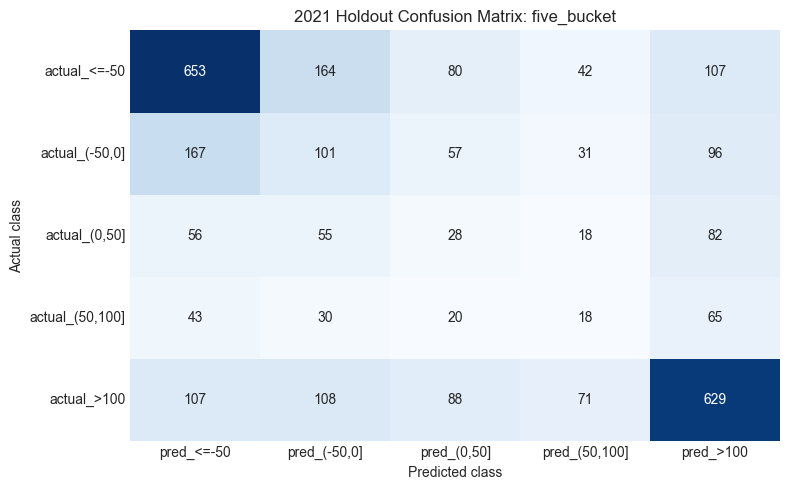

Classification report:


,precision,recall,f1-score,support
<=-50,0.6365,0.6243,0.6303,1046.0000
"(-50,0]",0.2205,0.2235,0.2220,452.0000
"(0,50]",0.1026,0.1172,0.1094,239.0000
"(50,100]",0.1000,0.1023,0.1011,176.0000
>100,0.6425,0.6271,0.6347,1003.0000
accuracy,0.4901,0.4901,0.4901,0.4901
macro avg,0.3404,0.3389,0.3395,2916.0000
weighted avg,0.4979,0.4901,0.4939,2916.0000



2021 holdout regime results: three_bucket
Actual class distribution (%):


,share_pct
"(-50,100]",29.73
<=-50,35.87
>100,34.40


Confusion matrix:


,pred_<=-50,"pred_(-50,100]",pred_>100
actual_<=-50,673,271,102
"actual_(-50,100]",279,314,274
actual_>100,112,229,662


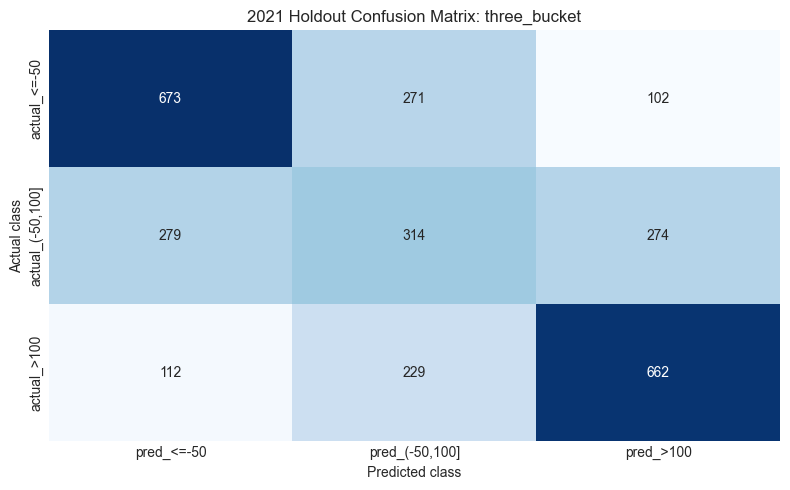

Classification report:


,precision,recall,f1-score,support
<=-50,0.6325,0.6434,0.6379,1046.0000
"(-50,100]",0.3857,0.3622,0.3736,867.0000
>100,0.6378,0.6600,0.6487,1003.0000
accuracy,0.5655,0.5655,0.5655,0.5655
macro avg,0.5520,0.5552,0.5534,2916.0000
weighted avg,0.5610,0.5655,0.5630,2916.0000



High-uncertainty business-rule review using five_bucket predictions:


,AcceptedCoveragePct,AcceptedRows,HighUncertaintyRows,AcceptedBucketAccuracy,AcceptedDirectionalAcc,AcceptedSpearmanRho,AcceptedTMAPE_95Coverage,AcceptedWAPE,AcceptedSMAPE,AcceptedMAE,AcceptedMAPE,RejectedActualExtremeRate,AcceptedActualExtremeRate,AcceptedMeanClassifierConfidence,RejectedMeanClassifierConfidence
0,31.2414,911,2005,16.1361,63.7761,0.4187,138.7744,93.0245,133.1005,195.0698,319.0993,74.6135,60.7025,0.3796,0.5718


Actual bucket mix inside the accepted and high-uncertainty groups:


,review_group,actual_bucket,n_obs,share_within_group_pct
0,accepted,"(-50,0]",189,20.75
1,accepted,"(0,50]",101,11.09
2,accepted,"(50,100]",68,7.46
3,accepted,<=-50,286,31.39
4,accepted,>100,267,29.31
5,high_uncertainty,"(-50,0]",263,13.12
6,high_uncertainty,"(0,50]",138,6.88
7,high_uncertainty,"(50,100]",108,5.39
8,high_uncertainty,<=-50,760,37.91
9,high_uncertainty,>100,736,36.71


,company_id,fiscal_year,actual,prediction,abs_error,actual_bucket,predicted_bucket,predicted_confidence,high_uncertainty_flag,actual_extreme_flag,accepted_flag
0,COMP_00000,2021,-22.525468,142.826872,165.352340,"(-50,0]","(0,50]",0.303014,False,False,True
1,COMP_00001,2021,-94.492795,-75.568059,18.924737,<=-50,<=-50,0.729390,True,True,False
2,COMP_00002,2021,299.964704,307.911935,7.947231,>100,"(-50,0]",0.369937,False,True,True
3,COMP_00003,2021,360.614235,-58.713163,419.327399,>100,"(-50,0]",0.469303,False,True,True
4,COMP_00004,2021,-83.555686,-85.360948,1.805262,<=-50,<=-50,0.499655,True,True,False
5,COMP_00005,2021,-72.932347,8.662275,81.594622,<=-50,"(0,50]",0.335379,False,True,True
6,COMP_00006,2021,703.020696,121.099309,581.921387,>100,>100,0.616901,True,True,False
7,COMP_00007,2021,1262.255722,-8.712384,1270.968105,>100,"(-50,0]",0.272535,False,True,True
8,COMP_00008,2021,140.495642,29.786149,110.709493,>100,>100,0.451674,True,True,False
9,COMP_00009,2021,369.121401,-21.160907,390.282308,>100,"(50,100]",0.338154,False,True,True


In [48]:
# Detailed 2021 holdout view for the two regime-classification schemes
for scheme in ['five_bucket', 'three_bucket']:
    result = regime_outputs[('2021_holdout', scheme)]
    print(f'\n2021 holdout regime results: {scheme}')
    print('Actual class distribution (%):')
    display(result['actual_distribution_pct'].rename('share_pct').round(2).to_frame())
    print('Confusion matrix:')
    display(result['confusion_matrix'])

    plt.figure(figsize=(8, 5))
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'2021 Holdout Confusion Matrix: {scheme}')
    plt.xlabel('Predicted class')
    plt.ylabel('Actual class')
    plt.tight_layout()
    plt.show()

    print('Classification report:')
    display(result['classification_report'].round(4))


holdout_five_bucket = regime_outputs[('2021_holdout', 'five_bucket')]['predictions_frame'].reset_index(drop=True)
holdout_regression_view = holdout_result['predictions_df'].reset_index(drop=True).copy()
uncertainty_review = pd.concat([
    holdout_regression_view[['company_id', 'fiscal_year', 'actual', 'prediction', 'abs_error']],
    holdout_five_bucket[['actual_bucket', 'predicted_bucket', 'predicted_confidence', 'predicted_extreme_flag', 'actual_extreme_flag']]
], axis=1)

uncertainty_review = uncertainty_review.rename(columns={'predicted_extreme_flag': 'high_uncertainty_flag'})
uncertainty_review['accepted_flag'] = ~uncertainty_review['high_uncertainty_flag']

accepted_mask = uncertainty_review['accepted_flag']
rejected_mask = uncertainty_review['high_uncertainty_flag']

accepted_metrics = compute_regression_metrics(
    uncertainty_review.loc[accepted_mask, 'actual'],
    uncertainty_review.loc[accepted_mask, 'prediction']
) if accepted_mask.any() else {}

high_uncertainty_summary = pd.DataFrame([{
    'AcceptedCoveragePct': accepted_mask.mean() * 100,
    'AcceptedRows': int(accepted_mask.sum()),
    'HighUncertaintyRows': int(rejected_mask.sum()),
    'AcceptedBucketAccuracy': uncertainty_review.loc[accepted_mask, 'actual_bucket'].eq(
        uncertainty_review.loc[accepted_mask, 'predicted_bucket']
    ).mean() * 100 if accepted_mask.any() else np.nan,
    'AcceptedDirectionalAcc': accepted_metrics.get('DirectionalAcc', np.nan),
    'AcceptedSpearmanRho': accepted_metrics.get('SpearmanRho', np.nan),
    'AcceptedTMAPE_95Coverage': accepted_metrics.get('TMAPE_95Coverage', np.nan),
    'AcceptedWAPE': accepted_metrics.get('WAPE', np.nan),
    'AcceptedSMAPE': accepted_metrics.get('SMAPE', np.nan),
    'AcceptedMAE': accepted_metrics.get('MAE', np.nan),
    'AcceptedMAPE': accepted_metrics.get('MAPE', np.nan),
    'RejectedActualExtremeRate': uncertainty_review.loc[rejected_mask, 'actual_extreme_flag'].mean() * 100 if rejected_mask.any() else np.nan,
    'AcceptedActualExtremeRate': uncertainty_review.loc[accepted_mask, 'actual_extreme_flag'].mean() * 100 if accepted_mask.any() else np.nan,
    'AcceptedMeanClassifierConfidence': uncertainty_review.loc[accepted_mask, 'predicted_confidence'].mean() if accepted_mask.any() else np.nan,
    'RejectedMeanClassifierConfidence': uncertainty_review.loc[rejected_mask, 'predicted_confidence'].mean() if rejected_mask.any() else np.nan,
}])

uncertainty_bucket_mix = (
    uncertainty_review
    .assign(review_group=np.where(uncertainty_review['accepted_flag'], 'accepted', 'high_uncertainty'))
    .groupby(['review_group', 'actual_bucket'], observed=False)
    .size()
    .reset_index(name='n_obs')
)
uncertainty_bucket_mix['share_within_group_pct'] = (
    uncertainty_bucket_mix['n_obs'] /
    uncertainty_bucket_mix.groupby('review_group')['n_obs'].transform('sum') * 100
)

print('\nHigh-uncertainty business-rule review using five_bucket predictions:')
display(high_uncertainty_summary.round(4))
print('Actual bucket mix inside the accepted and high-uncertainty groups:')
display(uncertainty_bucket_mix.round(2))
display(uncertainty_review.head(10))


## 9. Final Deliverable Export

The dataset contains 2023 feature rows, so `2022 -> 2023` can be audited directly. A true `2023 -> 2024` revenue-change label is not available, so the final CSV below is an observable final-audit export rather than an invented future submission.

This export is useful for showing how the selected workflow behaves on the latest observable year before the purely forward-looking 2024 forecast is generated.

In [49]:
# Final observable export: 2022 source rows predicting 2023 revenue change
from pathlib import Path

FINAL_AUDIT_TRAIN_YEARS = [2018, 2019, 2020, 2021]
FINAL_AUDIT_SOURCE_YEAR = 2022
FINAL_AUDIT_TARGET_YEAR = 2023

final_audit_bundle = prepare_experiment_bundle(
    model_df=model_df,
    train_years=FINAL_AUDIT_TRAIN_YEARS,
    val_year=FINAL_AUDIT_SOURCE_YEAR,
    candidate_features=final_features
)

final_clean_base_run = fit_named_model_and_score(
    final_audit_bundle,
    final_features,
    best_model_name,
    params=model_benchmark_runs[best_model_name]['params'],
    label=f'{best_model_name}_2022_to_2023_final_audit',
    target_clip_quantiles=TARGET_CLIP_QUANTILES
)

final_catboost_sensitivity_run = fit_named_model_and_score(
    final_audit_bundle,
    final_features,
    'CatBoost',
    params=model_benchmark_runs['CatBoost']['params'],
    label='CatBoost_2022_to_2023_transfer_sensitivity',
    target_clip_quantiles=TARGET_CLIP_QUANTILES
)

final_export = final_clean_base_run['predictions_df'][[
    'company_id', 'fiscal_year', 'ateco_sector', 'region', 'legal_form',
    'production_value', 'production_value_next', 'actual', 'prediction'
]].copy()
final_export = final_export.rename(columns={
    'fiscal_year': 'source_feature_year',
    'production_value': 'production_value_source_year',
    'production_value_next': 'production_value_target_year',
    'actual': 'actual_revenue_change_2023',
    'prediction': 'clean_base_prediction'
})
final_export['target_year'] = FINAL_AUDIT_TARGET_YEAR
final_export['catboost_sensitivity_prediction'] = final_catboost_sensitivity_run['predictions_df']['prediction'].values
final_export['clean_base_abs_error'] = (
    final_export['actual_revenue_change_2023'] - final_export['clean_base_prediction']
).abs()
final_export['catboost_abs_error'] = (
    final_export['actual_revenue_change_2023'] - final_export['catboost_sensitivity_prediction']
).abs()
final_export = final_export[[
    'company_id', 'source_feature_year', 'target_year', 'ateco_sector', 'region', 'legal_form',
    'production_value_source_year', 'production_value_target_year', 'actual_revenue_change_2023',
    'clean_base_prediction', 'catboost_sensitivity_prediction',
    'clean_base_abs_error', 'catboost_abs_error'
]].sort_values(['company_id', 'source_feature_year']).reset_index(drop=True)

final_export_path = Path('../outputs/revenue_change_final_audit_predictions.csv')
final_export_path.parent.mkdir(parents=True, exist_ok=True)
final_export.to_csv(final_export_path, index=False)

final_audit_metrics = compare_runs({
    '2022_to_2023_clean_base': final_clean_base_run,
    '2022_to_2023_catboost_sensitivity': final_catboost_sensitivity_run,
})

print(f'Final audit predictions written to: {final_export_path}')
display_compact(final_audit_metrics, RUN_REPORT_COLUMNS)
display(final_export.head(10))


Final audit predictions written to: ../outputs/revenue_change_final_audit_predictions.csv


,run_label,model_name,n_features,DirectionalAcc,SpearmanRho,TMAPE_95Coverage,WAPE,SMAPE,RMSE_Winsor_P02_P98,MAE,RMSE,MAPE,target_clip_quantiles
0,2022_to_2023_clean_base,Lasso,49,74.1623,0.6780,169.8874,87.3343,108.3488,495.6288,400.3705,2752.0185,277.6166,"(0.05, 0.95)"
1,2022_to_2023_catboost_sensitivity,CatBoost,49,73.6442,0.6712,172.0515,88.5588,109.1012,540.5651,405.9841,2759.6459,290.3772,"(0.05, 0.95)"


,company_id,source_feature_year,target_year,ateco_sector,region,legal_form,production_value_source_year,production_value_target_year,actual_revenue_change_2023,clean_base_prediction,catboost_sensitivity_prediction,clean_base_abs_error,catboost_abs_error
0,COMP_00000,2022,2023,47,Campania,SRL,3.898393e+08,7.742371e+09,1886.041444,198.404670,170.031762,1687.636774,1716.009682
1,COMP_00001,2022,2023,62,Sardegna,SRL,1.439279e+08,9.829759e+08,582.963874,346.265417,321.569691,236.698457,261.394184
2,COMP_00002,2022,2023,41,Puglia,SAS,3.092165e+08,5.332305e+08,72.445659,-6.490610,-2.224648,78.936269,74.670307
3,COMP_00003,2022,2023,47,Emilia-Romagna,SRL,1.290155e+10,1.128572e+09,-91.252432,-91.933015,-92.817415,0.680583,1.564983
4,COMP_00005,2022,2023,62,Lombardia,SNC,5.869471e+07,4.462389e+08,660.271120,311.203035,302.403537,349.068085,357.867584
5,COMP_00006,2022,2023,71,Lazio,SRL,1.845498e+09,3.232092e+09,75.133810,-70.780786,-72.318042,145.914596,147.451852
6,COMP_00007,2022,2023,10,Emilia-Romagna,SRL,7.694161e+09,1.423339e+09,-81.501051,-93.639461,-94.955998,12.138410,13.454947
7,COMP_00008,2022,2023,47,Emilia-Romagna,SRL,2.109981e+09,9.508071e+08,-54.937637,-44.194160,-53.064936,10.743477,1.872701
8,COMP_00009,2022,2023,10,Puglia,SRL,3.661859e+09,1.519825e+07,-99.584958,-84.543254,-82.995371,15.041705,16.589587
9,COMP_00011,2022,2023,41,Sicilia,SPA,2.856744e+09,8.516118e+09,198.105718,48.199162,60.703954,149.906556,137.401764


### 9.1 2024 Revenue-Change Prediction

The rows from fiscal year `2023` can be used to forecast `2024` revenue change, but the actual 2024 revenue is not available in the project data. This section therefore creates a true forward-looking prediction output.

It uses 2023 financial statements, trains on all labeled source years through 2022, and writes a separate CSV for the 2024 forecast.

In [50]:
# Forward-looking 2024 revenue-change prediction from 2023 financial statements
FUTURE_TRAIN_YEARS = [2018, 2019, 2020, 2021, 2022]
FUTURE_SOURCE_YEAR = 2023
FUTURE_TARGET_YEAR = 2024

def add_minimal_future_scoring_features(df):
    out = df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)
    grp = out.groupby('company_id', sort=False)

    out['production_value_lag1'] = grp['production_value'].shift(1)
    out['production_value_lag2'] = grp['production_value'].shift(2)
    out['revenue_change'] = safe_div(
        out['production_value'] - out['production_value_lag1'],
        out['production_value_lag1']
    ) * 100
    out['rev_growth_lag1'] = grp['revenue_change'].shift(1)
    out['rev_growth_lag2'] = grp['revenue_change'].shift(2)
    out['revenue_tier_t'] = assign_year_specific_revenue_tier(out)
    out['revenue_tier_lag1'] = grp['revenue_tier_t'].shift(1)
    out['tier_shift_t'] = out['revenue_tier_t'] - out['revenue_tier_lag1']

    lag_cols = [
        'total_assets', 'shareholders_equity', 'total_debt', 'current_assets',
        'total_fixed_assets', 'short_term_debt', 'long_term_debt',
        'operating_income', 'net_profit_loss', 'financial_income', 'financial_expenses'
    ]
    for col in lag_cols:
        out[f'{col}_lag1'] = grp[col].shift(1)
        out[f'{col}_lag2'] = grp[col].shift(2)

    out['operating_margin'] = safe_div(out['operating_income'], out['production_value'])
    out['profit_margin_calc'] = safe_div(out['net_profit_loss'], out['production_value'])
    out['capital_intensity'] = safe_div(out['total_fixed_assets'], out['production_value'])
    out['profit_margin_calc_lag1'] = grp['profit_margin_calc'].shift(1)
    out['profit_margin_calc_lag2'] = grp['profit_margin_calc'].shift(2)
    out['working_capital'] = out['current_assets'] - out['short_term_debt']
    out['working_capital_to_assets'] = safe_div(out['working_capital'], out['total_assets'])
    out['equity_ratio'] = safe_div(out['shareholders_equity'], out['total_assets'])
    out['equity_to_assets'] = out['equity_ratio']
    out['equity_to_total_debt'] = safe_div(out['shareholders_equity'], out['total_debt'])
    out['debt_maturity_ratio'] = safe_div(out['long_term_debt'], out['total_debt'])
    out['short_term_burden'] = safe_div(out['short_term_debt'], out['total_debt'])
    out['operating_income_to_assets'] = safe_div(out['operating_income'], out['total_assets'])
    out['interest_coverage_proxy'] = safe_div(out['operating_income'], out['financial_expenses'].abs())
    out['interest_coverage'] = out['interest_coverage_proxy']
    out['net_financial_cost'] = out['financial_expenses'] - out['financial_income']
    out['financial_drag'] = safe_div(out['net_financial_cost'], out['production_value'])
    out['retained_earnings_proxy'] = out[
        ['net_profit_loss', 'net_profit_loss_lag1', 'net_profit_loss_lag2']
    ].sum(axis=1, min_count=1)
    out['retained_earnings_to_assets'] = safe_div(out['retained_earnings_proxy'], out['total_assets'])
    out['altman_z_proxy'] = (
        1.2 * out['working_capital_to_assets'] +
        1.4 * out['retained_earnings_to_assets'] +
        3.3 * out['operating_income_to_assets'] +
        0.6 * out['equity_to_total_debt']
    )
    out['revenue_acceleration'] = (
        out['revenue_change'] - (2 * out['rev_growth_lag1']) + out['rev_growth_lag2']
    )
    out['margin_acceleration'] = (
        out['profit_margin_calc'] - (2 * out['profit_margin_calc_lag1']) + out['profit_margin_calc_lag2']
    )
    out['is_covid_year'] = out['fiscal_year'].eq(2020).astype(int)
    out['covid_x_sector'] = 0.0
    out['covid_x_leverage'] = out['is_covid_year'] * out['leverage'].fillna(0)
    out['net_debt'] = out['total_debt'] - out['current_assets']
    out['accounting_gap'] = out['total_assets'] - (out['shareholders_equity'] + out['total_debt'])
    out['accounting_gap_pct_assets'] = safe_div(out['accounting_gap'], out['total_assets'])

    out['equity_expected_from_profit'] = out['shareholders_equity_lag1'] + out['net_profit_loss']
    out['equity_gap'] = out['shareholders_equity'] - out['equity_expected_from_profit']
    out['equity_gap_pct_assets'] = safe_div(out['equity_gap'], out['total_assets'])
    out['equity_gap_direction'] = np.sign(out['equity_gap_pct_assets']).fillna(0)

    out['thin_margin_flag'] = out['profit_margin_calc'].abs().lt(THIN_MARGIN_THRESHOLD).astype(int)
    out['thin_margin_high_debt_flag'] = (
        out['thin_margin_flag'].eq(1) & out['debt_to_assets'].gt(HIGH_DEBT_THRESHOLD)
    ).astype(int)
    out['healthy_growth_flag'] = (
        out['revenue_change'].gt(0) &
        out['profit_margin_calc'].gt(0) &
        out['debt_to_assets'].lt(0.5)
    ).astype(int)

    out['fixed_asset_ratio'] = safe_div(out['total_fixed_assets'], out['total_assets'])
    out['fixed_asset_ratio_lag1'] = grp['fixed_asset_ratio'].shift(1)
    out['fixed_asset_ratio_change'] = out['fixed_asset_ratio'] - out['fixed_asset_ratio_lag1']
    out['capex_intensity_flag'] = out['fixed_asset_ratio_change'].gt(0.10).astype(int)

    return out

def fit_future_log_target_prediction(bundle, selected_features, model_name, params=None, target_clip_quantiles=TARGET_CLIP_QUANTILES):
    active_features = [feature for feature in selected_features if feature in bundle['X_train'].columns]
    y_train_raw = bundle['y_train_raw'].copy()
    y_train_fit = y_train_raw.copy()
    lower_bound = y_train_raw.min()
    upper_bound = y_train_raw.max()
    if target_clip_quantiles is not None:
        lower_q, upper_q = target_clip_quantiles
        lower_bound = y_train_raw.quantile(lower_q)
        upper_bound = y_train_raw.quantile(upper_q)
        y_train_fit = y_train_raw.clip(lower=lower_bound, upper=upper_bound)

    model = build_model(model_name, params=params)
    model.fit(bundle['X_train'][active_features], y_train_fit)
    log_predictions = model.predict(bundle['X_val'][active_features])
    log_predictions = np.clip(log_predictions, lower_bound, upper_bound)
    predicted_next_production_value = np.expm1(log_predictions)
    predicted_next_production_value = np.clip(predicted_next_production_value, a_min=0, a_max=None)
    predicted_revenue_change = derive_revenue_change_from_next_value(
        bundle['val_data']['production_value'],
        predicted_next_production_value
    )

    return {
        'model_name': model_name,
        'model': model,
        'active_features': active_features,
        'predicted_revenue_change': predicted_revenue_change,
        'predicted_production_value_next': predicted_next_production_value,
    }

future_feature_frame = add_minimal_future_scoring_features(full_df)
future_2023_rows = future_feature_frame.loc[
    future_feature_frame['fiscal_year'].eq(FUTURE_SOURCE_YEAR)
].copy()
future_scoring_df = pd.concat([model_df, future_2023_rows], axis=0, sort=False)

future_bundle = prepare_experiment_bundle(
    model_df=future_scoring_df,
    train_years=FUTURE_TRAIN_YEARS,
    val_year=FUTURE_SOURCE_YEAR,
    candidate_features=final_features
)

future_clean_base = fit_future_log_target_prediction(
    future_bundle,
    final_features,
    best_model_name,
    params=model_benchmark_runs[best_model_name]['params'],
)
future_catboost_sensitivity = fit_future_log_target_prediction(
    future_bundle,
    final_features,
    'CatBoost',
    params=model_benchmark_runs['CatBoost']['params'],
)

future_predictions = future_bundle['val_data'][[
    'company_id', 'fiscal_year', 'ateco_sector', 'region', 'legal_form', 'production_value'
]].copy()
future_predictions = future_predictions.rename(columns={
    'fiscal_year': 'source_feature_year',
    'production_value': 'production_value_2023'
})
future_predictions['target_year'] = FUTURE_TARGET_YEAR
future_predictions['predicted_revenue_change_2024_clean_base'] = future_clean_base['predicted_revenue_change'].values
future_predictions['predicted_production_value_2024_clean_base'] = future_clean_base['predicted_production_value_next']
future_predictions['predicted_revenue_change_2024_catboost_sensitivity'] = future_catboost_sensitivity['predicted_revenue_change'].values
future_predictions['predicted_production_value_2024_catboost_sensitivity'] = future_catboost_sensitivity['predicted_production_value_next']
future_predictions = future_predictions[[
    'company_id', 'source_feature_year', 'target_year', 'ateco_sector', 'region', 'legal_form',
    'production_value_2023',
    'predicted_revenue_change_2024_clean_base',
    'predicted_production_value_2024_clean_base',
    'predicted_revenue_change_2024_catboost_sensitivity',
    'predicted_production_value_2024_catboost_sensitivity'
]].sort_values('company_id').reset_index(drop=True)

future_prediction_path = Path('../outputs/revenue_change_2024_predictions.csv')
future_predictions.to_csv(future_prediction_path, index=False)

future_prediction_summary = future_predictions[[
    'predicted_revenue_change_2024_clean_base',
    'predicted_revenue_change_2024_catboost_sensitivity'
]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f'2024 revenue-change predictions written to: {future_prediction_path}')
print(f'Rows scored: {len(future_predictions)}')
display(future_prediction_summary.round(4))
display(future_predictions.head(10))


2024 revenue-change predictions written to: ../outputs/revenue_change_2024_predictions.csv
Rows scored: 2895


,count,mean,std,min,5%,25%,50%,75%,95%,max
predicted_revenue_change_2024_clean_base,2895.0,117.4988,416.0287,-98.9606,-87.1240,-55.4317,1.6017,134.4850,654.7884,8650.0711
predicted_revenue_change_2024_catboost_sensitivity,2895.0,110.4673,412.2869,-99.4259,-87.4074,-57.7660,-1.1391,128.8244,605.7509,7755.4106


,company_id,source_feature_year,target_year,ateco_sector,region,legal_form,production_value_2023,predicted_revenue_change_2024_clean_base,predicted_production_value_2024_clean_base,predicted_revenue_change_2024_catboost_sensitivity,predicted_production_value_2024_catboost_sensitivity
0,COMP_00000,2023,2024,47,Campania,SRL,7.742371e+09,-86.024123,1.082064e+09,-84.228936,1.221054e+09
1,COMP_00001,2023,2024,62,Sardegna,SRL,9.829759e+08,-38.142182,6.080474e+08,-39.981879,5.899637e+08
2,COMP_00002,2023,2024,41,Puglia,SAS,5.332305e+08,-38.749338,3.266072e+08,-50.284192,2.650999e+08
3,COMP_00003,2023,2024,47,Emilia-Romagna,SRL,1.128572e+09,11.776100,1.261474e+09,2.598571,1.157899e+09
4,COMP_00005,2023,2024,62,Lombardia,SNC,4.462389e+08,-44.156697,2.491946e+08,-48.882794,2.281049e+08
5,COMP_00006,2023,2024,71,Lazio,SRL,3.232092e+09,-82.162809,5.765143e+08,-83.691724,5.270984e+08
6,COMP_00007,2023,2024,10,Emilia-Romagna,SRL,1.423339e+09,-51.056144,6.966370e+08,-46.382220,7.631628e+08
7,COMP_00008,2023,2024,47,Emilia-Romagna,SRL,9.508071e+08,35.019407,1.283774e+09,46.342350,1.391434e+09
8,COMP_00009,2023,2024,10,Puglia,SRL,1.519825e+07,3797.030789,5.922804e+08,4384.022203,6.814928e+08
9,COMP_00011,2023,2024,41,Sicilia,SPA,8.516118e+09,-43.343729,4.824915e+09,-61.485355,3.279953e+09


## 10. Conclusions And Next Steps

The notebook now tells a tighter and more defensible story: fit on the log next-value target, report on business growth, protect the workflow from leakage, and evaluate with metrics that stay meaningful near zero.

The strongest current result is the CatBoost-based workflow selected on `2018-2019 -> 2020` and audited on `2018-2020 -> 2021`. The final notebook keeps the full-sample holdout score as the main result, then adds robustness views rather than pretending the target can be made easy with one more feature trick.

The regime-classification add-on is useful as a decision layer, not a replacement for regression. It helps show when the model is calling an extreme revenue move and lets the project report an accepted-set coverage view under a simple `high_uncertainty` business rule.

The strongest next steps would be richer event data, more frequent financial observations, or explicit transaction-level signals for acquisitions, restructurings, and one-off shocks. Those are the kinds of events the current annual statements only capture indirectly.

## 11. Final Checklist

- [x] All cells run end-to-end without errors
- [x] Markdown explains the project flow with numbered sections and a clearer narrative arc
- [x] Near-zero target handling is documented clearly
- [x] Thin-margin and capital-event proxy features are included and interpreted in business terms
- [x] Final model choice is justified with robust metrics, not raw MAPE alone
- [x] Regime classification is reported as a supplementary layer, not as a hidden evaluation shortcut
- [x] A high-uncertainty accepted-set view is shown separately from the main holdout score
- [x] The notebook is presentation-ready for review
